In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import scipy.stats
import pandas as pd
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
from tensorflow.keras.initializers import he_normal
import datetime
from os import listdir
import os
import random

In [ ]:
# colNum = 40  # Column number of genoMap
# rowNum = 40  # Row number of genoMap

In [ ]:
# high_data = pd.read_csv('/content/drive/MyDrive/Ahsan 11.7.2024/10. HIgh_Top_1600_Genes_Name.csv', header=None)
# high_dataNorm = scipy.stats.zscore(high_data, axis=0, ddof=1)
# high_genoMaps = gp.construct_genomap(high_dataNorm, rowNum, colNum, epsilon=0.0, num_iter=200)

In [ ]:
# low_data = pd.read_csv('/content/drive/MyDrive/Ahsan 11.7.2024/4. Low_Top_1600_Genes_Name - Copy.csv', header=None)
# low_dataNorm = scipy.stats.zscore(low_data, axis=0, ddof=1)
# low_genoMaps = gp.construct_genomap(low_dataNorm, rowNum, colNum, epsilon=0.0, num_iter=200)

In [ ]:
# np.save('/content/drive/MyDrive/Ahsan 11.7.2024/high_genomap.npy', high_genoMaps)

In [ ]:
# np.save('/content/drive/MyDrive/Ahsan 11.7.2024/low_genomap.npy', low_genoMaps)

In [ ]:
batch_size = 64
num_channels = 1
image_size = 40
latent_dim = 128
num_features = 1

b = low mono = high

In [ ]:
low_data = np.load('/content/drive/MyDrive/Ahsan/8. 2025 cGAN Hamid with Dr. Darren Dataset/b_Class_genomap.npy') #genomap matrices
high_data = np.load('/content/drive/MyDrive/Ahsan/8. 2025 cGAN Hamid with Dr. Darren Dataset/mono_Class_genomap.npy')

In [ ]:
Y = [-0.5] * low_data.shape[0] +  [0.5] * high_data.shape[0]
Y = np.asarray(Y, 'float32').reshape((-1,1))

In [ ]:
data = np.vstack([low_data, high_data ])
data = data.astype(np.float32)
#data = np.clip(data , -5 ,5)
_MIN = data.min()
_MAX = data.max()
data = -1 + 2*(data - _MIN)/(_MAX - _MIN) #scaling [-1,1]

In [ ]:
# Print the first 5 rows and first 5 columns of the array (adjust slicing as needed)
print("Snippet of normalized data:")
print(data[:5, :5])  # This will show the first 5 rows and 5 columns

Snippet of normalized data:
[[[[-0.86787933]
   [-0.8728794 ]
   [-0.8685326 ]
   [-0.87017035]
   [-0.8921615 ]
   [-0.87155   ]
   [-0.8685326 ]
   [-0.8719673 ]
   [-0.8768605 ]
   [-0.8771087 ]
   [-0.89065695]
   [-0.8981985 ]
   [-0.8738494 ]
   [-0.88065827]
   [-0.8807285 ]
   [-0.88120866]
   [-0.8815946 ]
   [-0.87604654]
   [-0.8773917 ]
   [-0.87048185]
   [-0.89044046]
   [-0.9034774 ]
   [-0.8777473 ]
   [-0.88009286]
   [-0.8756184 ]
   [-0.8814398 ]
   [-0.87155   ]
   [-0.88048285]
   [-0.88149405]
   [-0.883929  ]
   [-0.88738513]
   [-0.8769848 ]
   [-0.874096  ]
   [-0.88566303]
   [-0.87048185]
   [-0.8707722 ]
   [-0.87178564]
   [-0.8730347 ]
   [-0.87017035]
   [-0.86983204]]

  [[-0.86983204]
   [-0.8690345 ]
   [-0.86983204]
   [-0.59639746]
   [-0.87161386]
   [-0.8724839 ]
   [-0.87155   ]
   [-0.88026804]
   [-0.8932911 ]
   [-0.8720639 ]
   [-0.8767036 ]
   [-0.8848562 ]
   [-0.883831  ]
   [-0.87473476]
   [-0.8948012 ]
   [-0.87670815]
   [-0.87985617]
 

In [ ]:
print(data.mean(),data.std())

-0.8663045 0.054196242


In [ ]:
# def map_fn(file_path, label):
#     img = tf.io.read_file(file_path)
#     img = tf.image.decode_png(img, channels=1)
#     img = tf.image.convert_image_dtype(img, tf.float32)
#     img =  2.0 * img - 1.0
#     label = label - 0.5
#     return img , label

In [ ]:
dataset = tf.data.Dataset.from_tensor_slices((data , Y ))
dataset = dataset.shuffle(buffer_size=1000)
dataset = dataset.batch(batch_size)

(64, 40, 40, 1)
(64, 1)
-0.9563687 1.0 -0.8664 0.054389652
-0.5 -0.5 -0.5 0.0


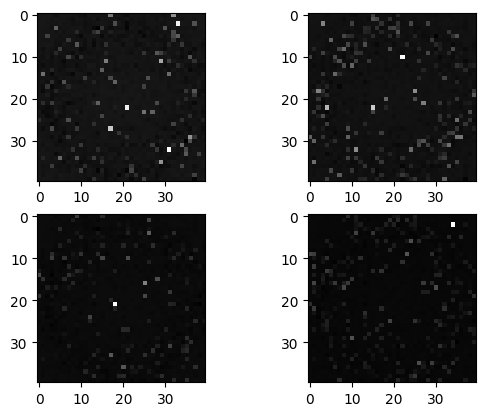

In [ ]:
for x, y in dataset.take(1):
  print(x.shape)
  print(y.shape)
  print(np.min(x),np.max(x),np.mean(x),np.std(x))
  print(np.min(y),np.max(y),np.mean(y),np.std(y))
  # x = np.clip(x, -1 ,1)
  x = x * 0.5 + 0.5
  #x = (x - np.min(x))/(np.max(x) - np.min(x))
  x *= 255.0
  #x = x.astype(np.uint8)
  for i in range(4):
    plt.subplot(2,2,i+1)
    plt.imshow(x[i] , cmap='gray')
  plt.show()

In [ ]:
generator_in_channels = latent_dim + num_features
discriminator_in_channels = num_channels + num_features
print(generator_in_channels, discriminator_in_channels)

129 2


In [ ]:
def get_discriminator():
  input_layer = layers.Input(shape=(image_size,image_size,num_channels+1))
  x = layers.Conv2D(32 , (3,3) , padding='same',strides=2,use_bias=True)(input_layer)
  x = layers.LeakyReLU(alpha=0.2)(x)
  x = layers.Conv2D(64 , (3,3) , padding='same',strides=2,use_bias=True)(x)
  x = layers.LeakyReLU(alpha=0.2)(x)
  x = layers.Conv2D(128 , (3,3) , padding='same',strides=2,use_bias=True)(x)
  x = layers.LeakyReLU(alpha=0.2)(x)
  # x = layers.Conv2D(256 , (3,3) , padding='same',strides=2,use_bias=True)(x)
  # x = layers.LeakyReLU(alpha=0.2)(x)
  x = layers.Flatten()(x)
  x = layers.Dropout(0.2)(x)
  x = layers.Dense(256 , activation='relu')(x)
  x = layers.Dropout(0.2)(x)
  x = layers.Dense(1)(x)
  model = tf.keras.models.Model(input_layer,x, name='discriminator')
  print(model.summary())
  return model

In [ ]:
def get_geneator():
  input_layer_z = layers.Input(shape=(latent_dim,))
  input_layer_c = layers.Input(shape=(num_features,))
  c_emmbeding = layers.Dense(128 , activation='tanh')(input_layer_c)
  x = layers.Concatenate(axis=1)([input_layer_z,c_emmbeding])
  x = layers.Dense(5 * 5 * (latent_dim+num_features))(x)
  # x = layers.BatchNormalization()(x)
  x = layers.LeakyReLU(alpha=0.2)(x)
  x = layers.Reshape((5, 5, latent_dim+num_features))(x)
  x = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding="same",use_bias=True)(x)
  # x = layers.BatchNormalization()(x)
  x = layers.LeakyReLU(alpha=0.2)(x)
  x = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding="same",use_bias=True)(x)
  # x = layers.BatchNormalization()(x)
  x = layers.LeakyReLU(alpha=0.2)(x)
  x = layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding="same",use_bias=True)(x)
  # x = layers.BatchNormalization()(x)
  x = layers.LeakyReLU(alpha=0.2)(x)
  x = layers.Conv2DTranspose(16, (2, 2), strides=(1, 1), padding="same",use_bias=True)(x)
  # x = layers.BatchNormalization()(x)
  x = layers.LeakyReLU(alpha=0.2)(x)
  x = layers.Conv2DTranspose(num_channels, (2, 2), strides=(1, 1), padding="same",use_bias=True)(x)
  #x = layers.BatchNormalization()(x)
  x = layers.Activation("tanh")(x)
  model = tf.keras.models.Model([input_layer_z,input_layer_c],x, name='generator')
  print(model.summary())
  return model


In [ ]:

class ConditionalGAN(tf.keras.Model):
    def __init__(self, discriminator, generator, latent_dim,batch_size):
        super(ConditionalGAN, self).__init__()
        self.discriminator = discriminator
        self.generator = generator
        self.latent_dim = latent_dim
        self.gen_loss_tracker = tf.keras.metrics.Mean(name="generator_loss")
        self.disc_loss_tracker = tf.keras.metrics.Mean(name="discriminator_loss")
        self.batch_size = batch_size
        self.d_steps = 3
        self.gp_weight = 10
        self.d_losses = []
        self.g_losses = []

    @property
    def metrics(self):
        return [self.gen_loss_tracker, self.disc_loss_tracker]
        # return [self.gen_loss_tracker, tf.keras.metrics.Accuracy()]

    def compile(self, d_optimizer, g_optimizer, d_loss_fn,g_loss_fn):
        super(ConditionalGAN, self).compile()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer
        self.d_loss_fn = d_loss_fn
        self.g_loss_fn = g_loss_fn

    def gradient_penalty(self, batch_size, real_images, fake_images):
        """ Calculates the gradient penalty.

        This loss is calculated on an interpolated image
        and added to the discriminator loss.
        """
        # Get the interpolated image
        alpha = tf.random.normal([batch_size, 1, 1, 1], 0.0, 1.0)
        diff = fake_images - real_images
        interpolated = real_images + alpha * diff

        with tf.GradientTape() as gp_tape:
            gp_tape.watch(interpolated)
            # 1. Get the discriminator output for this interpolated image.
            pred = self.discriminator(interpolated, training=True)

        # 2. Calculate the gradients w.r.t to this interpolated image.
        grads = gp_tape.gradient(pred, [interpolated])[0]
        # 3. Calculate the norm of the gradients.
        norm = tf.sqrt(tf.reduce_sum(tf.square(grads), axis=[1, 2, 3]))
        gp = tf.reduce_mean((norm - 1.0) ** 2)
        return gp

    def train_step(self, data):
        # Unpack the data.
        real_images, features = data

        for i in range(self.d_steps):
            image_of_features = tf.repeat(
                      features, repeats=[image_size * image_size] ,axis=1
                  )
            image_of_features = tf.reshape(
                image_of_features, (-1, image_size, image_size, 1)
            )
            batch_size = tf.shape(real_images)[0]
            random_latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))
            # random_vector_features = tf.concat(
            #     [random_latent_vectors, features], axis=1
            # )

            with tf.GradientTape() as tape:
                self.discriminator.trainable = True
                # Generate fake images from the latent vector
                fake_images = self.generator([random_latent_vectors, features],training=True)
                fake_image_and_features = tf.concat([fake_images, image_of_features], -1)
                real_image_and_features = tf.concat([real_images, image_of_features], -1)

                # Get the logits for the fake images
                fake_logits = self.discriminator(fake_image_and_features, training=True)

                # Get the logits for the real images
                real_logits = self.discriminator(real_image_and_features, training=True)

                # Calculate the discriminator loss using the fake and real image logits
                d_cost = self.d_loss_fn(real_img=real_logits, fake_img=fake_logits)
                # Calculate the gradient penalty
                gp = self.gradient_penalty(batch_size, real_image_and_features, fake_image_and_features)
                # Add the gradient penalty to the original discriminator loss
                d_loss = d_cost + gp * self.gp_weight

            # Get the gradients w.r.t the discriminator loss
            d_gradient = tape.gradient(d_loss, self.discriminator.trainable_variables)
            # Update the weights of the discriminator using the discriminator optimizer
            self.d_optimizer.apply_gradients(
                zip(d_gradient, self.discriminator.trainable_variables)
            )


        # Train the generator
        random_latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))
        # random_vector_features = tf.concat(
        #         [random_latent_vectors, features], axis=1
        #     )

        with tf.GradientTape(watch_accessed_variables=True) as g_tape:
            self.discriminator.trainable = False

            #g_tape.watch(self.generator.trainable_variables)

            # Generate fake images using the generator
            generated_images = self.generator([random_latent_vectors, features], training=True)
            # Get the discriminator logits for fake images
            fake_image_and_features = tf.concat([generated_images, image_of_features], -1)
            gen_img_logits = self.discriminator(fake_image_and_features, training=True)

            # Calculate the generator loss
            g_loss = self.g_loss_fn(gen_img_logits)

        # Get the gradients w.r.t the generator loss
        gen_gradient = g_tape.gradient(g_loss, self.generator.trainable_variables)
        # Update the weights of the generator using the generator optimizer
        self.g_optimizer.apply_gradients(
            zip(gen_gradient, self.generator.trainable_variables)
        )


        self.d_losses.append(d_loss)
        self.g_losses.append(g_loss)

        # Monitor loss.
        self.gen_loss_tracker.update_state(g_loss)
        self.disc_loss_tracker.update_state(d_loss)
        return {"d_loss": d_loss, "g_loss": g_loss}


In [ ]:
def discriminator_loss(real_img, fake_img):
    real_loss = tf.reduce_mean(real_img)
    fake_loss = tf.reduce_mean(fake_img)
    return fake_loss - real_loss


# Define the loss functions for the generator.
def generator_loss(fake_img):
    return -tf.reduce_mean(fake_img)

In [ ]:
classifier = tf.keras.models.load_model('/content/drive/MyDrive/Ahsan/8. 2025 cGAN Hamid with Dr. Darren Dataset/classifier.h5')

In [ ]:

class GANMonitor(tf.keras.callbacks.Callback):
    def __init__(self, latent_dim=128, feature=[]):
        super(GANMonitor, self)
        self.latent_dim = latent_dim
        self.feature = feature


    def on_epoch_end(self, epoch, logs=None):
        # Sample noise for the interpolation.
        _noise = tf.random.normal(shape=(len(self.feature), latent_dim))
        labels = np.array(self.feature).reshape((len(self.feature),num_features))

        # Combine the noise and the labels and run inference with the generator.
        # _noise_and_labels = tf.concat([_noise, labels], 1)
        fake_images = self.model.generator.predict([_noise, labels])
        print(f"mean {fake_images.mean()} std {fake_images.std()}")
        original_data = ((fake_images + 1) * (_MAX - _MIN) / 2) + _MIN
        y_ = classifier.predict(original_data)
        print('prediction', y_)
        #fake_images = np.clip(fake_images, -1 ,1)
        # print(np.mean(fake_images))
        # print(np.std(fake_images))
        #fake_images = fake_images * 0.5 + 0.5
        fake_images = (fake_images - np.min(fake_images))/(np.max(fake_images) - np.min(fake_images))

        fake_images *= 255.0
        converted_images = fake_images.astype(np.uint8)




        if epoch % 50 == 0 :
            for i in range(4):
              plt.subplot(2,2,i+1)
              plt.imshow(converted_images[i], cmap='gray')
              # plt.imsave(root+'result/epoch {}_{}.png'.format(epoch,i),converted_images[i])
              # plt.imsave(root+'result/epoch {}_{}.png'.format(epoch,i),converted_images[i,:,:,0], cmap='gray')
            plt.show()

        if epoch % 5 == 0:
            print("saved on epoch", epoch)
            self.model.generator.save('/content/drive/MyDrive/Ahsan/8. 2025 cGAN Hamid with Dr. Darren Dataset/Generator Model/generator_' + "Epoch-" + str(epoch) + ".h5")
            self.model.discriminator.save('/content/drive/MyDrive/Ahsan/8. 2025 cGAN Hamid with Dr. Darren Dataset/Discriminator Model/discriminator_'+ "Epoch-" + str(epoch) + ".h5")


            print("saved on epoch", epoch)

In [ ]:
callback = GANMonitor(latent_dim=latent_dim,feature = [-0.5  ,  -0.5, 0.5 , 0.5])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 40, 40, 2)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 20, 20, 32)          │             608 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_8 (LeakyReLU)            │ (None, 20, 20, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 10, 10, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_9 (LeakyReLU)            │ (None, 10, 10, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 5, 5, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_10 (LeakyReLU)           │ (None, 5, 5, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 3200)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 3200)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 256)                 │         819,456 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 912,673 (3.48 MB)

 Trainable params: 912,673 (3.48 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5             │ (None, 1)              │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_4             │ (None, 128)            │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_6 (Dense)           │ (None, 128)            │            256 │ input_layer_5[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_1             │ (None, 256)            │              0 │ input_layer_4[0][0],   │
│ (Concatenate)             │                        │                │ dense_6[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_7 (Dense)           │ (None, 3225)           │        828,825 │ concatenate_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_11            │ (None, 3225)           │              0 │ dense_7[0][0]          │
│ (LeakyReLU)               │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape_1 (Reshape)       │ (None, 5, 5, 129)      │              0 │ leaky_re_lu_11[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_transpose_5        │ (None, 10, 10, 128)    │         66,176 │ reshape_1[0][0]        │
│ (Conv2DTranspose)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_12            │ (None, 10, 10, 128)    │              0 │ conv2d_transpose_5[0]… │
│ (LeakyReLU)               │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_transpose_6        │ (None, 20, 20, 64)     │         32,832 │ leaky_re_lu_12[0][0]   │
│ (Conv2DTranspose)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_13            │ (None, 20, 20, 64)     │              0 │ conv2d_transpose_6[0]… │
│ (LeakyReLU)               │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_transpose_7        │ (None, 40, 40, 32)     │          8,224 │ leaky_re_lu_13[0][0]   │
│ (Conv2DTranspose)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_14            │ (None, 40, 40, 32)     │              0 │ conv2d_transpose_7[0]… │
│ (LeakyReLU)               │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_transpose_8        │ (None, 40, 40, 16)     │          2,064 │ leaky_re_lu_14[0][0]   │
│ (Conv2DTranspose)         │                        │                │                        │
├──────────────────────

 Total params: 938,442 (3.58 MB)

 Trainable params: 938,442 (3.58 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step
mean 0.004112442955374718 std 0.009817921556532383
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 845ms/step
prediction [[1.]
 [1.]
 [1.]
 [1.]]


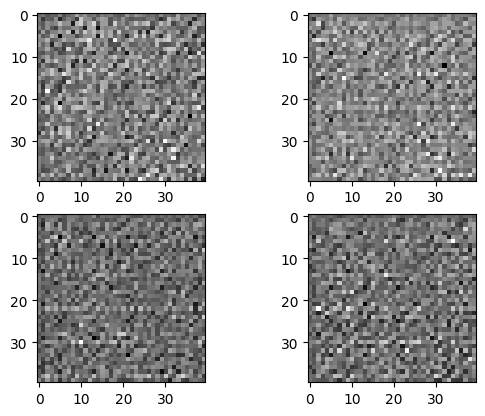

saved on epoch 0


saved on epoch 0
38/38 ━━━━━━━━━━━━━━━━━━━━ 54s 651ms/step - d_loss: 6.5831 - g_loss: 0.0976
Epoch 2/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean 0.0001338834554189816 std 0.010436209850013256
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
prediction [[1.]
 [1.]
 [1.]
 [1.]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - d_loss: 1.7507 - g_loss: 0.6663
Epoch 3/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
mean -0.0034574128221720457 std 0.011523901484906673
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
prediction [[1.]
 [1.]
 [1.]
 [1.]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - d_loss: -8.1276 - g_loss: 1.7989
Epoch 4/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
mean -0.007043999619781971 std 0.013372574932873249
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
prediction [[1.]
 [1.]
 [1.]
 [1.]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - d_loss: -23.1851 - g_loss: 3.7897
Epoch 5/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean -0.010764045640826225 std 0.015048274770379066
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
predictio

prediction [[1.]
 [1.]
 [1.]
 [1.]]
saved on epoch 5


saved on epoch 5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -46.9796 - g_loss: 10.4425
Epoch 7/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean -0.019273966550827026 std 0.022059865295886993
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
prediction [[1.]
 [1.]
 [1.]
 [1.]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - d_loss: -53.8049 - g_loss: 13.8141
Epoch 8/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
mean -0.02395646832883358 std 0.025167269632220268
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
prediction [[1.]
 [1.]
 [1.]
 [1.]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -58.4010 - g_loss: 17.1091
Epoch 9/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
mean -0.02877252735197544 std 0.027308907359838486
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[1.]
 [1.]
 [1.]
 [1.]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -60.8264 - g_loss: 19.2064
Epoch 10/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
mean -0.03524966537952423 std 0.03223858028650284
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
predic

prediction [[1.]
 [1.]
 [1.]
 [1.]]
saved on epoch 10


...

saved on epoch 35
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -11.5101 - g_loss: -19.8914
Epoch 37/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean -0.7206110954284668 std 0.12718112766742706
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
prediction [[0.9999628 ]
 [0.99996436]
 [0.99985456]
 [0.9998104 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -9.2481 - g_loss: -18.5506
Epoch 38/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean -0.7661996483802795 std 0.1280389428138733
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
prediction [[0.9994622 ]
 [0.9999089 ]
 [0.99999833]
 [0.99999416]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -7.5015 - g_loss: -15.6672
Epoch 39/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean -0.797945499420166 std 0.11864154040813446
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
prediction [[0.9992181 ]
 [0.99813783]
 [0.9999951 ]
 [0.99999964]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -5.9501 - g_loss: -10.2109
Epoch 40/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
me

prediction [[0.9891528 ]
 [0.8916204 ]
 [0.99999976]
 [1.        ]]
saved on epoch 40


saved on epoch 40
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - d_loss: -4.0509 - g_loss: 0.7229
Epoch 42/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
mean -0.8593828082084656 std 0.10906566679477692
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
prediction [[0.7801517 ]
 [0.99550074]
 [1.        ]
 [1.        ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -3.8513 - g_loss: 6.0626
Epoch 43/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8682751655578613 std 0.10306312888860703
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
prediction [[0.9368538]
 [0.9891528]
 [1.       ]
 [0.9999999]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -3.5475 - g_loss: 12.4224
Epoch 44/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean -0.876380443572998 std 0.10062987357378006
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
prediction [[0.4156243 ]
 [0.99997056]
 [1.        ]
 [1.        ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -3.4151 - g_loss: 16.5162
Epoch 45/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8887

prediction [[0.9998568]
 [0.9933669]
 [1.       ]
 [0.9999999]]
saved on epoch 45


saved on epoch 45
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -2.9167 - g_loss: 19.9857
Epoch 47/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
mean -0.8720756769180298 std 0.08205527067184448
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
prediction [[0.99994147]
 [0.98934364]
 [0.9999999 ]
 [0.99999976]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -2.8382 - g_loss: 19.7738
Epoch 48/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean -0.8770198225975037 std 0.07427216321229935
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
prediction [[0.9999443 ]
 [0.99989426]
 [0.9999994 ]
 [0.9999999 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -2.6249 - g_loss: 19.4127
Epoch 49/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
mean -0.8776876926422119 std 0.07392463088035583
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
prediction [[0.999874  ]
 [0.99807835]
 [0.9999999 ]
 [1.        ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -2.3951 - g_loss: 17.6589
Epoch 50/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean 

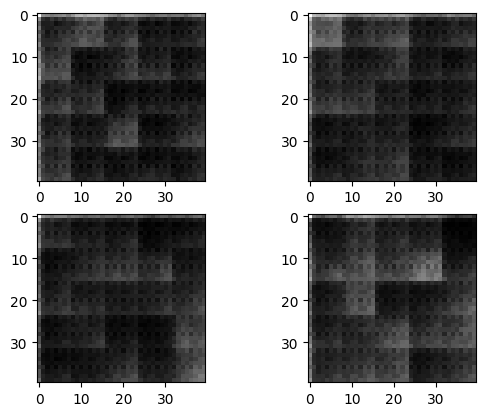

saved on epoch 50
saved on epoch 50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - d_loss: -2.2065 - g_loss: 15.1856
Epoch 52/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
mean -0.8628542423248291 std 0.06882721930742264
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.8675018 ]
 [0.99973303]
 [0.99999785]
 [0.99999964]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - d_loss: -1.9558 - g_loss: 14.7414
Epoch 53/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8614433407783508 std 0.06283517926931381
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
prediction [[0.99492717]
 [0.99999535]
 [0.99987316]
 [0.9999701 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -1.7734 - g_loss: 14.2370
Epoch 54/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8815605044364929 std 0.05816654860973358
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
prediction [[0.9999758 ]
 [0.99999833]
 [0.99999547]
 [0.99999225]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -1.7317 - g_loss: 12.9584
Epoch 55/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 

prediction [[0.99849284]
 [0.97241074]
 [0.99989426]
 [0.9948041 ]]
saved on epoch 55


saved on epoch 55
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -1.4552 - g_loss: 12.7266
Epoch 57/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8712632656097412 std 0.057687096297740936
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
prediction [[0.99999535]
 [0.99517447]
 [0.9998827 ]
 [0.9999819 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -1.5596 - g_loss: 11.7382
Epoch 58/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
mean -0.8591363430023193 std 0.05347750708460808
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
prediction [[0.9995912]
 [0.9998672]
 [0.975942 ]
 [0.9956916]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -1.5260 - g_loss: 10.9255
Epoch 59/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8667126297950745 std 0.05366402119398117
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
prediction [[0.99996185]
 [0.99737585]
 [0.9998281 ]
 [0.99959403]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -1.2407 - g_loss: 9.9386 
Epoch 60/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
mean -0.

prediction [[0.9780261 ]
 [0.99789304]
 [0.9981363 ]
 [0.9284123 ]]
saved on epoch 60
saved on epoch 60
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - d_loss: -1.0466 - g_loss: 9.6539
Epoch 62/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean -0.8813970685005188 std 0.03917543590068817
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
prediction [[0.999736  ]
 [0.9973909 ]
 [0.99977046]
 [0.9998765 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - d_loss: -1.0422 - g_loss: 9.4642
Epoch 63/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8672986030578613 std 0.04861440137028694
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
prediction [[0.9998878 ]
 [0.99998224]
 [0.7978025 ]
 [0.83626676]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.8380 - g_loss: 8.9791
Epoch 64/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8521968126296997 std 0.04995722323656082
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
prediction [[0.9992908 ]
 [0.9986197 ]
 [0.98936874]
 [0.71053135]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: 

prediction [[0.99999034]
 [0.99752086]
 [0.99614716]
 [0.37726802]]
saved on epoch 65


...

prediction [[0.99973065]
 [0.99922514]
 [0.99780303]
 [0.55891776]]
saved on epoch 85


saved on epoch 85
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.3073 - g_loss: 6.2320
Epoch 87/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8611953854560852 std 0.03494461625814438
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
prediction [[0.99356997]
 [0.9982792 ]
 [0.96598613]
 [0.9994894 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.2503 - g_loss: 5.0576
Epoch 88/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8693221807479858 std 0.035419464111328125
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
prediction [[0.99908745]
 [0.99980706]
 [0.9998394 ]
 [0.964184  ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.2344 - g_loss: 5.7865
Epoch 89/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
mean -0.8647395372390747 std 0.030202707275748253
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.99203146]
 [0.9709454 ]
 [0.9979176 ]
 [0.99468464]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.3859 - g_loss: 5.9635
Epoch 90/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
mean -0

prediction [[0.52556646]
 [0.9993467 ]
 [0.98852086]
 [0.9991008 ]]
saved on epoch 90
saved on epoch 90
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - d_loss: -0.2975 - g_loss: 6.2248
Epoch 92/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
mean -0.8710379004478455 std 0.027644379064440727
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
prediction [[0.98193765]
 [0.9972625 ]
 [0.9888976 ]
 [0.99895835]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - d_loss: -0.4130 - g_loss: 6.4064
Epoch 93/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
mean -0.8741678595542908 std 0.029184972867369652
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
prediction [[0.99186   ]
 [0.9997359 ]
 [0.99875987]
 [0.9959608 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - d_loss: -0.2582 - g_loss: 5.9524
Epoch 94/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
mean -0.8684251308441162 std 0.031122269108891487
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.99910563]
 [0.99953425]
 [0.9982261 ]
 [0.98736924]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - d_lo

prediction [[0.9936186 ]
 [0.99996626]
 [0.9957724 ]
 [0.99716836]]
saved on epoch 95


saved on epoch 95
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.2916 - g_loss: 5.2784
Epoch 97/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean -0.8823027014732361 std 0.027085324749350548
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
prediction [[0.9992267 ]
 [0.99955004]
 [0.9996463 ]
 [0.99990416]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.2066 - g_loss: 5.1310
Epoch 98/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
mean -0.8583859205245972 std 0.03238338232040405
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
prediction [[0.76294154]
 [0.9988255 ]
 [0.99550915]
 [0.9677238 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.3329 - g_loss: 4.9369
Epoch 99/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
mean -0.8704478740692139 std 0.029306013137102127
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
prediction [[0.99500495]
 [0.99893314]
 [0.9995409 ]
 [0.99612576]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.3839 - g_loss: 5.5222
Epoch 100/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
mean -

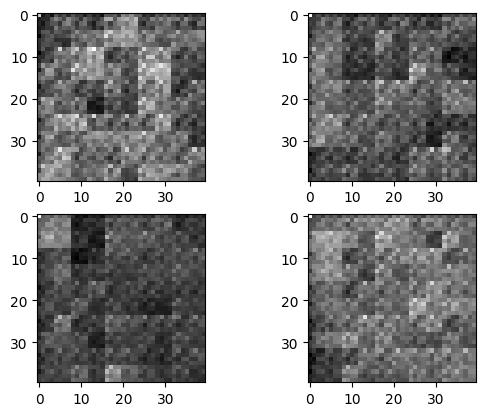

saved on epoch 100
saved on epoch 100
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - d_loss: -0.4411 - g_loss: 6.2791
Epoch 102/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
mean -0.8754532337188721 std 0.02936675027012825
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
prediction [[0.9995208 ]
 [0.99903584]
 [0.9998684 ]
 [0.9829421 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.5197 - g_loss: 5.2204
Epoch 103/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
mean -0.8598629236221313 std 0.03397127613425255
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
prediction [[0.9902677]
 [0.996497 ]
 [0.8821656]
 [0.8768827]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.4188 - g_loss: 5.8725
Epoch 104/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8730648756027222 std 0.030307088047266006
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
prediction [[0.99852437]
 [0.99986446]
 [0.8938062 ]
 [0.9887687 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.5405 - g_loss: 6.4836
Epoch 105/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0

prediction [[0.9989924]
 [0.9568086]
 [0.9996567]
 [0.9856472]]
saved on epoch 105


saved on epoch 105
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.3490 - g_loss: 6.7844
Epoch 107/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
mean -0.8692512512207031 std 0.029661079868674278
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
prediction [[0.99852365]
 [0.9905661 ]
 [0.9995208 ]
 [0.9976597 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2871 - g_loss: 6.1921
Epoch 108/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
mean -0.8690041899681091 std 0.033181462436914444
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.9343134 ]
 [0.99909055]
 [0.99984705]
 [0.9986675 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.2874 - g_loss: 6.5601
Epoch 109/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
mean -0.8678106665611267 std 0.029017888009548187
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.9830524 ]
 [0.99328643]
 [0.9990213 ]
 [0.99226016]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.4728 - g_loss: 7.3183
Epoch 110/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
m

prediction [[0.9362852 ]
 [0.99990356]
 [0.9996123 ]
 [0.99985325]]
saved on epoch 110


saved on epoch 110
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - d_loss: -0.5049 - g_loss: 8.6438
Epoch 112/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean -0.8715596199035645 std 0.02800912782549858
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
prediction [[0.9953448 ]
 [0.9993735 ]
 [0.99900585]
 [0.9271465 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.5748 - g_loss: 8.8315
Epoch 113/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8731037974357605 std 0.0260009728372097
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
prediction [[0.9984263]
 [0.999318 ]
 [0.996552 ]
 [0.9927005]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.3078 - g_loss: 7.5053
Epoch 114/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8529120683670044 std 0.02869437262415886
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
prediction [[0.9789098]
 [0.9604497]
 [0.9913038]
 [0.9073665]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2963 - g_loss: 6.3916
Epoch 115/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
mean -0.87364

...

prediction [[0.99946386]
 [0.9749824 ]
 [0.80667514]
 [0.99984825]]
saved on epoch 135


saved on epoch 135
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.5555 - g_loss: 4.9975
Epoch 137/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8658474683761597 std 0.02950071170926094
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
prediction [[0.9908343 ]
 [0.99920374]
 [0.99864954]
 [0.98533696]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.5281 - g_loss: 4.6707
Epoch 138/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
mean -0.861207902431488 std 0.03447940573096275
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
prediction [[0.80922323]
 [0.99979275]
 [0.9865298 ]
 [0.99977154]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.3384 - g_loss: 4.7380
Epoch 139/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
mean -0.8523851037025452 std 0.03272271901369095
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
prediction [[0.9985085 ]
 [0.9759113 ]
 [0.88609743]
 [0.997232  ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.6356 - g_loss: 5.4655
Epoch 140/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
mean 

prediction [[0.9965501]
 [0.9996693]
 [0.8828401]
 [0.9940262]]
saved on epoch 140
saved on epoch 140
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - d_loss: -0.4854 - g_loss: 5.5949
Epoch 142/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean -0.8779593706130981 std 0.02792942337691784
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
prediction [[0.9934487]
 [0.9998222]
 [0.9997129]
 [0.998806 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - d_loss: -0.4981 - g_loss: 5.9663
Epoch 143/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.866823673248291 std 0.02673843502998352
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
prediction [[0.99774724]
 [0.99866307]
 [0.9947454 ]
 [0.9961687 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.3229 - g_loss: 6.3027
Epoch 144/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8662002682685852 std 0.027352459728717804
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
prediction [[0.9763108 ]
 [0.99906427]
 [0.9858451 ]
 [0.9984295 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.

prediction [[0.8178338 ]
 [0.9966276 ]
 [0.9999325 ]
 [0.99923575]]
saved on epoch 145


saved on epoch 145
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.5156 - g_loss: 2.9865
Epoch 147/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean -0.8637544512748718 std 0.03041161596775055
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
prediction [[0.9975442 ]
 [0.97247916]
 [0.99920243]
 [0.9981262 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.5719 - g_loss: 3.1407
Epoch 148/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean -0.8745678663253784 std 0.02878890000283718
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
prediction [[0.99891365]
 [0.99204355]
 [0.99987054]
 [0.9990575 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.4804 - g_loss: 2.8872
Epoch 149/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8657959699630737 std 0.027267351746559143
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
prediction [[0.8621528 ]
 [0.9606991 ]
 [0.99441904]
 [0.9993783 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.4571 - g_loss: 2.6872
Epoch 150/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
mea

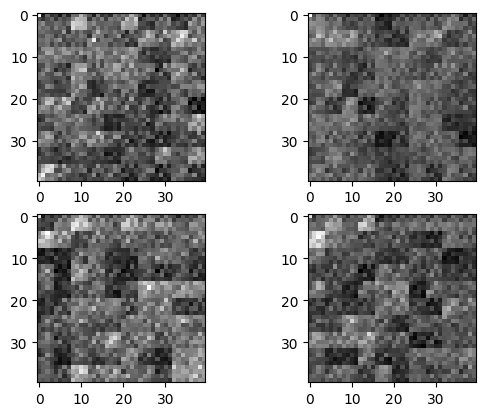

saved on epoch 150
saved on epoch 150
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - d_loss: -0.4240 - g_loss: 4.1686
Epoch 152/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean -0.8611865043640137 std 0.029581794515252113
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
prediction [[0.9732546 ]
 [0.9928189 ]
 [0.99967456]
 [0.8516019 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.4041 - g_loss: 5.1297
Epoch 153/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8660157918930054 std 0.028883323073387146
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
prediction [[0.9932066 ]
 [0.9905605 ]
 [0.99950385]
 [0.994718  ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.3537 - g_loss: 5.0228
Epoch 154/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8713462352752686 std 0.030677039176225662
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
prediction [[0.9996289 ]
 [0.99981457]
 [0.9998944 ]
 [0.964275  ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.3936 - g_loss: 5.3502
Epoch 155/2000
1/1 ━━━━━━━━━━━━━━━━

prediction [[0.99877006]
 [0.99926573]
 [0.9944272 ]
 [0.99887043]]
saved on epoch 155


saved on epoch 155
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.4859 - g_loss: 5.8622
Epoch 157/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.8671858906745911 std 0.02781311236321926
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
prediction [[0.9857692 ]
 [0.998314  ]
 [0.9829106 ]
 [0.99934584]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.5555 - g_loss: 5.5616
Epoch 158/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.8722634315490723 std 0.028681807219982147
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
prediction [[0.99583447]
 [0.98345333]
 [0.9998079 ]
 [0.9998909 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.5754 - g_loss: 3.7443
Epoch 159/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8750165700912476 std 0.02912484109401703
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
prediction [[0.9995598 ]
 [0.99987566]
 [0.9830703 ]
 [0.9995895 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.4290 - g_loss: 2.9173
Epoch 160/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mea

prediction [[0.9899581 ]
 [0.9998148 ]
 [0.99844307]
 [0.99920076]]
saved on epoch 160


saved on epoch 160
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - d_loss: -0.3908 - g_loss: 2.0151
Epoch 162/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
mean -0.881288468837738 std 0.028354965150356293
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
prediction [[0.99985707]
 [0.9997149 ]
 [0.99987197]
 [0.9899188 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.2969 - g_loss: 2.0147
Epoch 163/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
mean -0.8638580441474915 std 0.027384039014577866
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
prediction [[0.8828725 ]
 [0.9349482 ]
 [0.998728  ]
 [0.98700434]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.5477 - g_loss: 1.8812
Epoch 164/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.866218090057373 std 0.02678905613720417
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
prediction [[0.9484829]
 [0.9113637]
 [0.9990381]
 [0.9936187]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.4213 - g_loss: 2.2277
Epoch 165/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean -0.

...

prediction [[0.9797269 ]
 [0.9979159 ]
 [0.9754115 ]
 [0.94871414]]
saved on epoch 185


saved on epoch 185
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.5964 - g_loss: 2.7099
Epoch 187/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean -0.8646040558815002 std 0.028852928429841995
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
prediction [[0.9934801 ]
 [0.9992557 ]
 [0.9868401 ]
 [0.98319465]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.5097 - g_loss: 2.3403
Epoch 188/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8766668438911438 std 0.025017669424414635
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
prediction [[0.9979874 ]
 [0.996806  ]
 [0.99729294]
 [0.99973565]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.5025 - g_loss: 1.9506
Epoch 189/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8591134548187256 std 0.029948163777589798
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
prediction [[0.9957891 ]
 [0.9696899 ]
 [0.6616747 ]
 [0.99793977]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.4887 - g_loss: 2.1176
Epoch 190/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
m

prediction [[0.8188952 ]
 [0.9995946 ]
 [0.99470586]
 [0.99718934]]
saved on epoch 190


saved on epoch 190
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - d_loss: -0.5445 - g_loss: 3.1087
Epoch 192/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean -0.860710620880127 std 0.030544787645339966
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
prediction [[0.9511543 ]
 [0.98885113]
 [0.9996611 ]
 [0.9934822 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - d_loss: -0.4524 - g_loss: 3.9422
Epoch 193/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8638706803321838 std 0.03250161558389664
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
prediction [[0.9998406 ]
 [0.97811115]
 [0.979538  ]
 [0.9983247 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.4816 - g_loss: 4.6722
Epoch 194/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
mean -0.8572413921356201 std 0.03264157101511955
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
prediction [[0.9996809]
 [0.7364337]
 [0.9864762]
 [0.9837024]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.5292 - g_loss: 4.4829
Epoch 195/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
mean -0.

prediction [[0.9997311]
 [0.9712286]
 [0.9961516]
 [0.9983442]]
saved on epoch 195
saved on epoch 195
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - d_loss: -0.3885 - g_loss: 3.6725
Epoch 197/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean -0.8664382696151733 std 0.03414047881960869
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
prediction [[0.9997106 ]
 [0.96693623]
 [0.99993753]
 [0.9502959 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.4449 - g_loss: 2.7892
Epoch 198/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean -0.8545234799385071 std 0.030971981585025787
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
prediction [[0.9860218 ]
 [0.79659843]
 [0.989981  ]
 [0.9980282 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.4217 - g_loss: 2.1492
Epoch 199/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
mean -0.8542138934135437 std 0.02916570194065571
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
prediction [[0.9930669 ]
 [0.9651693 ]
 [0.92021316]
 [0.9771606 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss

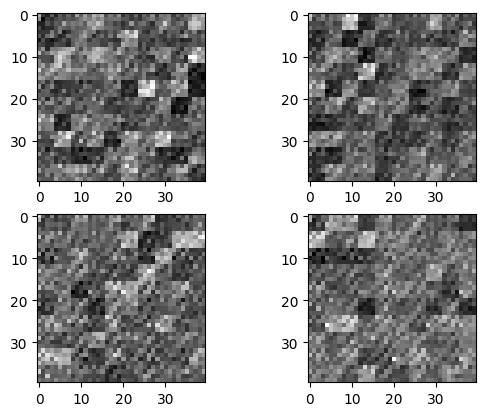

saved on epoch 200
saved on epoch 200
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - d_loss: -0.4217 - g_loss: 3.2160
Epoch 202/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
mean -0.8637169003486633 std 0.02972322516143322
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
prediction [[0.9882515]
 [0.9947443]
 [0.9981046]
 [0.9981179]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.4787 - g_loss: 3.5617
Epoch 203/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8675686120986938 std 0.03059612773358822
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
prediction [[0.9977671 ]
 [0.9996319 ]
 [0.94874865]
 [0.99921334]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.6118 - g_loss: 2.6708
Epoch 204/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean -0.8729214668273926 std 0.030120227485895157
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
prediction [[0.9995278]
 [0.9945768]
 [0.9987973]
 [0.9998728]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.5068 - g_loss: 2.8196
Epoch 205/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17

prediction [[0.99778455]
 [0.9944524 ]
 [0.9912986 ]
 [0.9904073 ]]
saved on epoch 205


saved on epoch 205
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.4968 - g_loss: 3.9475
Epoch 207/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8694643974304199 std 0.027127869427204132
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
prediction [[0.98864496]
 [0.9992161 ]
 [0.9987606 ]
 [0.9928986 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.4600 - g_loss: 3.4137
Epoch 208/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
mean -0.8650730848312378 std 0.02859312854707241
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
prediction [[0.9831881 ]
 [0.9996933 ]
 [0.99749196]
 [0.93810654]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.5362 - g_loss: 2.4385
Epoch 209/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
mean -0.8566000461578369 std 0.031372588127851486
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.8853292 ]
 [0.99886286]
 [0.9947803 ]
 [0.9484487 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.4256 - g_loss: 1.8188
Epoch 210/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
me

prediction [[0.9974126]
 [0.9994099]
 [0.9919703]
 [0.9996039]]
saved on epoch 210


saved on epoch 210
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - d_loss: -0.3983 - g_loss: 1.3950
Epoch 212/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8673506379127502 std 0.030681539326906204
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
prediction [[0.9949267 ]
 [0.9995084 ]
 [0.98898566]
 [0.9991554 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.5051 - g_loss: 2.0698
Epoch 213/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8596428632736206 std 0.030240196734666824
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.9916654 ]
 [0.98501414]
 [0.9059831 ]
 [0.9989446 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.5843 - g_loss: 2.7260
Epoch 214/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
mean -0.8615453839302063 std 0.030934184789657593
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
prediction [[0.9991516]
 [0.897954 ]
 [0.9982823]
 [0.998273 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.4126 - g_loss: 2.1165
Epoch 215/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean 

...

saved on epoch 235
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.5152 - g_loss: 1.8826
Epoch 237/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.876627504825592 std 0.03423347696661949
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
prediction [[0.9999926 ]
 [0.99939764]
 [0.999951  ]
 [0.9982017 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.4544 - g_loss: 1.7020
Epoch 238/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.86236971616745 std 0.034373410046100616
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
prediction [[0.99936694]
 [0.9976152 ]
 [0.99942636]
 [0.9932655 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.4047 - g_loss: 2.7387
Epoch 239/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8555586338043213 std 0.035539619624614716
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
prediction [[0.99282247]
 [0.9922901 ]
 [0.9998958 ]
 [0.99173427]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.3839 - g_loss: 3.1972
Epoch 240/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean 

prediction [[0.99951446]
 [0.9301278 ]
 [0.99973184]
 [0.9963785 ]]
saved on epoch 240


saved on epoch 240
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.4557 - g_loss: 2.9727
Epoch 242/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
mean -0.8712513446807861 std 0.03537552431225777
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
prediction [[0.99971443]
 [0.99920577]
 [0.9999454 ]
 [0.9999492 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.3482 - g_loss: 2.6113
Epoch 243/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8720071315765381 std 0.03402227908372879
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
prediction [[0.9996124 ]
 [0.9999634 ]
 [0.99972075]
 [0.996783  ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.4439 - g_loss: 2.4283
Epoch 244/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8639340996742249 std 0.03464779630303383
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
prediction [[0.9996346 ]
 [0.9996389 ]
 [0.94793785]
 [0.9994174 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.3795 - g_loss: 2.1546
Epoch 245/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean

prediction [[0.9995523 ]
 [0.9997112 ]
 [0.99982363]
 [0.99680007]]
saved on epoch 245


saved on epoch 245
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.4738 - g_loss: 3.0853
Epoch 247/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean -0.8712635636329651 std 0.034270551055669785
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
prediction [[0.999871 ]
 [0.9987967]
 [0.9986792]
 [0.999995 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.4642 - g_loss: 3.8267
Epoch 248/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean -0.8647897243499756 std 0.03733791038393974
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
prediction [[0.999977  ]
 [0.9977779 ]
 [0.99988866]
 [0.9891111 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.3909 - g_loss: 2.9896
Epoch 249/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8596058487892151 std 0.03288109973073006
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
prediction [[0.98535514]
 [0.9991346 ]
 [0.9996289 ]
 [0.9963103 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.4644 - g_loss: 3.2378
Epoch 250/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0

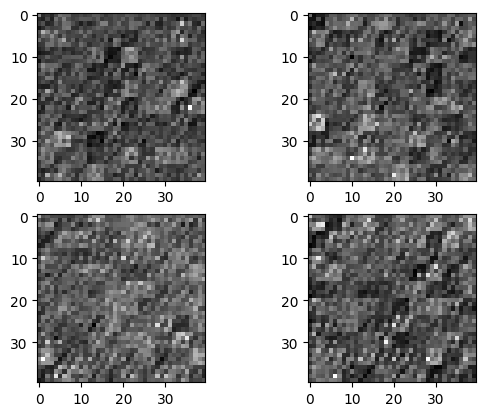

saved on epoch 250
saved on epoch 250
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - d_loss: -0.3730 - g_loss: 2.1761
Epoch 252/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
mean -0.8648434281349182 std 0.03377801924943924
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.994753  ]
 [0.99971193]
 [0.998719  ]
 [0.9983382 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.5082 - g_loss: 1.8761
Epoch 253/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
mean -0.8695172667503357 std 0.033538226038217545
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
prediction [[0.9998733]
 [0.9989103]
 [0.9999291]
 [0.9997135]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.4601 - g_loss: 1.7438
Epoch 254/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8658576011657715 std 0.03427729383111
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
prediction [[0.9908599 ]
 [0.99993443]
 [0.9987418 ]
 [0.99978167]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.4557 - g_loss: 2.7490
Epoch 255/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2

prediction [[0.99533737]
 [0.9990276 ]
 [0.9910058 ]
 [0.99982244]]
saved on epoch 255


saved on epoch 255
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.4428 - g_loss: 3.0578
Epoch 257/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
mean -0.8780220150947571 std 0.03245599567890167
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
prediction [[0.9999894 ]
 [0.9992281 ]
 [0.99989974]
 [0.99993825]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.4379 - g_loss: 2.8413
Epoch 258/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.8586239814758301 std 0.03701483830809593
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
prediction [[0.99687374]
 [0.99837494]
 [0.99951315]
 [0.9994271 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.4311 - g_loss: 2.1738
Epoch 259/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
mean -0.8645023107528687 std 0.034082405269145966
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
prediction [[0.9879134 ]
 [0.99985087]
 [0.9997049 ]
 [0.99945253]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.5418 - g_loss: 2.4895
Epoch 260/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mea

prediction [[0.99396837]
 [0.9983728 ]
 [0.9929892 ]
 [0.9997074 ]]
saved on epoch 260


saved on epoch 260
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.4478 - g_loss: 2.6614
Epoch 262/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
mean -0.8696426153182983 std 0.03468102216720581
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
prediction [[0.9999367 ]
 [0.9987833 ]
 [0.99959725]
 [0.9996965 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.4204 - g_loss: 2.3193
Epoch 263/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
mean -0.8685581684112549 std 0.03411388024687767
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.9997782 ]
 [0.9996884 ]
 [0.99971   ]
 [0.99968326]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.5063 - g_loss: 2.6498
Epoch 264/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8678085207939148 std 0.0348333977162838
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
prediction [[0.99987173]
 [0.99917126]
 [0.99985826]
 [0.99953485]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.2948 - g_loss: 3.1304
Epoch 265/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean 

...

prediction [[0.9999229 ]
 [0.99996376]
 [0.9997209 ]
 [0.99884254]]
saved on epoch 285


saved on epoch 285
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - d_loss: -0.2963 - g_loss: 1.8336
Epoch 287/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
mean -0.8700261116027832 std 0.03983580321073532
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
prediction [[0.999892  ]
 [0.99943954]
 [0.999933  ]
 [0.99999034]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.3427 - g_loss: 1.8746
Epoch 288/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.8690887689590454 std 0.03971095010638237
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
prediction [[0.9999099 ]
 [0.99984825]
 [0.9998921 ]
 [0.9999521 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.4055 - g_loss: 2.1750
Epoch 289/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
mean -0.8709157705307007 std 0.04150554910302162
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
prediction [[0.99993   ]
 [0.99984384]
 [0.99998033]
 [0.99996555]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.3117 - g_loss: 1.7108
Epoch 290/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
mean

prediction [[0.99988806]
 [0.9999174 ]
 [0.9955603 ]
 [0.99991477]]
saved on epoch 290


saved on epoch 290
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.3923 - g_loss: 1.8956
Epoch 292/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean -0.8610388040542603 std 0.04111079126596451
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
prediction [[0.99980503]
 [0.9990932 ]
 [0.99926025]
 [0.9997284 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.3513 - g_loss: 1.8163
Epoch 293/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
mean -0.8637992739677429 std 0.04191181808710098
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
prediction [[0.9983981 ]
 [0.9993988 ]
 [0.9999151 ]
 [0.99980825]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - d_loss: -0.2432 - g_loss: 1.9264
Epoch 294/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
mean -0.8629345893859863 std 0.042564600706100464
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
prediction [[0.9997532 ]
 [0.9942216 ]
 [0.99992037]
 [0.99994314]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - d_loss: -0.3062 - g_loss: 1.3438
Epoch 295/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
mea

prediction [[0.99995196]
 [0.99972254]
 [0.9993777 ]
 [0.9999976 ]]
saved on epoch 295
saved on epoch 295
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - d_loss: -0.2904 - g_loss: 1.2635
Epoch 297/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8698292374610901 std 0.04136350750923157
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
prediction [[0.99998   ]
 [0.9999794 ]
 [0.99993587]
 [0.9998561 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.2673 - g_loss: 1.3820
Epoch 298/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
mean -0.8684836030006409 std 0.044220320880413055
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
prediction [[0.999902  ]
 [0.99999595]
 [0.9997943 ]
 [0.9999646 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.3727 - g_loss: 1.7220
Epoch 299/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
mean -0.8705223798751831 std 0.044659920036792755
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
prediction [[0.99996674]
 [0.99981457]
 [0.999998  ]
 [0.9999765 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d

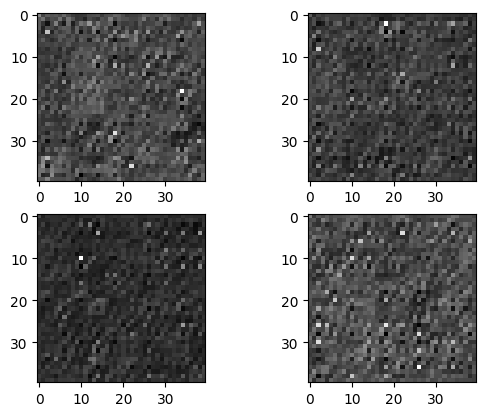

saved on epoch 300
saved on epoch 300
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - d_loss: -0.3040 - g_loss: 2.6442
Epoch 302/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.8680636882781982 std 0.041954461485147476
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.9999269]
 [0.9999323]
 [0.9998777]
 [0.9999726]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.3195 - g_loss: 3.0221
Epoch 303/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
mean -0.8577847480773926 std 0.044210340827703476
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.99999464]
 [0.99945253]
 [0.9995372 ]
 [0.9958074 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.2076 - g_loss: 2.7212
Epoch 304/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
mean -0.8659141659736633 std 0.043000828474760056
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
prediction [[0.99989164]
 [0.99987257]
 [0.99997306]
 [0.99994004]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.2609 - g_loss: 2.8118
Epoch 305/2000
1/1 ━━━━━━━━━━━━━━━━━━━━

prediction [[0.9943475 ]
 [0.99993336]
 [0.9993401 ]
 [0.9992879 ]]
saved on epoch 305


saved on epoch 305
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.2104 - g_loss: 2.6067
Epoch 307/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
mean -0.8636739253997803 std 0.041783593595027924
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
prediction [[0.9999738]
 [0.9999374]
 [0.9993563]
 [0.9997694]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.2671 - g_loss: 2.3549
Epoch 308/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8598554730415344 std 0.04151882603764534
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
prediction [[0.9994374 ]
 [0.99978095]
 [0.99862766]
 [0.9997769 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.4053 - g_loss: 2.8061
Epoch 309/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.864255428314209 std 0.04248936101794243
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
prediction [[0.9999027 ]
 [0.9999504 ]
 [0.9999502 ]
 [0.99765223]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.3068 - g_loss: 3.2038
Epoch 310/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean -0.

prediction [[0.9994199 ]
 [0.9999131 ]
 [0.9997212 ]
 [0.99999154]]
saved on epoch 310


saved on epoch 310
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.2542 - g_loss: 3.0580
Epoch 312/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
mean -0.8719422221183777 std 0.041482046246528625
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
prediction [[0.99880624]
 [0.99996173]
 [0.9999957 ]
 [0.99982774]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2935 - g_loss: 2.2209
Epoch 313/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8682515025138855 std 0.04055351763963699
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
prediction [[0.9996313]
 [0.9996512]
 [0.9999865]
 [0.9999875]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.2563 - g_loss: 1.9561
Epoch 314/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8660999536514282 std 0.041338611394166946
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
prediction [[0.9999695]
 [0.9960169]
 [0.9998635]
 [0.9999894]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.3078 - g_loss: 2.1217
Epoch 315/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
mean -0.86

...

saved on epoch 335
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - d_loss: -0.2652 - g_loss: 2.6715
Epoch 337/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
mean -0.8738602995872498 std 0.03943854942917824
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
prediction [[0.9998147 ]
 [0.99993217]
 [0.9999974 ]
 [0.9999943 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.3058 - g_loss: 3.0401
Epoch 338/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
mean -0.8667178153991699 std 0.041057150810956955
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
prediction [[0.99999034]
 [0.99965   ]
 [0.99998987]
 [0.9998299 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.2818 - g_loss: 3.5820
Epoch 339/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8674886226654053 std 0.04249945655465126
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
prediction [[0.99999356]
 [0.9999654 ]
 [0.9993673 ]
 [0.9999949 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2265 - g_loss: 3.7716
Epoch 340/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mea

prediction [[0.9999975]
 [0.9999865]
 [0.9998739]
 [0.9999926]]
saved on epoch 340


saved on epoch 340
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.2211 - g_loss: 4.1965
Epoch 342/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
mean -0.8650291562080383 std 0.04194187745451927
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
prediction [[0.99970394]
 [0.99993026]
 [0.99999845]
 [0.99971884]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2100 - g_loss: 3.5679
Epoch 343/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8704113960266113 std 0.04153202846646309
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
prediction [[0.9999937 ]
 [0.9999907 ]
 [0.9999176 ]
 [0.99997616]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2151 - g_loss: 3.2564
Epoch 344/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8585867285728455 std 0.04046868905425072
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
prediction [[0.9980696]
 [0.9997814]
 [0.9999654]
 [0.9984054]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.2248 - g_loss: 3.4772
Epoch 345/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
mean -0.

prediction [[0.9999944 ]
 [0.99999285]
 [0.9999405 ]
 [0.99997747]]
saved on epoch 345


saved on epoch 345
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.1950 - g_loss: 3.2940
Epoch 347/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
mean -0.8661187887191772 std 0.0411713682115078
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
prediction [[0.9999715]
 [0.9994055]
 [0.9999641]
 [0.9999881]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.2012 - g_loss: 3.5370
Epoch 348/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
mean -0.8694615364074707 std 0.04190722852945328
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
prediction [[0.9999708 ]
 [0.99997663]
 [0.9999981 ]
 [0.9999521 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.1588 - g_loss: 3.6371
Epoch 349/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.863971471786499 std 0.041091784834861755
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.9999237]
 [0.9999831]
 [0.9999045]
 [0.999744 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.2014 - g_loss: 3.7866
Epoch 350/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.87338

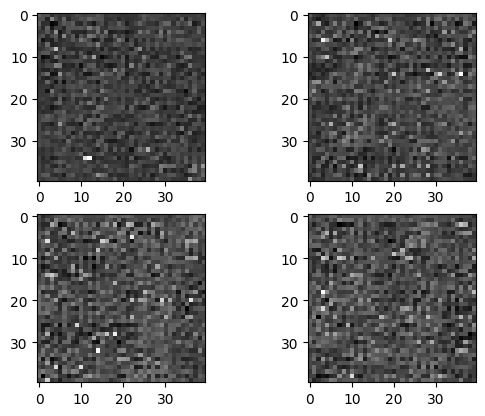

saved on epoch 350
saved on epoch 350
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - d_loss: -0.1397 - g_loss: 2.8683
Epoch 352/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
mean -0.8713842630386353 std 0.04247896373271942
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
prediction [[0.9999994 ]
 [0.99996805]
 [0.999969  ]
 [0.9999335 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.1381 - g_loss: 2.9907
Epoch 353/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8671165704727173 std 0.04230301082134247
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
prediction [[0.9999863 ]
 [0.99956256]
 [0.9999832 ]
 [0.99998415]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.1331 - g_loss: 2.9372
Epoch 354/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean -0.8632769584655762 std 0.04275032505393028
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
prediction [[0.99979955]
 [0.99983525]
 [0.9998516 ]
 [0.99999297]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.1299 - g_loss: 2.2467
Epoch 355/2000
1/1 ━━━━━━━━━━━━━━━━━━━

prediction [[0.9998988 ]
 [0.9999844 ]
 [0.9999944 ]
 [0.99963486]]
saved on epoch 355


saved on epoch 355
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - d_loss: -0.2436 - g_loss: 2.4562
Epoch 357/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
mean -0.8657611012458801 std 0.041383229196071625
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
prediction [[0.99955434]
 [0.99999046]
 [0.9999753 ]
 [0.9999082 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - d_loss: -0.1464 - g_loss: 2.8924
Epoch 358/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8667019605636597 std 0.04111363738775253
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
prediction [[0.9998216 ]
 [0.9999267 ]
 [0.99999714]
 [0.9999578 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - d_loss: -0.1883 - g_loss: 2.5022
Epoch 359/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8662044405937195 std 0.04257632791996002
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
prediction [[0.99997807]
 [0.99993396]
 [0.99999547]
 [0.9999417 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.1913 - g_loss: 2.7245
Epoch 360/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mea

prediction [[0.9999987 ]
 [0.9999908 ]
 [0.99993646]
 [0.9999542 ]]
saved on epoch 360


saved on epoch 360
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.2191 - g_loss: 2.6006
Epoch 362/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8702341318130493 std 0.043360527604818344
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
prediction [[0.99999464]
 [0.99999356]
 [0.99994504]
 [0.99999607]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.2005 - g_loss: 2.2769
Epoch 363/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8654778003692627 std 0.043126653879880905
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
prediction [[0.99997973]
 [0.9998903 ]
 [0.9999422 ]
 [0.9999372 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.2051 - g_loss: 1.9391
Epoch 364/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
mean -0.8677347302436829 std 0.04407184571027756
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
prediction [[0.99998736]
 [0.99997556]
 [0.99988186]
 [0.9999869 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.1027 - g_loss: 2.5517
Epoch 365/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
me

...

prediction [[0.99998605]
 [0.9999963 ]
 [0.99999964]
 [0.99998033]]
saved on epoch 385


saved on epoch 385
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.1800 - g_loss: 4.4088
Epoch 387/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
mean -0.869670033454895 std 0.045713864266872406
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
prediction [[0.9999733 ]
 [0.99999523]
 [0.9999826 ]
 [0.99999726]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.1279 - g_loss: 4.1378
Epoch 388/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
mean -0.8670260906219482 std 0.04637386277318001
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
prediction [[0.9999566]
 [0.9999863]
 [0.9999769]
 [0.9999993]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - d_loss: -0.1135 - g_loss: 3.9524
Epoch 389/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
mean -0.8685659170150757 std 0.04630966857075691
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
prediction [[0.9999883]
 [0.9999913]
 [0.9999726]
 [0.999997 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - d_loss: -0.1660 - g_loss: 4.1424
Epoch 390/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
mean -0.8703

prediction [[0.99995434]
 [0.9999981 ]
 [0.9999881 ]
 [0.9999982 ]]
saved on epoch 390


saved on epoch 390
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - d_loss: -0.2216 - g_loss: 3.6984
Epoch 392/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean -0.8605160713195801 std 0.04539899900555611
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
prediction [[0.9999825]
 [0.9999392]
 [0.9998437]
 [0.9995697]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - d_loss: -0.1241 - g_loss: 3.2803
Epoch 393/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8749798536300659 std 0.04777196794748306
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
prediction [[0.99999964]
 [0.99999547]
 [0.99999726]
 [0.99999654]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.1591 - g_loss: 3.4972
Epoch 394/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
mean -0.8738535046577454 std 0.0467490628361702
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
prediction [[0.9999988 ]
 [0.9999974 ]
 [0.99999976]
 [0.99995065]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.1865 - g_loss: 3.5257
Epoch 395/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8

prediction [[0.99999714]
 [0.9999993 ]
 [0.99994266]
 [0.9999938 ]]
saved on epoch 395
saved on epoch 395
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - d_loss: -0.1628 - g_loss: 3.6427
Epoch 397/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
mean -0.8711799383163452 std 0.047157153487205505
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
prediction [[0.9999989 ]
 [0.9999989 ]
 [0.99999535]
 [0.99997354]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - d_loss: -0.2905 - g_loss: 3.7897
Epoch 398/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
mean -0.8582024574279785 std 0.045125920325517654
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
prediction [[0.99999094]
 [0.9998692 ]
 [0.9999641 ]
 [0.9994147 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - d_loss: -0.2376 - g_loss: 4.1933
Epoch 399/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.8628463745117188 std 0.0474255345761776
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
prediction [[0.99985504]
 [0.99997437]
 [0.9999399 ]
 [0.99999774]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_

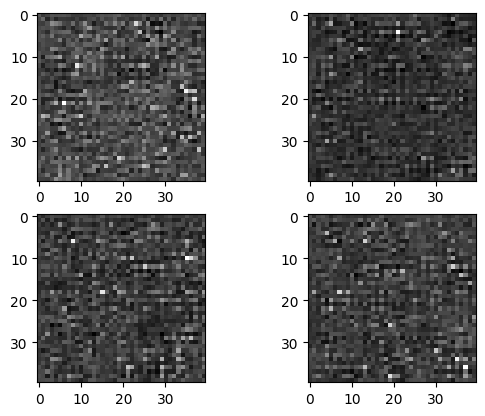

saved on epoch 400
saved on epoch 400
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - d_loss: -0.2333 - g_loss: 3.5782
Epoch 402/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8676364421844482 std 0.04532051086425781
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
prediction [[0.99999416]
 [0.99999714]
 [0.9997644 ]
 [0.9999856 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.2240 - g_loss: 3.4588
Epoch 403/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8620893359184265 std 0.04744384065270424
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
prediction [[0.99997354]
 [0.99970055]
 [0.99975914]
 [0.9999995 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.2407 - g_loss: 3.9138
Epoch 404/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
mean -0.8640366196632385 std 0.046206261962652206
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
prediction [[0.99999416]
 [0.99999833]
 [0.9997962 ]
 [0.999951  ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.1466 - g_loss: 3.7383
Epoch 405/2000
1/1 ━━━━━━━━━━━━━━━━━━

prediction [[0.9999949 ]
 [0.99999964]
 [0.99999785]
 [0.9999981 ]]
saved on epoch 405
saved on epoch 405
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - d_loss: -0.1970 - g_loss: 3.7957
Epoch 407/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
mean -0.8619000315666199 std 0.04721132293343544
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
prediction [[0.999871  ]
 [0.99999297]
 [0.9999982 ]
 [0.9999597 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - d_loss: -0.1705 - g_loss: 4.1513
Epoch 408/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
mean -0.8631852865219116 std 0.04775729775428772
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
prediction [[0.9999527 ]
 [0.9999877 ]
 [0.9999944 ]
 [0.99997854]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.1696 - g_loss: 4.3777
Epoch 409/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean -0.8690147399902344 std 0.04882977530360222
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
prediction [[0.99999654]
 [0.9999989 ]
 [0.9999994 ]
 [0.9999701 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_l

prediction [[0.9999939]
 [0.999995 ]
 [0.9999702]
 [0.9999784]]
saved on epoch 410


saved on epoch 410
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.1257 - g_loss: 5.1591
Epoch 412/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean -0.8686055541038513 std 0.047369103878736496
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
prediction [[0.999853 ]
 [0.9999838]
 [0.9999994]
 [0.9999982]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.1990 - g_loss: 4.9397
Epoch 413/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8675286769866943 std 0.04656432196497917
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
prediction [[0.9999963 ]
 [0.9999896 ]
 [0.99999094]
 [0.9999863 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.1975 - g_loss: 5.2455
Epoch 414/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
mean -0.8670071363449097 std 0.0461294949054718
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
prediction [[0.9999989 ]
 [0.99997056]
 [0.9999945 ]
 [0.99989295]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2177 - g_loss: 5.4529
Epoch 415/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean -0.

prediction [[0.99999845]
 [0.99999964]
 [0.99997854]
 [0.9999795 ]]
saved on epoch 415


...

prediction [[0.99999976]
 [0.9999962 ]
 [0.99999917]
 [0.9999989 ]]
saved on epoch 435


saved on epoch 435
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - d_loss: -0.2676 - g_loss: 4.4367
Epoch 437/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8658202290534973 std 0.048913270235061646
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
prediction [[0.99999094]
 [0.9999771 ]
 [0.9999957 ]
 [0.9999924 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - d_loss: -0.2165 - g_loss: 4.5816
Epoch 438/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8582525849342346 std 0.04804770648479462
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
prediction [[0.9999887 ]
 [0.99999   ]
 [0.99988556]
 [0.9999167 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2512 - g_loss: 4.5537
Epoch 439/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean -0.8704402446746826 std 0.04780528321862221
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
prediction [[0.99998546]
 [0.9999964 ]
 [0.99999774]
 [0.99999857]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.1844 - g_loss: 5.0520
Epoch 440/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mea

prediction [[0.999998  ]
 [0.9999933 ]
 [0.9998977 ]
 [0.99999774]]
saved on epoch 440


saved on epoch 440
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.1443 - g_loss: 6.3902
Epoch 442/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
mean -0.8671764135360718 std 0.04971589148044586
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
prediction [[0.9999974 ]
 [0.99998045]
 [0.9999975 ]
 [0.99999523]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.2194 - g_loss: 5.9364
Epoch 443/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8673983812332153 std 0.04747118800878525
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
prediction [[0.99999833]
 [0.9999883 ]
 [0.99998987]
 [0.9999857 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.2083 - g_loss: 5.4623
Epoch 444/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
mean -0.872078537940979 std 0.04906529188156128
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
prediction [[0.99999905]
 [0.99998593]
 [0.9999995 ]
 [0.999998  ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.1724 - g_loss: 5.0257
Epoch 445/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
mean 

prediction [[0.9999969]
 [0.9999994]
 [0.9999995]
 [0.9999995]]
saved on epoch 445
saved on epoch 445
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - d_loss: -0.2389 - g_loss: 5.1321
Epoch 447/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean -0.8670399188995361 std 0.04862688109278679
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
prediction [[0.9999939 ]
 [0.99998605]
 [0.9999988 ]
 [0.99994993]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - d_loss: -0.2714 - g_loss: 5.2933
Epoch 448/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
mean -0.8711656332015991 std 0.04723050817847252
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
prediction [[0.9999993]
 [0.9999931]
 [0.9999988]
 [0.9999919]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2613 - g_loss: 5.2354
Epoch 449/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8704171776771545 std 0.0487760454416275
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
prediction [[0.99999964]
 [0.9999987 ]
 [0.99998784]
 [0.9999945 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.1

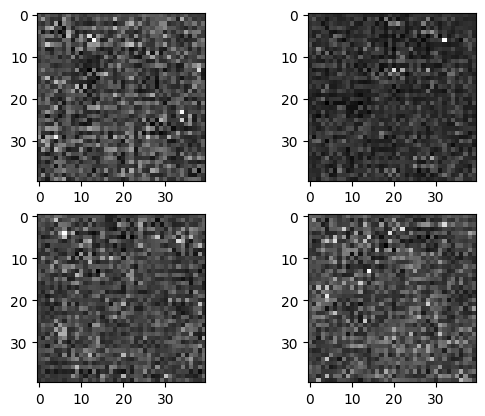

saved on epoch 450
saved on epoch 450
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - d_loss: -0.1457 - g_loss: 4.3419
Epoch 452/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8687119483947754 std 0.049646105617284775
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
prediction [[0.99994135]
 [0.99999654]
 [0.9999999 ]
 [0.9999969 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.1702 - g_loss: 4.7242
Epoch 453/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
mean -0.8682223558425903 std 0.04813981056213379
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
prediction [[0.9999982 ]
 [0.99999595]
 [0.9999887 ]
 [0.99999785]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.1765 - g_loss: 4.5581
Epoch 454/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
mean -0.8706819415092468 std 0.047487225383520126
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
prediction [[0.9999976 ]
 [0.99999213]
 [0.9999863 ]
 [0.99999833]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.1114 - g_loss: 4.2548
Epoch 455/2000
1/1 ━━━━━━━━━━━━━━━━━

prediction [[0.99999416]
 [0.99999416]
 [0.99999714]
 [0.99999666]]
saved on epoch 455


saved on epoch 455
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - d_loss: -0.1840 - g_loss: 4.3683
Epoch 457/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8639575242996216 std 0.0479143001139164
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
prediction [[0.99999404]
 [0.99993837]
 [0.9999982 ]
 [0.999964  ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.2622 - g_loss: 4.4824
Epoch 458/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8704022169113159 std 0.048327818512916565
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
prediction [[0.9999989 ]
 [0.99999785]
 [0.99999905]
 [0.9999969 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.1868 - g_loss: 4.1670
Epoch 459/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8671020269393921 std 0.04757380113005638
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
prediction [[0.99999833]
 [0.9999968 ]
 [0.99995184]
 [0.99999356]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.1479 - g_loss: 4.6102
Epoch 460/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean

prediction [[0.99999547]
 [0.9999975 ]
 [0.9999958 ]
 [0.99999774]]
saved on epoch 460


saved on epoch 460
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.0986 - g_loss: 5.5347
Epoch 462/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
mean -0.8711706399917603 std 0.047608599066734314
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
prediction [[0.9999722 ]
 [0.99999857]
 [0.9999876 ]
 [0.9999993 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.1820 - g_loss: 5.2668
Epoch 463/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8725199699401855 std 0.04720184952020645
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
prediction [[0.99999666]
 [0.99999845]
 [0.9999987 ]
 [0.9999981 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.0915 - g_loss: 4.3137
Epoch 464/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
mean -0.8683324456214905 std 0.049459051340818405
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
prediction [[0.99998903]
 [0.9999995 ]
 [0.9999982 ]
 [0.999954  ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: 0.0337 - g_loss: 4.1651 
Epoch 465/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
me

...

saved on epoch 485
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - d_loss: -0.0755 - g_loss: 5.0777
Epoch 487/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
mean -0.8712420463562012 std 0.04627520963549614
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
prediction [[0.99999785]
 [0.9999943 ]
 [0.99999774]
 [0.99999356]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.2235 - g_loss: 5.7053
Epoch 488/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
mean -0.8677220940589905 std 0.04763885214924812
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
prediction [[0.99999154]
 [0.9999968 ]
 [0.9999989 ]
 [0.99995136]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.2053 - g_loss: 6.5242
Epoch 489/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8662574887275696 std 0.04563996568322182
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
prediction [[0.9999877 ]
 [0.99998736]
 [0.9999976 ]
 [0.99992585]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.1230 - g_loss: 6.8400
Epoch 490/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
mean

prediction [[0.9999255 ]
 [0.9999956 ]
 [0.99994004]
 [0.9999975 ]]
saved on epoch 490


saved on epoch 490
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.1709 - g_loss: 6.5409
Epoch 492/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean -0.8692491054534912 std 0.04863128438591957
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
prediction [[0.999998 ]
 [0.9999945]
 [0.9999932]
 [0.9999987]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.0905 - g_loss: 6.1131
Epoch 493/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8707583546638489 std 0.04703866317868233
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
prediction [[0.99999976]
 [0.9999963 ]
 [0.9999757 ]
 [0.99997294]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.1042 - g_loss: 6.4987
Epoch 494/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.868573009967804 std 0.04672175273299217
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
prediction [[0.9999957 ]
 [0.9999956 ]
 [0.9999906 ]
 [0.99999595]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.1050 - g_loss: 6.3631
Epoch 495/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
mean -0.8

prediction [[0.9999889 ]
 [0.99999857]
 [0.999995  ]
 [0.9999746 ]]
saved on epoch 495


saved on epoch 495
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - d_loss: -0.1362 - g_loss: 6.7219
Epoch 497/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
mean -0.871042013168335 std 0.04986110329627991
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
prediction [[0.9999995 ]
 [0.9999982 ]
 [0.99998176]
 [0.9999993 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - d_loss: -0.1897 - g_loss: 6.5374
Epoch 498/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean -0.8689578771591187 std 0.04893195629119873
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
prediction [[0.99999714]
 [0.99999726]
 [0.99999666]
 [0.99999654]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.0987 - g_loss: 6.3559
Epoch 499/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
mean -0.8694413900375366 std 0.04813709855079651
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
prediction [[0.99999905]
 [0.9999989 ]
 [0.9999871 ]
 [0.9999882 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2768 - g_loss: 6.1417
Epoch 500/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean 

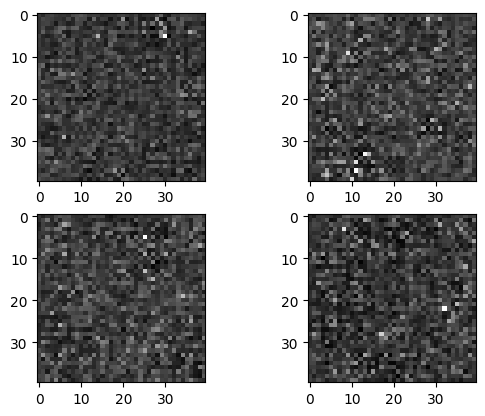

saved on epoch 500
saved on epoch 500
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - d_loss: -0.1844 - g_loss: 6.7958
Epoch 502/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.864454448223114 std 0.04622320458292961
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
prediction [[0.99999535]
 [0.99998665]
 [0.99990773]
 [0.99998415]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.2509 - g_loss: 6.7048
Epoch 503/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8713610768318176 std 0.04485572874546051
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
prediction [[0.99999714]
 [0.9999895 ]
 [0.999998  ]
 [0.99998724]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2523 - g_loss: 6.9656
Epoch 504/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8642005920410156 std 0.0453885942697525
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
prediction [[0.9999906 ]
 [0.999962  ]
 [0.9999833 ]
 [0.99999094]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2779 - g_loss: 6.5202
Epoch 505/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 

prediction [[0.99910444]
 [0.99999154]
 [0.9999994 ]
 [0.999998  ]]
saved on epoch 505
saved on epoch 505
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - d_loss: -0.2253 - g_loss: 6.6769
Epoch 507/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8730100989341736 std 0.048760637640953064
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
prediction [[0.99999964]
 [0.9999994 ]
 [0.999998  ]
 [0.9999968 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - d_loss: -0.3103 - g_loss: 6.9612
Epoch 508/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
mean -0.865354597568512 std 0.04930241405963898
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
prediction [[0.9999876 ]
 [0.99990284]
 [0.9999987 ]
 [0.9999974 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2857 - g_loss: 7.8268
Epoch 509/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean -0.8709577918052673 std 0.047638196498155594
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
prediction [[0.99998677]
 [0.9999962 ]
 [0.9999974 ]
 [0.99999917]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_

prediction [[0.999858  ]
 [0.999997  ]
 [0.99999297]
 [0.99999475]]
saved on epoch 510


saved on epoch 510
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.1723 - g_loss: 7.4342
Epoch 512/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
mean -0.8691563606262207 std 0.04670387879014015
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
prediction [[0.9999975 ]
 [0.99999475]
 [0.9999937 ]
 [0.99999523]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.2756 - g_loss: 7.0009
Epoch 513/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8636378645896912 std 0.049810636788606644
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
prediction [[0.99999535]
 [0.9999975 ]
 [0.9999975 ]
 [0.99994373]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.1090 - g_loss: 7.6392
Epoch 514/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8685594201087952 std 0.046081963926553726
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
prediction [[0.9999801 ]
 [0.99994326]
 [0.99999785]
 [0.9999926 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.1821 - g_loss: 7.9172
Epoch 515/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
me

prediction [[0.99998546]
 [0.99999607]
 [0.9999535 ]
 [0.99999905]]
saved on epoch 515


...

saved on epoch 535
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.1164 - g_loss: 6.2337
Epoch 537/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
mean -0.8649762868881226 std 0.049301888793706894
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
prediction [[0.9999838 ]
 [0.99999964]
 [0.9999945 ]
 [0.99997234]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.1931 - g_loss: 6.3927
Epoch 538/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
mean -0.8666818141937256 std 0.048835914582014084
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
prediction [[0.99999034]
 [0.999997  ]
 [0.99999726]
 [0.9999914 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.3098 - g_loss: 6.4171
Epoch 539/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
mean -0.8674579858779907 std 0.04840105026960373
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
prediction [[0.9999927 ]
 [0.99999154]
 [0.9999988 ]
 [0.9999615 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.0985 - g_loss: 6.4056
Epoch 540/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
me

prediction [[0.9999962 ]
 [0.99997413]
 [0.99997056]
 [0.99999714]]
saved on epoch 540


saved on epoch 540
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.0818 - g_loss: 6.2391
Epoch 542/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean -0.8700553178787231 std 0.04880904406309128
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
prediction [[0.9999975 ]
 [0.9999939 ]
 [0.9999931 ]
 [0.99999094]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.1577 - g_loss: 5.9656
Epoch 543/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
mean -0.8685665726661682 std 0.04908321425318718
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
prediction [[0.9999881 ]
 [0.9999943 ]
 [0.99999785]
 [0.9999969 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.1810 - g_loss: 5.7262
Epoch 544/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
mean -0.8675030469894409 std 0.04922020062804222
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
prediction [[0.99998796]
 [0.99999726]
 [0.9999945 ]
 [0.999992  ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.2768 - g_loss: 6.2021
Epoch 545/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean

prediction [[0.9999558 ]
 [0.99999654]
 [0.9999846 ]
 [0.9999908 ]]
saved on epoch 545


saved on epoch 545
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.0536 - g_loss: 6.0315
Epoch 547/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
mean -0.8639956116676331 std 0.04900020733475685
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
prediction [[0.9999584]
 [0.9999895]
 [0.9999956]
 [0.9999943]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - d_loss: -0.2792 - g_loss: 5.6067
Epoch 548/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
mean -0.8679466843605042 std 0.04803071916103363
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.9999962 ]
 [0.99999607]
 [0.9999914 ]
 [0.9999962 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.2010 - g_loss: 5.3193
Epoch 549/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8699668645858765 std 0.04960241913795471
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
prediction [[0.99997723]
 [0.9999999 ]
 [0.9999981 ]
 [0.99999535]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.1524 - g_loss: 5.4621
Epoch 550/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.

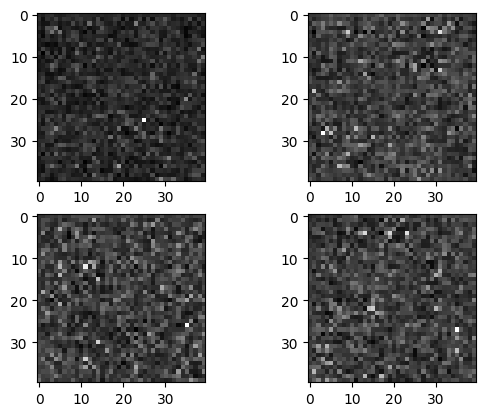

saved on epoch 550
saved on epoch 550
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - d_loss: -0.1623 - g_loss: 5.6179
Epoch 552/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean -0.8684337139129639 std 0.050763487815856934
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
prediction [[0.9999883 ]
 [0.99999905]
 [0.99999094]
 [0.999998  ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.2216 - g_loss: 5.4328
Epoch 553/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8650941252708435 std 0.04964781552553177
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
prediction [[0.99999714]
 [0.99998605]
 [0.99999225]
 [0.99999523]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.2224 - g_loss: 5.7287
Epoch 554/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8670271039009094 std 0.04818037524819374
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
prediction [[0.9999875 ]
 [0.9999958 ]
 [0.99998736]
 [0.9999982 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.0838 - g_loss: 5.6098
Epoch 555/2000
1/1 ━━━━━━━━━━━━━━━━━━

prediction [[0.99997306]
 [0.9999943 ]
 [0.99994147]
 [0.9999975 ]]
saved on epoch 555
saved on epoch 555
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - d_loss: -0.0345 - g_loss: 6.3441
Epoch 557/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
mean -0.8665509223937988 std 0.04957457631826401
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
prediction [[0.99995923]
 [0.9999969 ]
 [0.9999951 ]
 [0.99999785]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - d_loss: -0.1272 - g_loss: 7.0452
Epoch 558/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8638662695884705 std 0.04835858568549156
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
prediction [[0.9999919 ]
 [0.99998915]
 [0.999985  ]
 [0.99997723]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - d_loss: -0.0865 - g_loss: 6.9863
Epoch 559/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8710159063339233 std 0.048301007598638535
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
prediction [[0.9999987 ]
 [0.9999981 ]
 [0.9999603 ]
 [0.99999905]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_

prediction [[0.99999595]
 [0.9999919 ]
 [0.9999887 ]
 [0.9999987 ]]
saved on epoch 560


saved on epoch 560
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.2668 - g_loss: 6.5341
Epoch 562/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
mean -0.8712645769119263 std 0.049578700214624405
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
prediction [[0.9999932 ]
 [0.99999714]
 [0.99999523]
 [0.99999964]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2575 - g_loss: 6.4520
Epoch 563/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8642480373382568 std 0.048985499888658524
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
prediction [[0.9999883]
 [0.9999838]
 [0.9999604]
 [0.9999926]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.1833 - g_loss: 6.2166
Epoch 564/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8703181743621826 std 0.048422202467918396
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.99999654]
 [0.9999957 ]
 [0.999998  ]
 [0.99998367]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2138 - g_loss: 5.7434
Epoch 565/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
mean 

prediction [[0.9999875 ]
 [0.99998987]
 [0.99999845]
 [0.9999896 ]]
saved on epoch 565


...

saved on epoch 580
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.0840 - g_loss: 8.7067
Epoch 582/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8706006407737732 std 0.05016554147005081
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
prediction [[0.9999976 ]
 [0.9999987 ]
 [0.99999857]
 [0.9999988 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.1760 - g_loss: 8.7886
Epoch 583/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean -0.8662588596343994 std 0.04764140397310257
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
prediction [[0.9999304 ]
 [0.99997795]
 [0.9999969 ]
 [0.999982  ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.2984 - g_loss: 8.8682
Epoch 584/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
mean -0.8703140020370483 std 0.050986576825380325
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
prediction [[0.9999825 ]
 [0.9999759 ]
 [0.9999999 ]
 [0.99999774]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.2608 - g_loss: 8.5051
Epoch 585/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
mea

prediction [[0.9999331 ]
 [0.99997365]
 [0.9999542 ]
 [0.9999962 ]]
saved on epoch 585
saved on epoch 585
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - d_loss: -0.2409 - g_loss: 9.5732
Epoch 587/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8666379451751709 std 0.05119007080793381
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
prediction [[0.9999981 ]
 [0.9999994 ]
 [0.99998605]
 [0.99999094]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.2536 - g_loss: 9.1268
Epoch 588/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8673733472824097 std 0.05200427398085594
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
prediction [[0.99999595]
 [0.9999664 ]
 [0.99999964]
 [0.9999951 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.2370 - g_loss: 8.7631
Epoch 589/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean -0.8659433722496033 std 0.05235844478011131
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
prediction [[0.99999857]
 [0.99999154]
 [0.99999845]
 [0.99999905]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_l

prediction [[0.99999654]
 [0.9999976 ]
 [0.9999988 ]
 [0.99998283]]
saved on epoch 590


saved on epoch 590
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - d_loss: -0.2012 - g_loss: 8.1138
Epoch 592/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
mean -0.8690441250801086 std 0.04838203266263008
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
prediction [[0.9999993 ]
 [0.99999917]
 [0.999979  ]
 [0.9999883 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.2812 - g_loss: 8.8510
Epoch 593/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
mean -0.863840639591217 std 0.049723293632268906
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
prediction [[0.9999882 ]
 [0.9999995 ]
 [0.99998176]
 [0.9999722 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.0674 - g_loss: 8.3092
Epoch 594/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
mean -0.8647407293319702 std 0.051373954862356186
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
prediction [[0.99999034]
 [0.99999547]
 [0.99999297]
 [0.9999864 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.2632 - g_loss: 7.8647
Epoch 595/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
mea

prediction [[0.9999994 ]
 [0.99999666]
 [0.99998534]
 [0.9999994 ]]
saved on epoch 595
saved on epoch 595
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - d_loss: -0.1918 - g_loss: 8.3339
Epoch 597/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean -0.8665339946746826 std 0.049095965921878815
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
prediction [[0.9999813 ]
 [0.9999908 ]
 [0.999967  ]
 [0.99999905]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - d_loss: -0.2301 - g_loss: 8.5610
Epoch 598/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean -0.8665615916252136 std 0.052082955837249756
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
prediction [[0.9999783]
 [0.9999981]
 [0.9999993]
 [0.9999857]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2335 - g_loss: 8.7793
Epoch 599/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8645120859146118 std 0.050705499947071075
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
prediction [[0.99999106]
 [0.9999627 ]
 [0.9999969 ]
 [0.9999987 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_lo

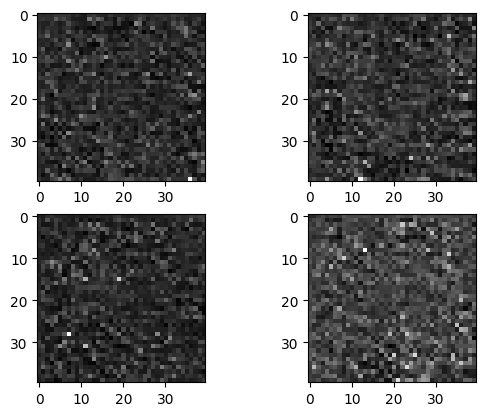

saved on epoch 600
saved on epoch 600
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - d_loss: -0.1912 - g_loss: 8.6850
Epoch 602/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
mean -0.862741231918335 std 0.05115322768688202
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
prediction [[0.9999933 ]
 [0.99998486]
 [0.9999958 ]
 [0.99998903]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.0439 - g_loss: 8.1666
Epoch 603/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8642995953559875 std 0.050592441111803055
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
prediction [[0.9999534 ]
 [0.99999416]
 [0.9999982 ]
 [0.99998045]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.2047 - g_loss: 8.7819
Epoch 604/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
mean -0.8676605224609375 std 0.052710793912410736
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
prediction [[0.9999913 ]
 [0.9999945 ]
 [0.9999976 ]
 [0.99999785]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.1014 - g_loss: 9.0424
Epoch 605/2000
1/1 ━━━━━━━━━━━━━━━━━━

prediction [[0.9999988 ]
 [0.9999851 ]
 [0.99999917]
 [0.9999982 ]]
saved on epoch 605


saved on epoch 605
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - d_loss: -0.2937 - g_loss: 9.0476
Epoch 607/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
mean -0.8647348880767822 std 0.05029705539345741
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
prediction [[0.9999975]
 [0.9999914]
 [0.9999745]
 [0.9999944]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.2711 - g_loss: 8.5088
Epoch 608/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8698333501815796 std 0.0523897148668766
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
prediction [[0.99999654]
 [0.99999857]
 [0.9999999 ]
 [0.9999982 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.1649 - g_loss: 8.0235
Epoch 609/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean -0.8650544881820679 std 0.05243629589676857
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
prediction [[0.9999701 ]
 [0.9999981 ]
 [0.99999845]
 [0.9999913 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.1999 - g_loss: 7.5712
Epoch 610/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8

prediction [[0.9999989 ]
 [0.9999734 ]
 [0.9999999 ]
 [0.99998975]]
saved on epoch 610


saved on epoch 610
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.2136 - g_loss: 6.9585
Epoch 612/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.8636417984962463 std 0.05125146731734276
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
prediction [[0.9999994]
 [0.9999981]
 [0.9999677]
 [0.9999403]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.1413 - g_loss: 7.2075
Epoch 613/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
mean -0.8647395372390747 std 0.05009334906935692
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
prediction [[0.9999896 ]
 [0.9999845 ]
 [0.9999937 ]
 [0.99998796]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.1144 - g_loss: 7.9165
Epoch 614/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
mean -0.8618055582046509 std 0.049668360501527786
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
prediction [[0.9999794]
 [0.9999802]
 [0.9999871]
 [0.9999956]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.2163 - g_loss: 7.9454
Epoch 615/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
mean -0.871

...

saved on epoch 635
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - d_loss: -0.2035 - g_loss: 8.0555
Epoch 637/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
mean -0.8695506453514099 std 0.05026907101273537
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
prediction [[0.9999881 ]
 [0.9999895 ]
 [0.9999993 ]
 [0.99999976]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.1389 - g_loss: 8.0808
Epoch 638/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8666369915008545 std 0.05129188299179077
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
prediction [[0.9999956 ]
 [0.99999607]
 [0.9999982 ]
 [0.9999976 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - d_loss: -0.1357 - g_loss: 8.1928
Epoch 639/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8664077520370483 std 0.052134089171886444
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
prediction [[0.9999958 ]
 [0.9999976 ]
 [0.9999988 ]
 [0.99999344]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.1710 - g_loss: 8.1390
Epoch 640/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
mea

prediction [[0.9999993 ]
 [0.9999906 ]
 [0.99998856]
 [0.9999989 ]]
saved on epoch 640


saved on epoch 640
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.2703 - g_loss: 7.9471
Epoch 642/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8649588227272034 std 0.052125729620456696
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
prediction [[0.9999944]
 [0.9999987]
 [0.9999926]
 [0.9999908]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - d_loss: -0.2752 - g_loss: 7.5875
Epoch 643/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
mean -0.8665573000907898 std 0.05169074982404709
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
prediction [[0.9999527 ]
 [0.9999994 ]
 [0.99998844]
 [0.99999976]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2226 - g_loss: 8.0040
Epoch 644/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
mean -0.8677721619606018 std 0.05447721853852272
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
prediction [[0.99999964]
 [0.9999989 ]
 [0.99998605]
 [0.9999989 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.1304 - g_loss: 8.2366
Epoch 645/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
mean -0

prediction [[0.99999774]
 [0.9999976 ]
 [0.99999905]
 [0.99999857]]
saved on epoch 645


saved on epoch 645
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - d_loss: -0.2871 - g_loss: 8.3295
Epoch 647/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean -0.8675514459609985 std 0.051963601261377335
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
prediction [[0.9999994 ]
 [0.99998987]
 [0.99999917]
 [0.99998283]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - d_loss: -0.1109 - g_loss: 8.1303
Epoch 648/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
mean -0.8666151165962219 std 0.0514802448451519
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
prediction [[0.9999882]
 [0.9999914]
 [0.9999987]
 [0.9999995]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.3123 - g_loss: 7.9482
Epoch 649/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
mean -0.870053231716156 std 0.05188211053609848
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
prediction [[0.99999475]
 [0.9999994 ]
 [0.99999833]
 [0.9999976 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2565 - g_loss: 7.8232
Epoch 650/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8

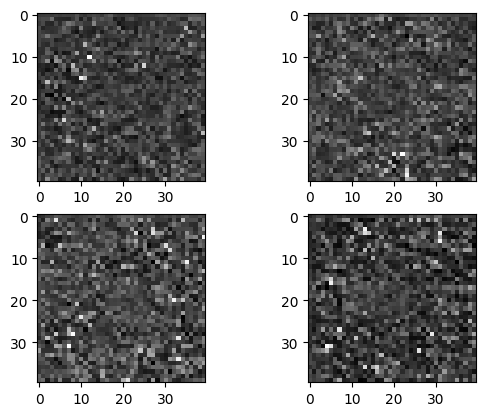

saved on epoch 650
saved on epoch 650
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - d_loss: -0.1711 - g_loss: 8.2502
Epoch 652/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
mean -0.8667823672294617 std 0.052475787699222565
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
prediction [[0.99999714]
 [0.99999464]
 [0.99999154]
 [0.99999964]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.1933 - g_loss: 8.7085
Epoch 653/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
mean -0.8695025444030762 std 0.051596611738204956
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
prediction [[0.9999924 ]
 [0.99999964]
 [0.99999785]
 [0.9999987 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.3233 - g_loss: 8.2741
Epoch 654/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
mean -0.8671470880508423 std 0.055652108043432236
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
prediction [[0.9999988 ]
 [0.99994874]
 [0.9999995 ]
 [0.99999964]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.0894 - g_loss: 8.4085
Epoch 655/2000
1/1 ━━━━━━━━━━━━━━━━

prediction [[0.99999726]
 [0.9999995 ]
 [0.99999833]
 [0.9999993 ]]
saved on epoch 655


saved on epoch 655
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.1391 - g_loss: 8.7612
Epoch 657/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8693791031837463 std 0.05315827950835228
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
prediction [[0.9999988 ]
 [0.9999995 ]
 [0.99999344]
 [0.9999982 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - d_loss: -0.4463 - g_loss: 8.4314
Epoch 658/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
mean -0.8714689016342163 std 0.05077221617102623
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
prediction [[0.99999654]
 [0.9999672 ]
 [0.9999989 ]
 [1.        ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.1406 - g_loss: 8.1242
Epoch 659/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
mean -0.8666369915008545 std 0.05177290737628937
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
prediction [[0.999995  ]
 [0.99999523]
 [0.9999982 ]
 [0.9999974 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.1691 - g_loss: 7.7843
Epoch 660/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
mean

prediction [[0.9999989]
 [0.9999497]
 [0.999995 ]
 [0.9999987]]
saved on epoch 660
saved on epoch 660
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - d_loss: -0.1954 - g_loss: 8.0584
Epoch 662/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
mean -0.8682124614715576 std 0.05077999085187912
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
prediction [[0.9999981 ]
 [0.9999975 ]
 [0.9999994 ]
 [0.99999154]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - d_loss: -0.1429 - g_loss: 8.5982
Epoch 663/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.8666741847991943 std 0.050899989902973175
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
prediction [[0.999961  ]
 [0.99999666]
 [0.9999958 ]
 [0.9999981 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: 0.0249 - g_loss: 8.7366 
Epoch 664/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.8693040609359741 std 0.05337200686335564
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
prediction [[0.99999774]
 [0.9999994 ]
 [0.9999995 ]
 [0.9999924 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss

prediction [[0.9999976 ]
 [0.99999774]
 [0.9999995 ]
 [0.99999726]]
saved on epoch 665


...

prediction [[0.9999925]
 [0.9999987]
 [0.9999988]
 [0.9999994]]
saved on epoch 685


saved on epoch 685
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.3416 - g_loss: 8.0080
Epoch 687/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
mean -0.8658092021942139 std 0.05032078176736832
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
prediction [[0.99999213]
 [0.99999607]
 [0.99999905]
 [0.99998987]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.2290 - g_loss: 8.5744
Epoch 688/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.8689756989479065 std 0.052598193287849426
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
prediction [[0.9999976]
 [0.9999994]
 [0.9999943]
 [0.9999994]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2520 - g_loss: 8.5948
Epoch 689/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
mean -0.8646212220191956 std 0.05053047463297844
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
prediction [[0.99998975]
 [0.9999944 ]
 [0.99999595]
 [0.99998355]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.3447 - g_loss: 9.2348
Epoch 690/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
mean -0

prediction [[0.9999982]
 [0.999997 ]
 [0.9999989]
 [0.9999968]]
saved on epoch 690
saved on epoch 690
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - d_loss: -0.1141 - g_loss: 9.6624
Epoch 692/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
mean -0.8667110204696655 std 0.05350774526596069
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
prediction [[0.99999833]
 [0.99999404]
 [0.9999739 ]
 [0.9999995 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - d_loss: -0.1337 - g_loss: 9.1801
Epoch 693/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.8693180680274963 std 0.05297747999429703
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
prediction [[0.9999902 ]
 [0.9999988 ]
 [0.99999964]
 [0.9999994 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.1647 - g_loss: 8.9577
Epoch 694/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
mean -0.866854727268219 std 0.052172884345054626
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
prediction [[0.9999329 ]
 [0.99999857]
 [0.9999995 ]
 [0.99999917]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss:

prediction [[0.99999285]
 [0.9999702 ]
 [0.99999785]
 [0.9999969 ]]
saved on epoch 695


saved on epoch 695
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.1755 - g_loss: 8.3171
Epoch 697/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8658033013343811 std 0.05087009072303772
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
prediction [[0.99999607]
 [0.9999864 ]
 [0.9999964 ]
 [0.999998  ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.3236 - g_loss: 8.4609
Epoch 698/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
mean -0.8691490292549133 std 0.05202430114150047
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
prediction [[0.99999917]
 [0.99999464]
 [0.99999714]
 [0.9999993 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2844 - g_loss: 8.5718
Epoch 699/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
mean -0.8654928803443909 std 0.052689455449581146
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
prediction [[0.9999993 ]
 [0.9999809 ]
 [0.99999833]
 [0.99999833]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.1864 - g_loss: 8.9501
Epoch 700/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
mea

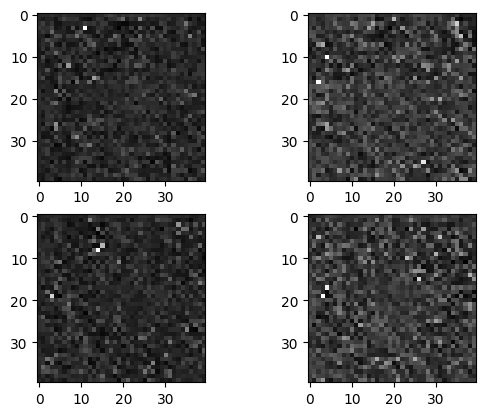

saved on epoch 700
saved on epoch 700
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - d_loss: -0.2103 - g_loss: 9.3147
Epoch 702/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
mean -0.8668232560157776 std 0.05200697109103203
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
prediction [[0.9999939 ]
 [0.99999356]
 [0.99999976]
 [0.9999876 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.2556 - g_loss: 9.3849
Epoch 703/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.8693387508392334 std 0.052324678748846054
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
prediction [[0.99999857]
 [0.9999982 ]
 [0.99999595]
 [0.9999975 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.1968 - g_loss: 9.0301
Epoch 704/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
mean -0.8684569001197815 std 0.053348444402217865
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
prediction [[0.9999994]
 [0.9999975]
 [0.9999987]
 [0.9999976]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2398 - g_loss: 9.1760
Epoch 705/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 

prediction [[0.9999987 ]
 [0.9999975 ]
 [0.99999523]
 [0.99999917]]
saved on epoch 705


saved on epoch 705
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.3328 - g_loss: 8.7027
Epoch 707/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
mean -0.8681357502937317 std 0.05009590834379196
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
prediction [[0.99999654]
 [0.99996805]
 [0.9999944 ]
 [0.99999964]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.1981 - g_loss: 8.7712
Epoch 708/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
mean -0.8663262724876404 std 0.05126693472266197
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.9999994 ]
 [0.999984  ]
 [0.999995  ]
 [0.99999356]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.0829 - g_loss: 8.9433
Epoch 709/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
mean -0.8643110394477844 std 0.05210539698600769
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
prediction [[0.9999833 ]
 [0.99997973]
 [0.9999994 ]
 [0.99999106]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.3759 - g_loss: 8.7132
Epoch 710/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
mean

prediction [[0.99996805]
 [0.99999976]
 [0.9999919 ]
 [0.9999993 ]]
saved on epoch 710


saved on epoch 710
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - d_loss: -0.2590 - g_loss: 8.8021
Epoch 712/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8642711639404297 std 0.050567690283060074
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
prediction [[0.9999968 ]
 [0.999998  ]
 [0.99980587]
 [0.999997  ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.3094 - g_loss: 9.1336
Epoch 713/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
mean -0.8712794780731201 std 0.052604250609874725
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
prediction [[0.99999785]
 [0.99999726]
 [0.99999964]
 [0.9999993 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.1588 - g_loss: 9.5669
Epoch 714/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8690007925033569 std 0.05130487680435181
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
prediction [[0.99999726]
 [0.99999964]
 [0.99999726]
 [0.99999607]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2679 - g_loss: 8.5045
Epoch 715/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
me

...

prediction [[0.99999166]
 [0.99999857]
 [0.9999962 ]
 [0.9999969 ]]
saved on epoch 735


saved on epoch 735
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - d_loss: -0.2238 - g_loss: 9.2984
Epoch 737/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8697248697280884 std 0.051536817103624344
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
prediction [[0.9999987 ]
 [0.99999654]
 [0.9999938 ]
 [0.99999976]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.3144 - g_loss: 9.3637
Epoch 738/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
mean -0.8670797944068909 std 0.054905302822589874
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.9999988 ]
 [0.99998915]
 [0.9999995 ]
 [0.9999995 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.0790 - g_loss: 9.4660
Epoch 739/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8670828342437744 std 0.05076944828033447
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
prediction [[0.99998736]
 [0.9999958 ]
 [0.9999949 ]
 [0.9999956 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2740 - g_loss: 9.0569
Epoch 740/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
me

prediction [[0.99999297]
 [0.9999877 ]
 [0.9999988 ]
 [0.9999882 ]]
saved on epoch 740


saved on epoch 740
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - d_loss: -0.2077 - g_loss: 9.6670
Epoch 742/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8678582906723022 std 0.055019401013851166
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
prediction [[0.99999917]
 [0.9999974 ]
 [0.99999404]
 [0.99999964]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.3180 - g_loss: 9.7507
Epoch 743/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
mean -0.867903470993042 std 0.051386959850788116
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
prediction [[0.9999689 ]
 [0.9999958 ]
 [0.999997  ]
 [0.99999857]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.3301 - g_loss: 9.9155
Epoch 744/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
mean -0.8631965517997742 std 0.04929351061582565
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
prediction [[0.99998534]
 [0.9999752 ]
 [0.9999956 ]
 [0.9999671 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.2440 - g_loss: 9.6724
Epoch 745/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
mea

prediction [[0.9999989]
 [0.9999963]
 [0.9999949]
 [0.9999975]]
saved on epoch 745
saved on epoch 745
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - d_loss: -0.1987 - g_loss: 9.6557
Epoch 747/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
mean -0.8672256469726562 std 0.051357001066207886
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
prediction [[0.9999982 ]
 [0.9999938 ]
 [0.9999987 ]
 [0.99999416]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - d_loss: -0.2191 - g_loss: 10.0939
Epoch 748/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
mean -0.8663151264190674 std 0.05287011340260506
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
prediction [[0.99998915]
 [0.9999918 ]
 [0.9999968 ]
 [0.99999917]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.2918 - g_loss: 10.2053
Epoch 749/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.8673973083496094 std 0.05159999802708626
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
prediction [[0.999998 ]
 [0.9999944]
 [0.9999982]
 [0.9999982]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: 

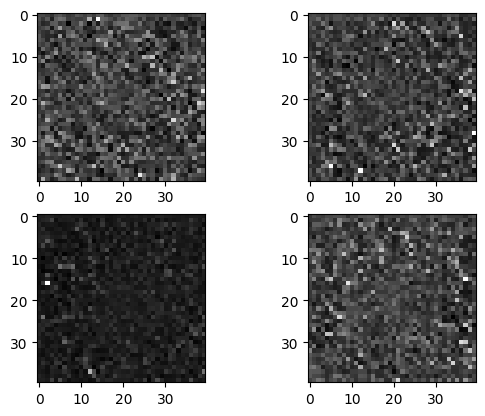

saved on epoch 750
saved on epoch 750
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - d_loss: -0.2025 - g_loss: 9.7327
Epoch 752/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
mean -0.86615389585495 std 0.04953260347247124
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
prediction [[0.99999356]
 [0.9999726 ]
 [0.9999914 ]
 [0.99999833]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.4661 - g_loss: 10.0843
Epoch 753/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8660592436790466 std 0.051026154309511185
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
prediction [[0.99999714]
 [0.9999976 ]
 [0.99998724]
 [0.9999869 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2969 - g_loss: 9.9004 
Epoch 754/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
mean -0.8669065833091736 std 0.05088718608021736
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
prediction [[0.999995  ]
 [0.9999982 ]
 [0.99998295]
 [0.999995  ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.1750 - g_loss: 9.4100
Epoch 755/2000
1/1 ━━━━━━━━━━━━━━━━━━

prediction [[0.9999957 ]
 [0.9999918 ]
 [0.99999523]
 [0.9999932 ]]
saved on epoch 755
saved on epoch 755
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - d_loss: -0.3217 - g_loss: 10.0328
Epoch 757/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.865632951259613 std 0.0517081543803215
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
prediction [[0.99998105]
 [0.99999297]
 [0.999998  ]
 [0.99999714]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.3984 - g_loss: 10.2167
Epoch 758/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
mean -0.8676449656486511 std 0.050791144371032715
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
prediction [[0.9999943 ]
 [0.9999957 ]
 [0.99999523]
 [0.9999951 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.2716 - g_loss: 9.8200
Epoch 759/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
mean -0.8657110333442688 std 0.04920608177781105
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
prediction [[0.9999715 ]
 [0.99975926]
 [0.9999963 ]
 [0.99999917]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_

prediction [[0.9999943]
 [0.9999963]
 [0.9999994]
 [0.9999974]]
saved on epoch 760


saved on epoch 760
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.2878 - g_loss: 9.1675
Epoch 762/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8666431903839111 std 0.05128699541091919
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
prediction [[0.99999475]
 [0.99999666]
 [0.9999838 ]
 [0.9999962 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2386 - g_loss: 8.9806
Epoch 763/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8661748766899109 std 0.053289417177438736
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
prediction [[0.99999523]
 [0.9999981 ]
 [0.99998593]
 [0.99999774]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2021 - g_loss: 9.0408
Epoch 764/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
mean -0.865943431854248 std 0.0521155521273613
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
prediction [[0.9999987 ]
 [0.99999106]
 [0.99999285]
 [0.9999937 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.0981 - g_loss: 9.0997
Epoch 765/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
mean 

prediction [[0.99999535]
 [0.99999905]
 [0.99997795]
 [0.99999547]]
saved on epoch 765


...

saved on epoch 785
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - d_loss: -0.2841 - g_loss: 9.7584
Epoch 787/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
mean -0.8645919561386108 std 0.04650741443037987
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
prediction [[0.99993694]
 [0.99996996]
 [0.99993074]
 [0.99999833]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2962 - g_loss: 9.1315
Epoch 788/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8685852289199829 std 0.04967913404107094
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
prediction [[0.99999857]
 [0.99999726]
 [0.99996865]
 [0.9999856 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.2636 - g_loss: 9.3289
Epoch 789/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.8667841553688049 std 0.05024844408035278
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
prediction [[0.9999883 ]
 [0.99999905]
 [0.9999616 ]
 [0.9999912 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2258 - g_loss: 9.1036
Epoch 790/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean

prediction [[0.9999826 ]
 [0.9999857 ]
 [0.99999475]
 [0.9999962 ]]
saved on epoch 790


saved on epoch 790
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - d_loss: -0.2865 - g_loss: 8.7346
Epoch 792/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8661529421806335 std 0.049714330583810806
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
prediction [[0.99999464]
 [0.9999826 ]
 [0.99998665]
 [0.9999901 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.2991 - g_loss: 8.0866
Epoch 793/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
mean -0.8682256937026978 std 0.04935939982533455
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
prediction [[0.9999975 ]
 [0.9999646 ]
 [0.99998987]
 [0.99999416]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.0526 - g_loss: 7.8453
Epoch 794/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
mean -0.867316484451294 std 0.04858491197228432
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
prediction [[0.9999912 ]
 [0.99998534]
 [0.999992  ]
 [0.99997985]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.1808 - g_loss: 8.3006
Epoch 795/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean

prediction [[0.99999034]
 [0.99999523]
 [0.9999989 ]
 [0.99999845]]
saved on epoch 795


saved on epoch 795
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.3707 - g_loss: 9.1194
Epoch 797/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
mean -0.8693699836730957 std 0.04981973022222519
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
prediction [[0.99999857]
 [0.9999989 ]
 [0.99999166]
 [0.9999906 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.1555 - g_loss: 9.7517
Epoch 798/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8666139841079712 std 0.04951731860637665
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
prediction [[0.9999671 ]
 [0.99997973]
 [0.9999908 ]
 [0.9999949 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.3158 - g_loss: 9.5230
Epoch 799/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8643754720687866 std 0.05032876133918762
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
prediction [[0.9999118 ]
 [0.99994767]
 [0.9999939 ]
 [0.9999932 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.3480 - g_loss: 9.9490
Epoch 800/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean

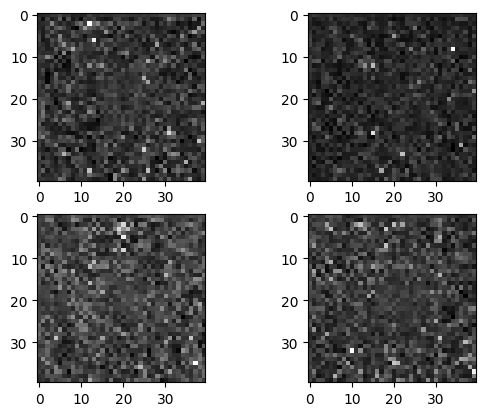

saved on epoch 800
saved on epoch 800
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - d_loss: -0.1007 - g_loss: 9.0027
Epoch 802/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
mean -0.8656614422798157 std 0.04947155341506004
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
prediction [[0.9999894 ]
 [0.9999498 ]
 [0.99999547]
 [0.9999707 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - d_loss: -0.2765 - g_loss: 9.2407
Epoch 803/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
mean -0.8687586784362793 std 0.04937194287776947
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
prediction [[0.99999595]
 [0.99996376]
 [0.9999926 ]
 [0.99999845]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.3468 - g_loss: 9.2759
Epoch 804/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
mean -0.8668994307518005 std 0.04937123879790306
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.9999875 ]
 [0.9999924 ]
 [0.9999758 ]
 [0.99999475]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.2216 - g_loss: 9.3369
Epoch 805/2000
1/1 ━━━━━━━━━━━━━━━━━━━

prediction [[0.9999974]
 [0.999913 ]
 [0.999997 ]
 [0.9999976]]
saved on epoch 805


saved on epoch 805
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.4195 - g_loss: 9.0014
Epoch 807/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8691215515136719 std 0.052212659269571304
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
prediction [[0.99996936]
 [0.99999106]
 [0.9999994 ]
 [0.99999917]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2107 - g_loss: 8.7259
Epoch 808/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8686946630477905 std 0.049867767840623856
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
prediction [[0.9999988 ]
 [0.99998665]
 [0.99998045]
 [0.9999963 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.0819 - g_loss: 8.7370
Epoch 809/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8696401715278625 std 0.05175916105508804
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
prediction [[0.99999917]
 [0.99999404]
 [0.99998474]
 [0.999998  ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.3069 - g_loss: 8.4670
Epoch 810/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
me

prediction [[0.999998  ]
 [0.99998665]
 [0.99999905]
 [0.9999974 ]]
saved on epoch 810


saved on epoch 810
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: 0.0025 - g_loss: 8.7951 
Epoch 812/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
mean -0.8641850352287292 std 0.047361742705106735
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
prediction [[0.99997747]
 [0.9999851 ]
 [0.99997437]
 [0.9999318 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - d_loss: -0.2102 - g_loss: 8.8783
Epoch 813/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
mean -0.86802077293396 std 0.0498431921005249
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
prediction [[0.99998677]
 [0.99997866]
 [0.9999975 ]
 [0.99999595]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.2920 - g_loss: 8.9308
Epoch 814/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
mean -0.8692577481269836 std 0.051152780652046204
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
prediction [[0.9999962 ]
 [0.999998  ]
 [0.9999924 ]
 [0.99998224]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - d_loss: -0.3135 - g_loss: 8.3499
Epoch 815/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
mean 

...

saved on epoch 835
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.3188 - g_loss: 8.4118
Epoch 837/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.8679391741752625 std 0.0512535497546196
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
prediction [[0.9999782 ]
 [0.99999785]
 [0.9999939 ]
 [0.9999974 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.2363 - g_loss: 8.1711
Epoch 838/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
mean -0.8657252788543701 std 0.04743840545415878
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
prediction [[0.9999181 ]
 [0.99997497]
 [0.9999908 ]
 [0.9999889 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.2154 - g_loss: 8.1659
Epoch 839/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
mean -0.8666936755180359 std 0.04961629584431648
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
prediction [[0.99996936]
 [0.99999213]
 [0.99999046]
 [0.9999732 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.1752 - g_loss: 7.5417
Epoch 840/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
mean 

prediction [[0.99997556]
 [0.9999958 ]
 [0.99998856]
 [0.99998844]]
saved on epoch 840


saved on epoch 840
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - d_loss: -0.3352 - g_loss: 7.6263
Epoch 842/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
mean -0.8640877604484558 std 0.049876708537340164
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
prediction [[0.9999509 ]
 [0.99998784]
 [0.99999416]
 [0.9997472 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2065 - g_loss: 7.6991
Epoch 843/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8686650991439819 std 0.04698384925723076
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
prediction [[0.999985  ]
 [0.9999734 ]
 [0.99999094]
 [0.9999813 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2324 - g_loss: 7.4408
Epoch 844/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8662902116775513 std 0.04683050513267517
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
prediction [[0.9999745 ]
 [0.9999409 ]
 [0.99995005]
 [0.99997985]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2763 - g_loss: 7.6340
Epoch 845/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mea

prediction [[0.99995244]
 [0.99999046]
 [0.9999474 ]
 [0.9999852 ]]
saved on epoch 845


saved on epoch 845
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.1524 - g_loss: 7.2136
Epoch 847/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
mean -0.8663893342018127 std 0.0463181734085083
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
prediction [[0.99988186]
 [0.9999924 ]
 [0.999977  ]
 [0.999979  ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - d_loss: -0.2199 - g_loss: 6.9889
Epoch 848/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
mean -0.8692368865013123 std 0.05095091834664345
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
prediction [[0.9999945 ]
 [0.99998975]
 [0.99996865]
 [0.9999976 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.3732 - g_loss: 7.6100
Epoch 849/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
mean -0.8668662905693054 std 0.05299977958202362
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
prediction [[0.999982  ]
 [0.99998105]
 [0.9999924 ]
 [0.99999535]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.2201 - g_loss: 7.5385
Epoch 850/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
mean 

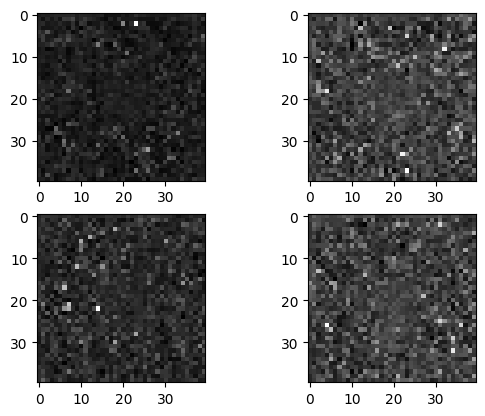

saved on epoch 850
saved on epoch 850
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - d_loss: -0.1839 - g_loss: 6.9235
Epoch 852/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
mean -0.8704650402069092 std 0.051147036254405975
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
prediction [[0.9999969 ]
 [0.9999962 ]
 [0.99999774]
 [0.99999523]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2524 - g_loss: 6.7435
Epoch 853/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.8664667010307312 std 0.048598118126392365
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.9999913 ]
 [0.9999658 ]
 [0.9999678 ]
 [0.99998224]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2682 - g_loss: 7.0935
Epoch 854/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8646818399429321 std 0.04593778774142265
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
prediction [[0.9998926]
 [0.9999676]
 [0.9999933]
 [0.9999609]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.1692 - g_loss: 7.3110
Epoch 855/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 

prediction [[0.99998236]
 [0.9999716 ]
 [0.9999896 ]
 [0.9999796 ]]
saved on epoch 855


saved on epoch 855
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.2380 - g_loss: 7.8564
Epoch 857/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8650184869766235 std 0.049624208360910416
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
prediction [[0.9999832]
 [0.999987 ]
 [0.999969 ]
 [0.9999614]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.3499 - g_loss: 7.4184
Epoch 858/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
mean -0.8710443377494812 std 0.04850774258375168
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
prediction [[0.9999732 ]
 [0.99998665]
 [0.9999918 ]
 [0.9999995 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.2068 - g_loss: 7.2751
Epoch 859/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
mean -0.8658338785171509 std 0.050996385514736176
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
prediction [[0.99997604]
 [0.99994135]
 [0.9999901 ]
 [0.9999943 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - d_loss: -0.3034 - g_loss: 7.4963
Epoch 860/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -

prediction [[0.99997616]
 [0.99999046]
 [0.9999795 ]
 [0.9999914 ]]
saved on epoch 860


saved on epoch 860
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.1217 - g_loss: 7.9478
Epoch 862/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8683534264564514 std 0.04892600327730179
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
prediction [[0.9999883 ]
 [0.99996316]
 [0.9999968 ]
 [0.99994504]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.2392 - g_loss: 7.8830
Epoch 863/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.8683469891548157 std 0.04876096174120903
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
prediction [[0.9999912 ]
 [0.99996686]
 [0.99999356]
 [0.9999858 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.3090 - g_loss: 7.7082
Epoch 864/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8682464361190796 std 0.05131899192929268
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
prediction [[0.9999703 ]
 [0.99999034]
 [0.9999858 ]
 [0.9999945 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.3833 - g_loss: 7.6992
Epoch 865/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean

...

saved on epoch 880
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.1570 - g_loss: 6.9249
Epoch 882/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
mean -0.867784857749939 std 0.052168115973472595
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
prediction [[0.99998987]
 [0.99995446]
 [0.9999943 ]
 [0.9999851 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - d_loss: -0.2394 - g_loss: 6.5001
Epoch 883/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.869599461555481 std 0.04947953671216965
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
prediction [[0.99998677]
 [0.99997497]
 [0.9999795 ]
 [0.99999917]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.4495 - g_loss: 6.3781
Epoch 884/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
mean -0.8671969771385193 std 0.047826480120420456
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
prediction [[0.99992657]
 [0.99991393]
 [0.9999802 ]
 [0.9999924 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.1987 - g_loss: 7.0405
Epoch 885/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
mean

prediction [[0.9999393 ]
 [0.9999434 ]
 [0.99998605]
 [0.99995553]]
saved on epoch 885
saved on epoch 885
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - d_loss: -0.3548 - g_loss: 7.6239
Epoch 887/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8677626252174377 std 0.049124278128147125
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
prediction [[0.999998 ]
 [0.9996407]
 [0.9999789]
 [0.999992 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.3125 - g_loss: 7.8833
Epoch 888/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8674024939537048 std 0.052024248987436295
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
prediction [[0.99999917]
 [0.9998342 ]
 [0.9999913 ]
 [0.9999659 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2804 - g_loss: 8.4174
Epoch 889/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean -0.8665956258773804 std 0.048841442912817
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
prediction [[0.99997437]
 [0.9999739 ]
 [0.9999629 ]
 [0.99999595]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss:

prediction [[0.9999964 ]
 [0.9999535 ]
 [0.99999595]
 [0.99999046]]
saved on epoch 890


saved on epoch 890
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.2405 - g_loss: 7.8368
Epoch 892/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
mean -0.8692019581794739 std 0.050805460661649704
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.999987  ]
 [0.99999166]
 [0.9999666 ]
 [0.99999166]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.2491 - g_loss: 7.4460
Epoch 893/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8679754734039307 std 0.05001340061426163
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
prediction [[0.9999733 ]
 [0.9999752 ]
 [0.99999774]
 [0.9999759 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.3286 - g_loss: 7.9288
Epoch 894/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
mean -0.8672323822975159 std 0.05007991939783096
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
prediction [[0.999948  ]
 [0.99999666]
 [0.9999827 ]
 [0.99999607]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.2288 - g_loss: 8.2928
Epoch 895/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
mea

prediction [[0.9999677 ]
 [0.99999523]
 [0.9999821 ]
 [0.99999404]]
saved on epoch 895
saved on epoch 895
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - d_loss: -0.2133 - g_loss: 7.9970
Epoch 897/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
mean -0.8656706213951111 std 0.053061265498399734
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
prediction [[0.99994004]
 [0.99998236]
 [0.9999924 ]
 [0.9999726 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: 0.0073 - g_loss: 8.1284 
Epoch 898/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean -0.8638554215431213 std 0.05383957922458649
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
prediction [[0.9999925]
 [0.999959 ]
 [0.9999913]
 [0.9999788]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.0919 - g_loss: 8.0288
Epoch 899/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8690992593765259 std 0.05025101453065872
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
prediction [[0.999987  ]
 [0.99999464]
 [0.99998915]
 [0.99998   ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss

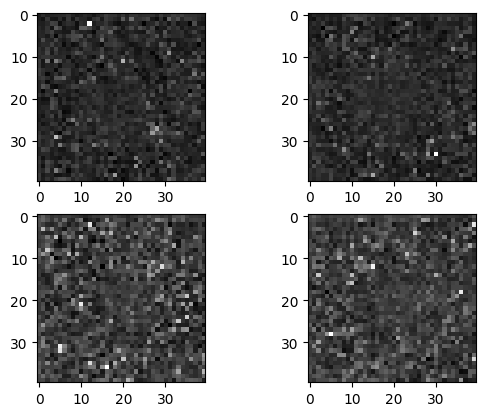

saved on epoch 900
saved on epoch 900
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - d_loss: -0.3276 - g_loss: 7.9760
Epoch 902/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8649986386299133 std 0.051753126084804535
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
prediction [[0.9999291 ]
 [0.99985814]
 [0.9999896 ]
 [0.9999956 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.2717 - g_loss: 8.0249
Epoch 903/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8677645921707153 std 0.04969280958175659
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
prediction [[0.9999932 ]
 [0.99997747]
 [0.9999958 ]
 [0.9999397 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.3816 - g_loss: 7.9764
Epoch 904/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean -0.8670613765716553 std 0.05122300982475281
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
prediction [[0.9999896 ]
 [0.99997497]
 [0.99999523]
 [0.9999691 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.1718 - g_loss: 7.5653
Epoch 905/2000
1/1 ━━━━━━━━━━━━━━━━━━

prediction [[0.9999143 ]
 [0.9999788 ]
 [0.9999815 ]
 [0.99995494]]
saved on epoch 905


saved on epoch 905
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - d_loss: -0.1227 - g_loss: 6.7641
Epoch 907/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
mean -0.8666889667510986 std 0.049578744918107986
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.9999887 ]
 [0.9999907 ]
 [0.9999883 ]
 [0.99996495]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - d_loss: -0.2646 - g_loss: 7.1303
Epoch 908/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8658651113510132 std 0.049233123660087585
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.9999167 ]
 [0.9998492 ]
 [0.99998593]
 [0.9999753 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.1843 - g_loss: 7.5661
Epoch 909/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8670071959495544 std 0.04774414747953415
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
prediction [[0.9998566 ]
 [0.99993765]
 [0.99999523]
 [0.99999225]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.2430 - g_loss: 7.2576
Epoch 910/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
me

prediction [[0.9998667]
 [0.9999889]
 [0.99998  ]
 [0.9999598]]
saved on epoch 910


saved on epoch 910
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.3529 - g_loss: 7.2710
Epoch 912/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
mean -0.8679185509681702 std 0.05158434063196182
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
prediction [[0.9994067 ]
 [0.999995  ]
 [0.99999225]
 [0.9999676 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.3316 - g_loss: 7.3100
Epoch 913/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8677574992179871 std 0.04983795806765556
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.99999523]
 [0.9999925 ]
 [0.9999449 ]
 [0.9999813 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.3184 - g_loss: 7.5816
Epoch 914/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
mean -0.867635190486908 std 0.053301483392715454
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
prediction [[0.9999943 ]
 [0.99996245]
 [0.99999976]
 [0.9999944 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2224 - g_loss: 7.8957
Epoch 915/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
mean

...

saved on epoch 930
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.3814 - g_loss: 7.4073
Epoch 932/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
mean -0.868865966796875 std 0.04690665751695633
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
prediction [[0.9999839 ]
 [0.99997663]
 [0.999977  ]
 [0.99997663]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.4272 - g_loss: 7.2790
Epoch 933/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8711207509040833 std 0.05143794044852257
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
prediction [[0.9999833 ]
 [0.9999968 ]
 [0.9999738 ]
 [0.99999833]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.3293 - g_loss: 7.1030
Epoch 934/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean -0.8675175309181213 std 0.049915093928575516
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
prediction [[0.9999865 ]
 [0.99994254]
 [0.99997926]
 [0.999948  ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2800 - g_loss: 7.0267
Epoch 935/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean

prediction [[0.9999949 ]
 [0.99996996]
 [0.99999475]
 [0.9999652 ]]
saved on epoch 935
saved on epoch 935
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - d_loss: -0.1082 - g_loss: 7.0569
Epoch 937/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
mean -0.8714945912361145 std 0.05404610186815262
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
prediction [[0.99998677]
 [0.99999714]
 [0.99999595]
 [0.9999982 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - d_loss: -0.2386 - g_loss: 7.3734
Epoch 938/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
mean -0.8696615695953369 std 0.05033083260059357
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
prediction [[0.9999789 ]
 [0.9999114 ]
 [0.9999987 ]
 [0.99999595]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.2938 - g_loss: 6.7030
Epoch 939/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
mean -0.8656916618347168 std 0.052082471549510956
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
prediction [[0.99998474]
 [0.9999554 ]
 [0.9999894 ]
 [0.9999943 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_

prediction [[0.9993285 ]
 [0.99996805]
 [0.99999714]
 [0.99999833]]
saved on epoch 940


saved on epoch 940
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - d_loss: -0.2126 - g_loss: 6.8430
Epoch 942/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8678863048553467 std 0.050113096833229065
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
prediction [[0.9999254 ]
 [0.9998659 ]
 [0.99999833]
 [0.9999939 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.3703 - g_loss: 7.0278
Epoch 943/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8649536371231079 std 0.05137597396969795
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.9999   ]
 [0.9999393]
 [0.9999888]
 [0.9999243]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2271 - g_loss: 7.2798
Epoch 944/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8684123158454895 std 0.051043685525655746
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
prediction [[0.99998975]
 [0.9999951 ]
 [0.9999951 ]
 [0.9999846 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2051 - g_loss: 6.9216
Epoch 945/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -

prediction [[0.99998915]
 [0.9999597 ]
 [0.99999225]
 [0.99999774]]
saved on epoch 945
saved on epoch 945
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - d_loss: -0.3478 - g_loss: 6.9766
Epoch 947/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
mean -0.8681033253669739 std 0.05424350127577782
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
prediction [[0.9999932 ]
 [0.9999609 ]
 [0.99999106]
 [0.9999933 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - d_loss: -0.0850 - g_loss: 7.2862
Epoch 948/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
mean -0.8659199476242065 std 0.04836362600326538
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
prediction [[0.9999701 ]
 [0.99982315]
 [0.9999788 ]
 [0.9999876 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.4751 - g_loss: 7.2150
Epoch 949/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8691502213478088 std 0.04684412106871605
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
prediction [[0.9999968 ]
 [0.99967396]
 [0.99998033]
 [0.9999596 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_l

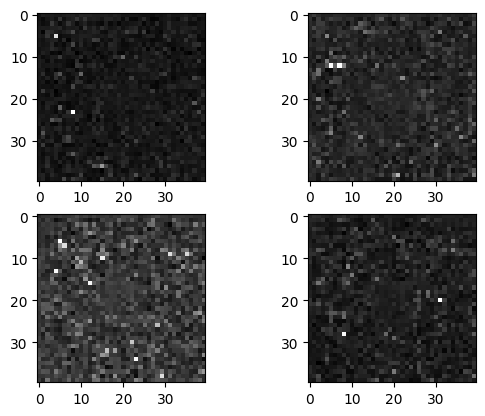

saved on epoch 950
saved on epoch 950
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - d_loss: -0.1844 - g_loss: 6.7178
Epoch 952/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8683160543441772 std 0.05014805495738983
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
prediction [[0.99997103]
 [0.99999225]
 [0.9999714 ]
 [0.999987  ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.2462 - g_loss: 6.6789
Epoch 953/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean -0.8665664792060852 std 0.05086565017700195
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
prediction [[0.9999826 ]
 [0.9999747 ]
 [0.9999908 ]
 [0.99996424]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.3686 - g_loss: 6.3472
Epoch 954/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8700603246688843 std 0.05200605094432831
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
prediction [[0.9999783 ]
 [0.99999166]
 [0.9999938 ]
 [0.99999523]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2527 - g_loss: 6.8886
Epoch 955/2000
1/1 ━━━━━━━━━━━━━━━━━━━

prediction [[0.9999578]
 [0.9999436]
 [0.9997403]
 [0.9999769]]
saved on epoch 955


saved on epoch 955
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - d_loss: -0.2917 - g_loss: 7.7813
Epoch 957/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
mean -0.8661679029464722 std 0.05025433003902435
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.99997246]
 [0.99997675]
 [0.9999739 ]
 [0.9999846 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - d_loss: -0.1241 - g_loss: 7.9104
Epoch 958/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8655372858047485 std 0.050143469125032425
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
prediction [[0.99996734]
 [0.99997747]
 [0.99998724]
 [0.99993825]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.3487 - g_loss: 7.4521
Epoch 959/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8682544231414795 std 0.05048312991857529
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
prediction [[0.9999099 ]
 [0.99998915]
 [0.99998033]
 [0.9999902 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2092 - g_loss: 7.2706
Epoch 960/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mea

prediction [[0.9997824]
 [0.9999609]
 [0.9998777]
 [0.9999869]]
saved on epoch 960


saved on epoch 960
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.1503 - g_loss: 7.4821
Epoch 962/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean -0.8672664165496826 std 0.0479198656976223
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
prediction [[0.99997807]
 [0.99996054]
 [0.99988604]
 [0.99999404]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2009 - g_loss: 7.0475
Epoch 963/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.8668283224105835 std 0.05108746141195297
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
prediction [[0.9999176 ]
 [0.999933  ]
 [0.99999774]
 [0.9999875 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.3576 - g_loss: 7.2838
Epoch 964/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.865287721157074 std 0.04675116017460823
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
prediction [[0.99996114]
 [0.99989665]
 [0.9997111 ]
 [0.99999154]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.3804 - g_loss: 6.5955
Epoch 965/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -

...

saved on epoch 985
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - d_loss: -0.1972 - g_loss: 7.6037
Epoch 987/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
mean -0.8668946623802185 std 0.04903002828359604
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
prediction [[0.99991465]
 [0.9999429 ]
 [0.9999889 ]
 [0.9999336 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.2233 - g_loss: 7.7432
Epoch 988/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8669760227203369 std 0.050159651786088943
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.99986994]
 [0.9980716 ]
 [0.9999683 ]
 [0.9999453 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - d_loss: -0.2267 - g_loss: 7.2951
Epoch 989/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.8690545558929443 std 0.05184505879878998
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
prediction [[0.9999691 ]
 [0.99993277]
 [0.99997866]
 [0.9999634 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2467 - g_loss: 7.0630
Epoch 990/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mea

prediction [[0.99996793]
 [0.9999622 ]
 [0.99995637]
 [0.99998736]]
saved on epoch 990


saved on epoch 990
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.2702 - g_loss: 7.5483
Epoch 992/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8676164150238037 std 0.050598833709955215
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
prediction [[0.9999567 ]
 [0.99992394]
 [0.99997854]
 [0.9999975 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.3122 - g_loss: 8.2708
Epoch 993/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
mean -0.8668283224105835 std 0.0551275759935379
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
prediction [[0.99989426]
 [0.99995077]
 [0.9999964 ]
 [0.99999475]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2337 - g_loss: 8.4675
Epoch 994/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
mean -0.8657251000404358 std 0.05069364607334137
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
prediction [[0.99990034]
 [0.99998426]
 [0.9999714 ]
 [0.99996114]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.3169 - g_loss: 8.6279
Epoch 995/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
mean

prediction [[0.9999653 ]
 [0.99954516]
 [0.9999813 ]
 [0.99997544]]
saved on epoch 995


saved on epoch 995
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - d_loss: -0.2428 - g_loss: 8.3451
Epoch 997/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
mean -0.8667926788330078 std 0.0512065626680851
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
prediction [[0.9999925 ]
 [0.9999242 ]
 [0.99998856]
 [0.9998635 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.1664 - g_loss: 7.5552
Epoch 998/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8675161600112915 std 0.04861780256032944
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.99917847]
 [0.9999505 ]
 [0.99998045]
 [0.9999888 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.1559 - g_loss: 7.5299
Epoch 999/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8662490844726562 std 0.05366036295890808
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.9999889]
 [0.9999478]
 [0.9999169]
 [0.9999908]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2499 - g_loss: 7.2117
Epoch 1000/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.

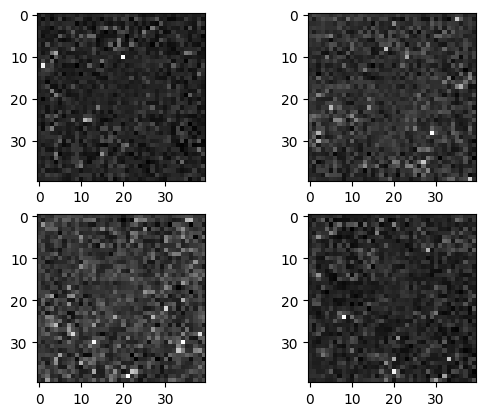

saved on epoch 1000
saved on epoch 1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - d_loss: -0.2207 - g_loss: 7.4898
Epoch 1002/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.867552638053894 std 0.0470358245074749
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
prediction [[0.9998816 ]
 [0.99990237]
 [0.99999595]
 [0.99997795]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - d_loss: -0.2978 - g_loss: 7.9649
Epoch 1003/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
mean -0.8692717552185059 std 0.05631489306688309
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
prediction [[0.9999908]
 [0.9997969]
 [0.9999957]
 [0.9999958]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - d_loss: -0.2030 - g_loss: 7.9454
Epoch 1004/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
mean -0.8664104342460632 std 0.053964585065841675
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
prediction [[0.9998702 ]
 [0.99990046]
 [0.99999225]
 [0.9999876 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - d_loss: -0.1672 - g_loss: 7.6296
Epoch 1005/2000
1/1 ━━━━━━━━━━━━━━━━━━

prediction [[0.99992883]
 [0.9997712 ]
 [0.9999863 ]
 [0.9999652 ]]
saved on epoch 1005


saved on epoch 1005
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - d_loss: -0.2670 - g_loss: 7.4712
Epoch 1007/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.870453953742981 std 0.05186677724123001
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
prediction [[0.99999523]
 [0.99999917]
 [0.99957424]
 [0.9996625 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.3900 - g_loss: 6.8479
Epoch 1008/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8664752244949341 std 0.049244850873947144
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
prediction [[0.9991303]
 [0.9999596]
 [0.9999783]
 [0.9999862]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2046 - g_loss: 6.9016
Epoch 1009/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean -0.8644514679908752 std 0.04772051423788071
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
prediction [[0.99993455]
 [0.99978584]
 [0.9999367 ]
 [0.99974567]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.1988 - g_loss: 7.0788
Epoch 1010/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
mea

prediction [[0.9998381 ]
 [0.9999782 ]
 [0.99998343]
 [0.9999591 ]]
saved on epoch 1010


saved on epoch 1010
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.1587 - g_loss: 7.3580
Epoch 1012/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean -0.8682495355606079 std 0.04914743825793266
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
prediction [[0.9998572 ]
 [0.9999887 ]
 [0.99997246]
 [0.9999951 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.3521 - g_loss: 7.2282
Epoch 1013/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
mean -0.8679121136665344 std 0.05208956450223923
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
prediction [[0.99988306]
 [0.9999294 ]
 [0.99998236]
 [0.9999734 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.1943 - g_loss: 7.3901
Epoch 1014/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
mean -0.8701474070549011 std 0.05014666169881821
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
prediction [[0.9999796 ]
 [0.999954  ]
 [0.99999976]
 [0.9999709 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.3445 - g_loss: 7.4009
Epoch 1015/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step

...

prediction [[0.9988287 ]
 [0.9998234 ]
 [0.99999785]
 [0.9999901 ]]
saved on epoch 1035
saved on epoch 1035
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - d_loss: -0.3847 - g_loss: 7.7828
Epoch 1037/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8679284453392029 std 0.0529572032392025
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
prediction [[0.9997323 ]
 [0.99994695]
 [0.999987  ]
 [0.99999464]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.3408 - g_loss: 8.0910
Epoch 1038/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean -0.8684657216072083 std 0.0510217510163784
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
prediction [[0.99995196]
 [0.9999908 ]
 [0.999992  ]
 [0.99998355]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.1529 - g_loss: 8.3360
Epoch 1039/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8692338466644287 std 0.04949260130524635
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
prediction [[0.9999678 ]
 [0.99996436]
 [0.9999982 ]
 [0.9999949 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - 

prediction [[0.9999895 ]
 [0.9999354 ]
 [0.99991345]
 [0.999987  ]]
saved on epoch 1040


saved on epoch 1040
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.2894 - g_loss: 7.9183
Epoch 1042/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8665446639060974 std 0.05051429942250252
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
prediction [[0.9998907 ]
 [0.9998797 ]
 [0.99995863]
 [0.99998033]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2966 - g_loss: 8.3959
Epoch 1043/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8670673966407776 std 0.04847486689686775
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
prediction [[0.999931  ]
 [0.99981195]
 [0.9999794 ]
 [0.99998045]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.1472 - g_loss: 8.5014
Epoch 1044/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
mean -0.867235004901886 std 0.047292064875364304
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
prediction [[0.99966156]
 [0.99979943]
 [0.9999622 ]
 [0.99998486]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.1931 - g_loss: 7.2899
Epoch 1045/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step

prediction [[0.99987924]
 [0.99995065]
 [0.99998426]
 [0.99999595]]
saved on epoch 1045


saved on epoch 1045
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - d_loss: -0.3593 - g_loss: 7.1353
Epoch 1047/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
mean -0.8687537908554077 std 0.050963230431079865
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.9999794 ]
 [0.9999136 ]
 [0.9999821 ]
 [0.99998677]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.2937 - g_loss: 7.2178
Epoch 1048/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
mean -0.8653504848480225 std 0.05007246881723404
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
prediction [[0.9999809 ]
 [0.99992335]
 [0.999936  ]
 [0.9999373 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.1825 - g_loss: 7.5190
Epoch 1049/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
mean -0.8667231798171997 std 0.05460518226027489
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
prediction [[0.9999931 ]
 [0.99969375]
 [0.99999   ]
 [0.99997747]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.3177 - g_loss: 7.3279
Epoch 1050/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/ste

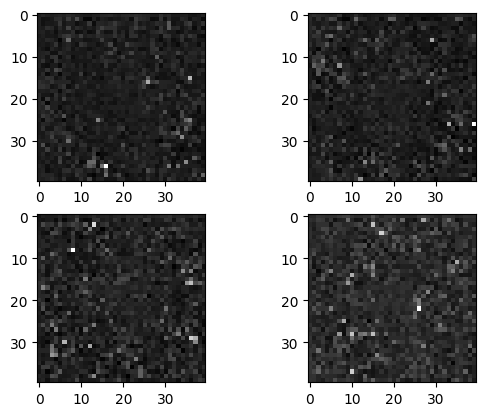

saved on epoch 1050
saved on epoch 1050
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - d_loss: -0.2090 - g_loss: 7.3439
Epoch 1052/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.869896411895752 std 0.04611285403370857
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
prediction [[0.9999534 ]
 [0.9999312 ]
 [0.99999094]
 [0.9999558 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2335 - g_loss: 6.8894
Epoch 1053/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
mean -0.867900550365448 std 0.046411510556936264
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
prediction [[0.9999659]
 [0.9998616]
 [0.9999542]
 [0.999987 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.3900 - g_loss: 6.5337
Epoch 1054/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.8681469559669495 std 0.04797230288386345
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
prediction [[0.9999399 ]
 [0.9999131 ]
 [0.9999945 ]
 [0.99997044]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.1227 - g_loss: 6.0439
Epoch 1055/2000
1/1 ━━━━━━━━━━━━━━━━━━

prediction [[0.99997973]
 [0.99991846]
 [0.999923  ]
 [0.99999106]]
saved on epoch 1055


saved on epoch 1055
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.2463 - g_loss: 6.5436
Epoch 1057/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
mean -0.867638111114502 std 0.05076732859015465
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
prediction [[0.9998635 ]
 [0.99993193]
 [0.9999728 ]
 [0.99997616]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.2093 - g_loss: 6.3300
Epoch 1058/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
mean -0.8676711916923523 std 0.053979985415935516
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
prediction [[0.9998636 ]
 [0.99994373]
 [0.9999875 ]
 [0.9999906 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.2452 - g_loss: 6.9656
Epoch 1059/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
mean -0.8663445115089417 std 0.04762817546725273
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
prediction [[0.9999429 ]
 [0.99943703]
 [0.9999229 ]
 [0.9999794 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.3450 - g_loss: 7.2649
Epoch 1060/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step

prediction [[0.99999607]
 [0.99964917]
 [0.9999559 ]
 [0.99999535]]
saved on epoch 1060


saved on epoch 1060
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - d_loss: -0.3021 - g_loss: 7.9201
Epoch 1062/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8671998381614685 std 0.049896128475666046
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
prediction [[0.9998566]
 [0.999987 ]
 [0.9999726]
 [0.9999206]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2337 - g_loss: 7.6855
Epoch 1063/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8650546073913574 std 0.04787902534008026
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
prediction [[0.999966  ]
 [0.9999291 ]
 [0.99992895]
 [0.99993753]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2369 - g_loss: 7.5376
Epoch 1064/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8659522533416748 std 0.05119779333472252
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
prediction [[0.9999757 ]
 [0.99964976]
 [0.9999547 ]
 [0.9999546 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - d_loss: -0.2010 - g_loss: 7.7863
Epoch 1065/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
me

...

prediction [[0.9999732 ]
 [0.999688  ]
 [0.9999938 ]
 [0.99991953]]
saved on epoch 1085


saved on epoch 1085
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.1618 - g_loss: 7.5343
Epoch 1087/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
mean -0.8671476244926453 std 0.050833120942115784
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.99946064]
 [0.9998603 ]
 [0.9999963 ]
 [0.9999343 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - d_loss: -0.2152 - g_loss: 7.4549
Epoch 1088/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
mean -0.8679444789886475 std 0.0590776689350605
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
prediction [[0.9995253 ]
 [0.99998057]
 [0.99999285]
 [0.9999875 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - d_loss: -0.3323 - g_loss: 7.3669
Epoch 1089/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.8673739433288574 std 0.052747756242752075
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
prediction [[0.99986887]
 [0.9997397 ]
 [0.99995935]
 [0.9999933 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - d_loss: -0.4126 - g_loss: 7.5222
Epoch 1090/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/ste

prediction [[0.9999429 ]
 [0.9996394 ]
 [0.99880564]
 [0.99998605]]
saved on epoch 1090
saved on epoch 1090
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - d_loss: -0.0396 - g_loss: 6.9915
Epoch 1092/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
mean -0.8651137351989746 std 0.05388754978775978
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
prediction [[0.9691111 ]
 [0.99982065]
 [0.9997886 ]
 [0.999951  ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - d_loss: -0.3915 - g_loss: 6.7803
Epoch 1093/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
mean -0.8671798706054688 std 0.05294094607234001
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
prediction [[0.9999933 ]
 [0.99994373]
 [0.99997735]
 [0.9999826 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - d_loss: -0.1721 - g_loss: 6.9246
Epoch 1094/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.8664414286613464 std 0.04536214843392372
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
prediction [[0.999785  ]
 [0.99991393]
 [0.9999337 ]
 [0.99997234]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step 

prediction [[0.9998994 ]
 [0.99992204]
 [0.99996734]
 [0.9999747 ]]
saved on epoch 1095


saved on epoch 1095
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - d_loss: -0.2267 - g_loss: 7.6805
Epoch 1097/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
mean -0.8671098351478577 std 0.04939812421798706
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
prediction [[0.9998405 ]
 [0.99957746]
 [0.9999906 ]
 [0.99997747]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.1876 - g_loss: 7.8417
Epoch 1098/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
mean -0.868874192237854 std 0.05065833032131195
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
prediction [[0.9996507 ]
 [0.99966586]
 [0.99999774]
 [0.9999659 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - d_loss: -0.1887 - g_loss: 7.9404
Epoch 1099/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
mean -0.866702139377594 std 0.05052933469414711
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
prediction [[0.99970883]
 [0.9999505 ]
 [0.9999927 ]
 [0.9999752 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.1783 - g_loss: 8.0452
Epoch 1100/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
m

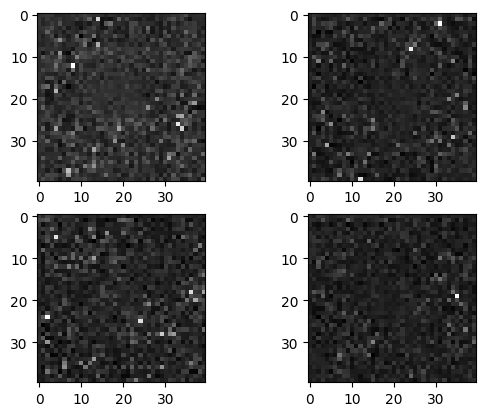

saved on epoch 1100
saved on epoch 1100
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - d_loss: -0.3390 - g_loss: 8.0191
Epoch 1102/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
mean -0.866007387638092 std 0.05570659041404724
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
prediction [[0.9999205 ]
 [0.9999194 ]
 [0.99997735]
 [0.99936646]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2890 - g_loss: 8.2482
Epoch 1103/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
mean -0.8652137517929077 std 0.056176528334617615
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
prediction [[0.9999355 ]
 [0.9974721 ]
 [0.99991274]
 [0.99149394]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.3068 - g_loss: 7.5902
Epoch 1104/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
mean -0.8656770586967468 std 0.05490696802735329
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
prediction [[0.99984133]
 [0.9992866 ]
 [0.99996495]
 [0.99776924]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.0259 - g_loss: 7.1027
Epoch 1105/2000
1/1 ━━━━━━━━━━━━━

prediction [[0.99963725]
 [0.99893564]
 [0.99993265]
 [0.9999881 ]]
saved on epoch 1105


saved on epoch 1105
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - d_loss: -0.1645 - g_loss: 7.2039
Epoch 1107/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
mean -0.8653661608695984 std 0.05218690633773804
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
prediction [[0.99942183]
 [0.9993444 ]
 [0.99998116]
 [0.99981624]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.2016 - g_loss: 7.0166
Epoch 1108/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
mean -0.868273913860321 std 0.05293363705277443
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
prediction [[0.9998853 ]
 [0.99999094]
 [0.9999521 ]
 [0.99999034]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.3514 - g_loss: 7.3668
Epoch 1109/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
mean -0.8677592277526855 std 0.048331208527088165
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
prediction [[0.9999167]
 [0.9998011]
 [0.9999664]
 [0.9999658]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.3917 - g_loss: 7.1980
Epoch 1110/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
mea

prediction [[0.9999528 ]
 [0.99994016]
 [0.9999368 ]
 [0.9999341 ]]
saved on epoch 1110


saved on epoch 1110
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.2344 - g_loss: 7.5885
Epoch 1112/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
mean -0.8686601519584656 std 0.04653969779610634
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
prediction [[0.999956  ]
 [0.99991703]
 [0.9999912 ]
 [0.9999877 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.3549 - g_loss: 7.3980
Epoch 1113/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
mean -0.8680488467216492 std 0.05620332807302475
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
prediction [[0.9999157 ]
 [0.99983454]
 [0.9975261 ]
 [0.9999527 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.2163 - g_loss: 7.2233
Epoch 1114/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
mean -0.8654992580413818 std 0.05329142510890961
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
prediction [[0.99979275]
 [0.99968135]
 [0.9982937 ]
 [0.9994791 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.3636 - g_loss: 6.9936
Epoch 1115/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step

...

saved on epoch 1135
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - d_loss: -0.2688 - g_loss: 7.9679
Epoch 1137/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
mean -0.8657029867172241 std 0.04576988145709038
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
prediction [[0.99980456]
 [0.9999137 ]
 [0.99959904]
 [0.9999716 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.1709 - g_loss: 8.0212
Epoch 1138/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
mean -0.8645695447921753 std 0.04885486885905266
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
prediction [[0.99958855]
 [0.9998623 ]
 [0.9999236 ]
 [0.99996006]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.3137 - g_loss: 8.5260
Epoch 1139/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.8655798435211182 std 0.04840199276804924
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
prediction [[0.9994093 ]
 [0.9998946 ]
 [0.9999329 ]
 [0.99994886]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2114 - g_loss: 8.8545
Epoch 1140/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

prediction [[0.99996054]
 [0.998872  ]
 [0.9999951 ]
 [0.9999902 ]]
saved on epoch 1140


saved on epoch 1140
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.4146 - g_loss: 8.8448
Epoch 1142/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.8656082153320312 std 0.042663656175136566
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
prediction [[0.9995771 ]
 [0.99922097]
 [0.9998623 ]
 [0.99994624]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.1835 - g_loss: 8.8355
Epoch 1143/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
mean -0.8656991720199585 std 0.05513798072934151
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
prediction [[0.99948895]
 [0.9990056 ]
 [0.99999475]
 [0.9998621 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.2008 - g_loss: 8.5502
Epoch 1144/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
mean -0.8654626607894897 std 0.06699904054403305
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
prediction [[0.97440785]
 [0.9985329 ]
 [0.9999645 ]
 [0.999882  ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.3190 - g_loss: 8.1861
Epoch 1145/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/ste

prediction [[0.99924076]
 [0.99993455]
 [0.9999918 ]
 [0.99996424]]
saved on epoch 1145


saved on epoch 1145
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - d_loss: -0.4638 - g_loss: 7.7273
Epoch 1147/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
mean -0.8658816814422607 std 0.05300261825323105
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
prediction [[0.9994511 ]
 [0.99465936]
 [0.9998155 ]
 [0.99996066]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - d_loss: -0.4111 - g_loss: 7.7081
Epoch 1148/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
mean -0.8655204772949219 std 0.055225472897291183
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
prediction [[0.9966344]
 [0.9995523]
 [0.9982134]
 [0.9999703]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.1955 - g_loss: 7.8453
Epoch 1149/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
mean -0.8663460612297058 std 0.050859589129686356
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
prediction [[0.9997136 ]
 [0.9996259 ]
 [0.9999603 ]
 [0.99994636]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2606 - g_loss: 7.9590
Epoch 1150/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
m

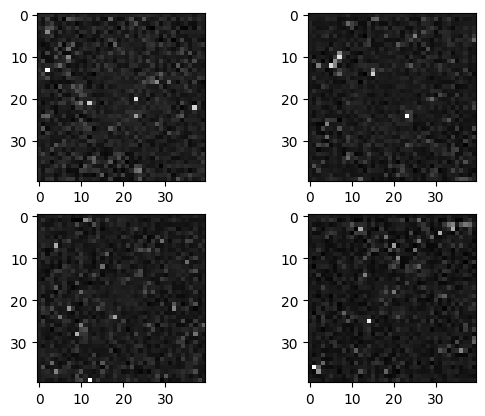

saved on epoch 1150
saved on epoch 1150
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - d_loss: -0.3052 - g_loss: 7.3465
Epoch 1152/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8686226606369019 std 0.04869316890835762
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
prediction [[0.9999671 ]
 [0.99993193]
 [0.9999964 ]
 [0.9999145 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2891 - g_loss: 7.8798
Epoch 1153/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.8614300489425659 std 0.059144437313079834
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
prediction [[0.9997056 ]
 [0.3807658 ]
 [0.9999832 ]
 [0.99986243]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.0319 - g_loss: 7.8084
Epoch 1154/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
mean -0.8672468066215515 std 0.052874863147735596
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
prediction [[0.99998975]
 [0.999534  ]
 [0.99999416]
 [0.9998871 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.2270 - g_loss: 8.0593
Epoch 1155/2000
1/1 ━━━━━━━━━━━

prediction [[0.98890334]
 [0.99988973]
 [0.9999505 ]
 [0.9999659 ]]
saved on epoch 1155
saved on epoch 1155
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - d_loss: -0.1505 - g_loss: 8.2381
Epoch 1157/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.8641090393066406 std 0.05540773272514343
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
prediction [[0.99995005]
 [0.99978536]
 [0.99996996]
 [0.9999722 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - d_loss: -0.1005 - g_loss: 8.7989
Epoch 1158/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8670390248298645 std 0.048297178000211716
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
prediction [[0.99991846]
 [0.99994195]
 [0.9999683 ]
 [0.9999714 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.3371 - g_loss: 8.8660
Epoch 1159/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
mean -0.8675496578216553 std 0.048879195004701614
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.9999026]
 [0.9998908]
 [0.9999268]
 [0.9999552]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - 

prediction [[0.99977225]
 [0.9999131 ]
 [0.9999471 ]
 [0.9999893 ]]
saved on epoch 1160


saved on epoch 1160
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.0570 - g_loss: 8.9383
Epoch 1162/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8647865056991577 std 0.06255646049976349
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.99992204]
 [0.99995327]
 [0.9999957 ]
 [0.99994004]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.4154 - g_loss: 8.5977
Epoch 1163/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8662593364715576 std 0.0525406077504158
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
prediction [[0.9998379 ]
 [0.99989724]
 [0.99999285]
 [0.9999387 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.5702 - g_loss: 8.2740
Epoch 1164/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
mean -0.8668789863586426 std 0.05292240157723427
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
prediction [[0.99975425]
 [0.99993885]
 [0.9999819 ]
 [0.9999845 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.3321 - g_loss: 8.4036
Epoch 1165/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


prediction [[0.9999839]
 [0.9996302]
 [0.9999943]
 [0.9998826]]
saved on epoch 1165


...

prediction [[0.9997689 ]
 [0.88737875]
 [0.99998665]
 [0.99986804]]
saved on epoch 1185


saved on epoch 1185
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.2380 - g_loss: 7.6311
Epoch 1187/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.8695247769355774 std 0.05030873417854309
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
prediction [[0.9999889 ]
 [0.9999213 ]
 [0.9999944 ]
 [0.99997485]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.3463 - g_loss: 7.5313
Epoch 1188/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
mean -0.8677404522895813 std 0.04642752930521965
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
prediction [[0.9986922 ]
 [0.99985266]
 [0.9999969 ]
 [0.99992406]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.1891 - g_loss: 6.9942
Epoch 1189/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
mean -0.8672646880149841 std 0.054386552423238754
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
prediction [[0.99993277]
 [0.99997973]
 [0.9999058 ]
 [0.99999225]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - d_loss: -0.3140 - g_loss: 7.3609
Epoch 1190/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/ste

prediction [[0.9992373 ]
 [0.9999018 ]
 [0.99982554]
 [0.99992216]]
saved on epoch 1190


saved on epoch 1190
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.2871 - g_loss: 7.4249
Epoch 1192/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8659648299217224 std 0.0523909367620945
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.9995734 ]
 [0.99994457]
 [0.999772  ]
 [0.9999894 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.2287 - g_loss: 7.8095
Epoch 1193/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.8663283586502075 std 0.05428118258714676
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
prediction [[0.99977034]
 [0.99962854]
 [0.99997044]
 [0.99994326]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.3540 - g_loss: 7.9818
Epoch 1194/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.8663782477378845 std 0.05178443714976311
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.99912375]
 [0.999587  ]
 [0.9999665 ]
 [0.99997175]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2787 - g_loss: 8.2277
Epoch 1195/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


prediction [[0.9996524 ]
 [0.99900985]
 [0.9999901 ]
 [0.99998987]]
saved on epoch 1195
saved on epoch 1195
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - d_loss: -0.1782 - g_loss: 8.1044
Epoch 1197/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.865070641040802 std 0.05798371136188507
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
prediction [[0.98944736]
 [0.99864477]
 [0.9999776 ]
 [0.99512756]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2522 - g_loss: 7.7316
Epoch 1198/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
mean -0.8674083948135376 std 0.051848117262125015
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
prediction [[0.9999883 ]
 [0.999882  ]
 [0.999923  ]
 [0.99996567]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.2639 - g_loss: 8.3594
Epoch 1199/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
mean -0.8657960295677185 std 0.04884820058941841
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
prediction [[0.9999075]
 [0.999665 ]
 [0.9999714]
 [0.9999635]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - d_

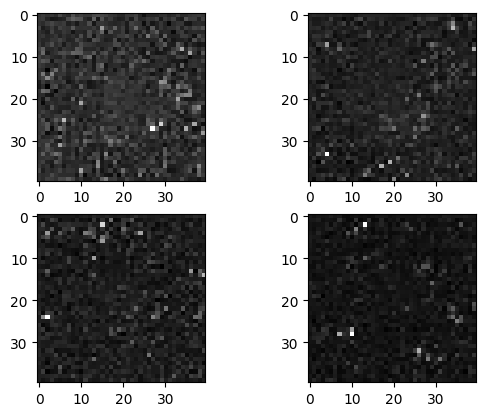

saved on epoch 1200
saved on epoch 1200
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - d_loss: -0.2175 - g_loss: 8.3970
Epoch 1202/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
mean -0.8669911026954651 std 0.05302789434790611
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
prediction [[0.99971765]
 [0.9999838 ]
 [0.999959  ]
 [0.99995947]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.2424 - g_loss: 8.4216
Epoch 1203/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.8646009564399719 std 0.0555124431848526
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
prediction [[0.99945444]
 [0.99975425]
 [0.9998641 ]
 [0.9999777 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.1696 - g_loss: 8.3861
Epoch 1204/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8680462837219238 std 0.054097939282655716
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.99990785]
 [0.99984324]
 [0.99999106]
 [0.9999732 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: 0.0114 - g_loss: 8.6548 
Epoch 1205/2000
1/1 ━━━━━━━━━━━━━

prediction [[0.99981445]
 [0.9979412 ]
 [0.9997973 ]
 [0.9998646 ]]
saved on epoch 1205


saved on epoch 1205
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - d_loss: -0.2213 - g_loss: 8.0011
Epoch 1207/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
mean -0.8690122961997986 std 0.05310822278261185
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
prediction [[0.99954164]
 [0.9998299 ]
 [0.9999739 ]
 [0.9999887 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - d_loss: -0.2318 - g_loss: 7.5719
Epoch 1208/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8678066730499268 std 0.04654498025774956
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
prediction [[0.99994457]
 [0.9997776 ]
 [0.9996929 ]
 [0.9999316 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.3148 - g_loss: 7.5229
Epoch 1209/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.8653332591056824 std 0.054631493985652924
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
prediction [[0.99975055]
 [0.9919348 ]
 [0.99999344]
 [0.99993813]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.0308 - g_loss: 7.8197
Epoch 1210/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/ste

prediction [[0.9995121 ]
 [0.12119007]
 [0.9999838 ]
 [0.9999093 ]]
saved on epoch 1210


saved on epoch 1210
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.2166 - g_loss: 8.1314
Epoch 1212/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8664016723632812 std 0.05626961216330528
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
prediction [[0.9998387]
 [0.9999708]
 [0.9998729]
 [0.9998784]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2336 - g_loss: 7.8514
Epoch 1213/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8626707196235657 std 0.06076214462518692
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
prediction [[0.9668509 ]
 [0.9543583 ]
 [0.99996793]
 [0.99988294]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.1968 - g_loss: 7.7333
Epoch 1214/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8682025074958801 std 0.055028028786182404
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
prediction [[0.99990904]
 [0.9998654 ]
 [0.99980515]
 [0.99999034]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.2468 - g_loss: 7.9375
Epoch 1215/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
me

...

prediction [[0.99977034]
 [0.9999876 ]
 [0.9999273 ]
 [0.9999646 ]]
saved on epoch 1235


saved on epoch 1235
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - d_loss: -0.1922 - g_loss: 6.9018
Epoch 1237/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
mean -0.8649244904518127 std 0.05742509290575981
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.9962935 ]
 [0.9993057 ]
 [0.99986684]
 [0.99997985]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.1837 - g_loss: 6.4566
Epoch 1238/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.866992712020874 std 0.048727359622716904
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
prediction [[0.99991155]
 [0.99744946]
 [0.99997747]
 [0.9999547 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.3292 - g_loss: 6.3999
Epoch 1239/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8678801655769348 std 0.0483207032084465
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
prediction [[0.9992198 ]
 [0.99983716]
 [0.9999634 ]
 [0.99998367]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.0634 - g_loss: 6.3512
Epoch 1240/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


prediction [[0.9998332]
 [0.967709 ]
 [0.9998267]
 [0.9999883]]
saved on epoch 1240


saved on epoch 1240
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - d_loss: -0.0584 - g_loss: 6.1715
Epoch 1242/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.866995096206665 std 0.049634866416454315
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
prediction [[0.99902654]
 [0.9996606 ]
 [0.99997973]
 [0.9998965 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.0907 - g_loss: 5.9339
Epoch 1243/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.8651964068412781 std 0.058275770395994186
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
prediction [[0.9983374 ]
 [0.9968631 ]
 [0.9999609 ]
 [0.99807274]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.3100 - g_loss: 6.1355
Epoch 1244/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
mean -0.8644813299179077 std 0.05367022752761841
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.04213751]
 [0.99552506]
 [0.99991465]
 [0.99994576]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.2166 - g_loss: 6.3006
Epoch 1245/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/ste

prediction [[0.9998485 ]
 [0.99966824]
 [0.9997347 ]
 [0.9998765 ]]
saved on epoch 1245
saved on epoch 1245
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - d_loss: -0.3448 - g_loss: 6.8247
Epoch 1247/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
mean -0.8671501278877258 std 0.05478198453783989
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
prediction [[0.99987066]
 [0.9999198 ]
 [0.99999   ]
 [0.9999918 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - d_loss: -0.1992 - g_loss: 7.5862
Epoch 1248/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
mean -0.8663719892501831 std 0.05278030037879944
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
prediction [[0.98726386]
 [0.997787  ]
 [0.999795  ]
 [0.9999502 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.2778 - g_loss: 7.6740
Epoch 1249/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
mean -0.863158643245697 std 0.0605824813246727
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
prediction [[0.9533965 ]
 [0.9999441 ]
 [0.99996424]
 [0.9998381 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - 

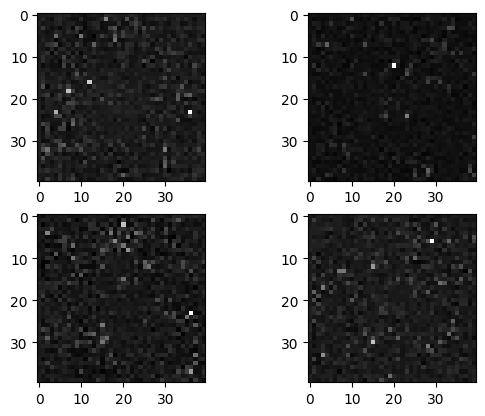

saved on epoch 1250
saved on epoch 1250
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - d_loss: -0.4193 - g_loss: 8.3329
Epoch 1252/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8689625263214111 std 0.052760858088731766
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
prediction [[0.9994905 ]
 [0.99993455]
 [0.9999844 ]
 [0.99789315]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.1545 - g_loss: 8.7219
Epoch 1253/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8634274005889893 std 0.04925982654094696
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
prediction [[0.997375 ]
 [0.9963229]
 [0.9999541]
 [0.9999633]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.1316 - g_loss: 9.0031
Epoch 1254/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8652907609939575 std 0.04472115635871887
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.999592  ]
 [0.9998765 ]
 [0.99964845]
 [0.99994683]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.0484 - g_loss: 9.3038
Epoch 1255/2000
1/1 ━━━━━━━━━━━━━━━━

prediction [[0.999008 ]
 [0.9994246]
 [0.999928 ]
 [0.9999187]]
saved on epoch 1255


saved on epoch 1255
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - d_loss: -0.4434 - g_loss: 9.3946
Epoch 1257/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
mean -0.8651049137115479 std 0.05154668167233467
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
prediction [[0.9035797 ]
 [0.999931  ]
 [0.99993706]
 [0.99998534]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - d_loss: -0.1622 - g_loss: 9.5712
Epoch 1258/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
mean -0.8678205013275146 std 0.044263675808906555
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
prediction [[0.9994344 ]
 [0.99967813]
 [0.9999378 ]
 [0.9999701 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - d_loss: -0.3313 - g_loss: 9.9583
Epoch 1259/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
mean -0.8669316172599792 std 0.044825632125139236
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
prediction [[0.99714535]
 [0.999539  ]
 [0.9998123 ]
 [0.9999732 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - d_loss: -0.2451 - g_loss: 9.7637
Epoch 1260/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/st

prediction [[0.9992501 ]
 [0.998543  ]
 [0.99990416]
 [0.99992263]]
saved on epoch 1260
saved on epoch 1260
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - d_loss: -0.1935 - g_loss: 9.1389
Epoch 1262/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8678373694419861 std 0.050918083637952805
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
prediction [[0.9998698 ]
 [0.999853  ]
 [0.99995923]
 [0.999987  ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.2323 - g_loss: 8.9989
Epoch 1263/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8684449791908264 std 0.048652246594429016
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
prediction [[0.99505854]
 [0.99988127]
 [0.9998429 ]
 [0.9998983 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.2909 - g_loss: 8.4644
Epoch 1264/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
mean -0.8663954734802246 std 0.05172884836792946
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
prediction [[0.99883896]
 [0.99946207]
 [0.99977964]
 [0.99993944]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/ste

prediction [[0.9997639 ]
 [0.9998307 ]
 [0.99977475]
 [0.99954337]]
saved on epoch 1265


...

saved on epoch 1285
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.2999 - g_loss: 9.0992
Epoch 1287/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8661180138587952 std 0.051383715122938156
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
prediction [[0.9995303]
 [0.9978079]
 [0.9999628]
 [0.9999677]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - d_loss: -0.3173 - g_loss: 8.6691
Epoch 1288/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.8660556077957153 std 0.04957788065075874
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.9998567 ]
 [0.99398947]
 [0.9999411 ]
 [0.99990356]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.1917 - g_loss: 8.4960
Epoch 1289/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.865886926651001 std 0.05755526199936867
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
prediction [[0.9982167]
 [0.9989755]
 [0.9999534]
 [0.9999856]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.1323 - g_loss: 8.5229
Epoch 1290/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0

prediction [[0.99999344]
 [0.9999566 ]
 [0.9832796 ]
 [0.9997675 ]]
saved on epoch 1290


saved on epoch 1290
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.1367 - g_loss: 8.1783
Epoch 1292/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
mean -0.8664885759353638 std 0.05447078496217728
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
prediction [[0.9991756 ]
 [0.99989855]
 [0.99989974]
 [0.9997023 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - d_loss: -0.1481 - g_loss: 8.0270
Epoch 1293/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.867156982421875 std 0.04973172768950462
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
prediction [[0.99836725]
 [0.99981314]
 [0.99992836]
 [0.99999535]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - d_loss: -0.2605 - g_loss: 8.3070
Epoch 1294/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
mean -0.8660638928413391 std 0.051310762763023376
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
prediction [[0.9763365 ]
 [0.99981564]
 [0.99947685]
 [0.9999881 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.1348 - g_loss: 8.3531
Epoch 1295/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

prediction [[0.01563238]
 [0.99988353]
 [0.9995578 ]
 [0.99945706]]
saved on epoch 1295


saved on epoch 1295
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.1932 - g_loss: 8.7779
Epoch 1297/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8692954182624817 std 0.04853782057762146
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
prediction [[0.9991015]
 [0.9998735]
 [0.9999355]
 [0.9999969]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: 0.0178 - g_loss: 8.7320 
Epoch 1298/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8694806694984436 std 0.046696677803993225
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
prediction [[0.999134 ]
 [0.9996557]
 [0.9999504]
 [0.9998771]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.3598 - g_loss: 8.8172
Epoch 1299/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8652406334877014 std 0.05845088139176369
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
prediction [[0.93799937]
 [0.9978206 ]
 [0.9999906 ]
 [0.9987226 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.2212 - g_loss: 9.0059
Epoch 1300/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -

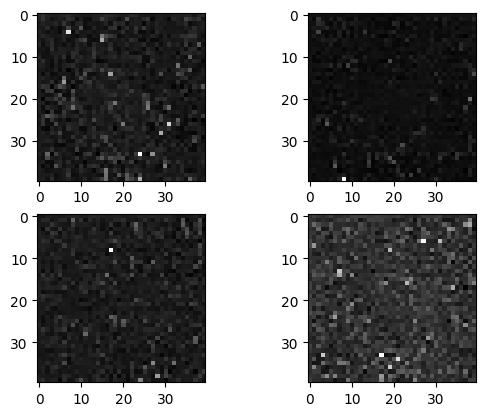

saved on epoch 1300
saved on epoch 1300
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - d_loss: -0.1911 - g_loss: 9.1995
Epoch 1302/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
mean -0.8688371181488037 std 0.05654195696115494
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
prediction [[0.99943644]
 [0.99993336]
 [0.99990785]
 [0.99976474]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - d_loss: -0.1919 - g_loss: 8.9640
Epoch 1303/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
mean -0.8680259585380554 std 0.04907144978642464
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
prediction [[0.99991167]
 [0.76108164]
 [0.9999715 ]
 [0.9999839 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.3272 - g_loss: 9.3958
Epoch 1304/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
mean -0.8654270768165588 std 0.049793876707553864
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
prediction [[0.09008612]
 [0.9989434 ]
 [0.99984014]
 [0.999848  ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.3586 - g_loss: 9.3107
Epoch 1305/2000
1/1 ━━━━━━━━━━━━

prediction [[0.9980373 ]
 [0.9993063 ]
 [0.99999475]
 [0.99987364]]
saved on epoch 1305


saved on epoch 1305
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -4.3039e-04 - g_loss: 9.0497
Epoch 1307/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.864745020866394 std 0.05211717262864113
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.96146005]
 [0.99952817]
 [0.99980766]
 [0.9998404 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.3140 - g_loss: 8.9804
Epoch 1308/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8674669861793518 std 0.05410020053386688
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
prediction [[0.9931035]
 [0.9998171]
 [0.9999902]
 [0.9999895]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.1841 - g_loss: 8.7990
Epoch 1309/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
mean -0.8674842715263367 std 0.050608161836862564
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
prediction [[0.9994129 ]
 [0.9996275 ]
 [0.99988794]
 [0.99997425]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.1987 - g_loss: 8.4033
Epoch 1310/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

prediction [[0.97750825]
 [0.99970204]
 [0.9999567 ]
 [0.99979764]]
saved on epoch 1310


saved on epoch 1310
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.2818 - g_loss: 7.5563
Epoch 1312/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean -0.8663528561592102 std 0.05322875827550888
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.9999143 ]
 [0.9977132 ]
 [0.9999938 ]
 [0.99666256]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.5463 - g_loss: 7.6619
Epoch 1313/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
mean -0.8655775189399719 std 0.059986576437950134
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
prediction [[0.19995974]
 [0.9978594 ]
 [0.9999777 ]
 [0.99996936]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.1989 - g_loss: 7.6003
Epoch 1314/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
mean -0.8652987480163574 std 0.05644090101122856
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
prediction [[0.9925881 ]
 [0.0947149 ]
 [0.9999373 ]
 [0.99984396]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - d_loss: -0.1344 - g_loss: 8.1506
Epoch 1315/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/ste

...

prediction [[0.7827328]
 [0.9995524]
 [0.9999734]
 [0.9999502]]
saved on epoch 1335


saved on epoch 1335
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.3918 - g_loss: 7.7981
Epoch 1337/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
mean -0.867979884147644 std 0.052352678030729294
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
prediction [[0.99787974]
 [0.99687225]
 [0.9999553 ]
 [0.9999976 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - d_loss: -0.3891 - g_loss: 8.1259
Epoch 1338/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.8670631647109985 std 0.05299704149365425
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
prediction [[0.99987304]
 [0.9992493 ]
 [0.9999362 ]
 [0.9999695 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: 0.1315 - g_loss: 8.0085 
Epoch 1339/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
mean -0.8686923384666443 std 0.04850231856107712
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
prediction [[0.9990238 ]
 [0.9998554 ]
 [0.99999225]
 [0.9998442 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2219 - g_loss: 8.0286
Epoch 1340/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

prediction [[0.998038  ]
 [0.9969829 ]
 [0.99976236]
 [0.99986243]]
saved on epoch 1340
saved on epoch 1340
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - d_loss: -0.0348 - g_loss: 8.3321
Epoch 1342/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
mean -0.8694289922714233 std 0.04619873687624931
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
prediction [[0.99971384]
 [0.99976605]
 [0.999856  ]
 [0.9999156 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - d_loss: -0.1509 - g_loss: 7.9771
Epoch 1343/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
mean -0.8673559427261353 std 0.054483264684677124
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
prediction [[0.9814207 ]
 [0.99998426]
 [0.99961865]
 [0.9999298 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - d_loss: -0.0125 - g_loss: 7.6788
Epoch 1344/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
mean -0.8655039072036743 std 0.05079492926597595
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
prediction [[0.99930596]
 [0.9999163 ]
 [0.99901474]
 [0.99992585]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step

prediction [[0.99251515]
 [0.9985455 ]
 [0.979882  ]
 [0.999824  ]]
saved on epoch 1345


saved on epoch 1345
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.3387 - g_loss: 7.8568
Epoch 1347/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean -0.8649107217788696 std 0.04838448762893677
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.94849324]
 [0.99177647]
 [0.9999229 ]
 [0.99907935]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.3156 - g_loss: 7.7105
Epoch 1348/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
mean -0.8656190633773804 std 0.05306801199913025
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
prediction [[0.9988387 ]
 [0.99891627]
 [0.9971625 ]
 [0.9999666 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2317 - g_loss: 7.8136
Epoch 1349/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.864047110080719 std 0.05808917433023453
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
prediction [[0.99973804]
 [0.99697316]
 [0.9999542 ]
 [0.9998281 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.1709 - g_loss: 7.7991
Epoch 1350/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


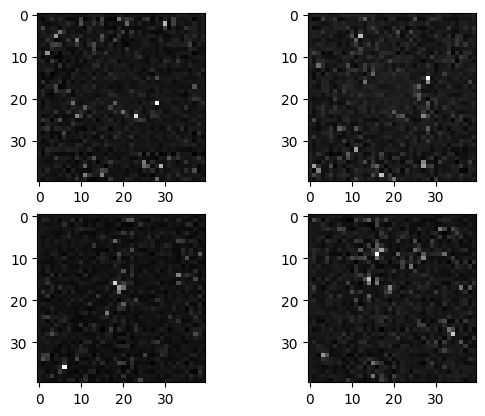

saved on epoch 1350
saved on epoch 1350
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - d_loss: -0.3157 - g_loss: 8.7731
Epoch 1352/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
mean -0.8657362461090088 std 0.05300530791282654
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
prediction [[0.99905604]
 [0.93285465]
 [0.9999876 ]
 [0.99991274]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - d_loss: -0.1619 - g_loss: 8.6652
Epoch 1353/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
mean -0.8674188256263733 std 0.05218040198087692
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
prediction [[0.99816257]
 [0.9999455 ]
 [0.999318  ]
 [0.99987936]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.0645 - g_loss: 8.8527
Epoch 1354/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8674616813659668 std 0.04817068576812744
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
prediction [[0.9990778 ]
 [0.99973875]
 [0.99997973]
 [0.99982846]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.0354 - g_loss: 7.8657
Epoch 1355/2000
1/1 ━━━━━━━━━━━━━

prediction [[0.9997236 ]
 [0.9668769 ]
 [0.99994063]
 [0.99997795]]
saved on epoch 1355


saved on epoch 1355
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.3805 - g_loss: 8.1741
Epoch 1357/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8682200908660889 std 0.04875672981142998
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.9984699 ]
 [0.9960444 ]
 [0.99934965]
 [0.99993277]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2418 - g_loss: 8.3939
Epoch 1358/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8672535419464111 std 0.05398724973201752
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
prediction [[0.99986243]
 [0.99937516]
 [0.99939156]
 [0.99990296]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.1572 - g_loss: 8.3093
Epoch 1359/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8658221364021301 std 0.05004490166902542
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
prediction [[0.9925978 ]
 [0.00403864]
 [0.9999131 ]
 [0.99984586]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.1827 - g_loss: 8.3007
Epoch 1360/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

prediction [[0.99912935]
 [0.9797989 ]
 [0.99965525]
 [0.9998989 ]]
saved on epoch 1360


saved on epoch 1360
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - d_loss: -0.2978 - g_loss: 8.4518
Epoch 1362/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
mean -0.8668147325515747 std 0.05058663338422775
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
prediction [[0.99956876]
 [0.9995586 ]
 [0.99998236]
 [0.9999213 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - d_loss: -0.1493 - g_loss: 8.2758
Epoch 1363/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
mean -0.8669594526290894 std 0.05539140850305557
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
prediction [[0.9998603 ]
 [0.9982141 ]
 [0.99988747]
 [0.99837875]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - d_loss: -0.3078 - g_loss: 7.9587
Epoch 1364/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
mean -0.868370771408081 std 0.05006236955523491
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
prediction [[0.99993646]
 [0.9990625 ]
 [0.99974054]
 [0.99973696]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - d_loss: -0.2112 - g_loss: 8.0096
Epoch 1365/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


...

saved on epoch 1380
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.1399 - g_loss: 7.1769
Epoch 1382/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8655563592910767 std 0.059103019535541534
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.5555791 ]
 [0.9994134 ]
 [0.99978405]
 [0.9998411 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.3231 - g_loss: 7.0165
Epoch 1383/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.863908052444458 std 0.06551705300807953
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
prediction [[9.9749041e-01]
 [3.0089216e-04]
 [9.9523675e-01]
 [9.9994016e-01]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.2089 - g_loss: 7.4105
Epoch 1384/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
mean -0.8638153076171875 std 0.05413305014371872
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
prediction [[0.11254211]
 [0.9974855 ]
 [0.999944  ]
 [0.99983275]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.1929 - g_loss: 7.5955
Epoch 1385/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 

prediction [[0.10471665]
 [0.9980147 ]
 [0.9997353 ]
 [0.99977106]]
saved on epoch 1385
saved on epoch 1385
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - d_loss: -0.4275 - g_loss: 7.2949
Epoch 1387/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.868610143661499 std 0.0497545450925827
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
prediction [[0.99974114]
 [0.9986488 ]
 [0.99987984]
 [0.99985063]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.2426 - g_loss: 7.4422
Epoch 1388/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.8661543130874634 std 0.05697384849190712
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.998961  ]
 [0.9980451 ]
 [0.99995995]
 [0.99996614]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.1632 - g_loss: 7.8548
Epoch 1389/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean -0.8678210377693176 std 0.060166846960783005
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
prediction [[0.9997149 ]
 [0.99577844]
 [0.9999634 ]
 [0.9999392 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step -

prediction [[0.994978  ]
 [0.99865156]
 [0.32925516]
 [0.99996233]]
saved on epoch 1390


saved on epoch 1390
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.4634 - g_loss: 7.2113
Epoch 1392/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8683671355247498 std 0.04986421763896942
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
prediction [[0.9871006 ]
 [0.99870443]
 [0.9999639 ]
 [0.9998983 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2975 - g_loss: 7.1244
Epoch 1393/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.8683986663818359 std 0.052307307720184326
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
prediction [[0.9995474 ]
 [0.9981351 ]
 [0.9999341 ]
 [0.99993503]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.1294 - g_loss: 7.0171
Epoch 1394/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
mean -0.8678638935089111 std 0.051487602293491364
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
prediction [[0.9980749 ]
 [0.9958215 ]
 [0.99994075]
 [0.99995136]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - d_loss: -0.1757 - g_loss: 6.7625
Epoch 1395/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/st

prediction [[0.9967939 ]
 [0.99924845]
 [0.9995888 ]
 [0.9999502 ]]
saved on epoch 1395
saved on epoch 1395
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - d_loss: -0.2970 - g_loss: 6.3130
Epoch 1397/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
mean -0.8680926561355591 std 0.05030980706214905
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
prediction [[0.99762076]
 [0.9997737 ]
 [0.99989605]
 [0.9997137 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.0806 - g_loss: 6.1028
Epoch 1398/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8666937351226807 std 0.055277228355407715
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
prediction [[0.9946832 ]
 [0.99930704]
 [0.99926835]
 [0.99996746]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.1671 - g_loss: 6.5451
Epoch 1399/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8654371500015259 std 0.054796382784843445
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
prediction [[0.99986696]
 [0.96256834]
 [0.99993646]
 [0.99863017]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/ste

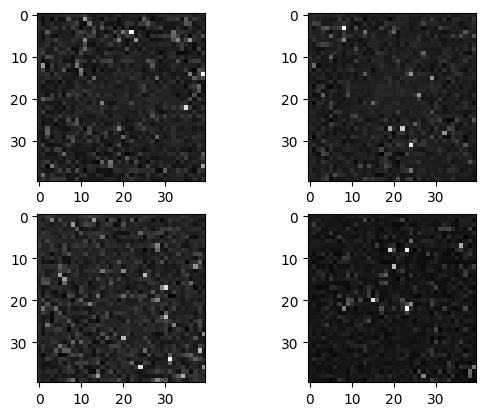

saved on epoch 1400
saved on epoch 1400
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - d_loss: -0.2424 - g_loss: 7.1747
Epoch 1402/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8645039200782776 std 0.05489887297153473
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
prediction [[0.99971455]
 [0.39583093]
 [0.9997242 ]
 [0.9748838 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.2646 - g_loss: 7.2893
Epoch 1403/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
mean -0.8686747550964355 std 0.0459773913025856
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
prediction [[0.9978751 ]
 [0.99828595]
 [0.9999312 ]
 [0.99988616]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.4957 - g_loss: 7.2666
Epoch 1404/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
mean -0.8668136596679688 std 0.047977980226278305
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.999605  ]
 [0.9562844 ]
 [0.999416  ]
 [0.99921405]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.1304 - g_loss: 7.6509
Epoch 1405/2000
1/1 ━━━━━━━━━━━━━

prediction [[0.99909794]
 [0.9997658 ]
 [0.99937445]
 [0.9999796 ]]
saved on epoch 1405
saved on epoch 1405
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - d_loss: -0.2831 - g_loss: 7.3405
Epoch 1407/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8649468421936035 std 0.05523376166820526
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
prediction [[0.9977781 ]
 [0.00238514]
 [0.9998795 ]
 [0.9999274 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.2215 - g_loss: 7.8654
Epoch 1408/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
mean -0.8665188550949097 std 0.051276929676532745
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.56011045]
 [0.9983005 ]
 [0.9996164 ]
 [0.99874485]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.0166 - g_loss: 7.4909
Epoch 1409/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8651481866836548 std 0.05349188297986984
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
prediction [[0.8715408 ]
 [0.96682703]
 [0.99957854]
 [0.9997526 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step

prediction [[0.99295217]
 [0.8977994 ]
 [0.99844605]
 [0.9999603 ]]
saved on epoch 1410


saved on epoch 1410
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - d_loss: -0.2192 - g_loss: 7.2173
Epoch 1412/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
mean -0.8664032220840454 std 0.060897741466760635
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.11444996]
 [0.99593437]
 [0.999295  ]
 [0.9998367 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.3205 - g_loss: 7.6850
Epoch 1413/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8646826148033142 std 0.05759502574801445
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
prediction [[0.9970612 ]
 [0.99155116]
 [0.99978393]
 [0.99985135]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.1051 - g_loss: 7.5938
Epoch 1414/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
mean -0.8659104704856873 std 0.04851783812046051
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
prediction [[0.9983234 ]
 [0.9989409 ]
 [0.99968433]
 [0.99973136]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - d_loss: -0.0805 - g_loss: 7.5938
Epoch 1415/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/ste

prediction [[0.9998739]
 [0.9995696]
 [0.9994779]
 [0.9999778]]
saved on epoch 1415


...

prediction [[0.9978878]
 [0.9993703]
 [0.9995541]
 [0.9998313]]
saved on epoch 1430
saved on epoch 1430
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - d_loss: -0.4021 - g_loss: 6.4216
Epoch 1432/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
mean -0.8666878342628479 std 0.05311617627739906
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.5230904]
 [0.9770265]
 [0.9998242]
 [0.9995254]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - d_loss: -0.2660 - g_loss: 6.7435
Epoch 1433/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
mean -0.8647887706756592 std 0.05457480251789093
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
prediction [[0.9967609 ]
 [0.07735769]
 [0.9999255 ]
 [0.9999316 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: 0.0194 - g_loss: 6.8660 
Epoch 1434/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
mean -0.8646000623703003 std 0.055860985070466995
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
prediction [[0.95557195]
 [0.02834013]
 [0.99915123]
 [0.9999536 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - d_los

prediction [[0.9995921 ]
 [0.9978835 ]
 [0.99987674]
 [0.9999082 ]]
saved on epoch 1435
saved on epoch 1435
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - d_loss: -0.1542 - g_loss: 6.7422
Epoch 1437/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
mean -0.8665850758552551 std 0.04792135953903198
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
prediction [[0.9972657 ]
 [0.9976018 ]
 [0.9999684 ]
 [0.99897015]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - d_loss: -0.2408 - g_loss: 6.7464
Epoch 1438/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
mean -0.865060567855835 std 0.056632429361343384
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.27607855]
 [0.6697077 ]
 [0.9999094 ]
 [0.99987376]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.3065 - g_loss: 6.7484
Epoch 1439/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
mean -0.8671382069587708 std 0.05603891983628273
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
prediction [[0.6381394]
 [0.9998882]
 [0.9997788]
 [0.9999137]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_

prediction [[0.95429975]
 [0.99971634]
 [0.99994826]
 [0.9999558 ]]
saved on epoch 1440


saved on epoch 1440
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - d_loss: -0.3087 - g_loss: 6.4697
Epoch 1442/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.868618905544281 std 0.04942648857831955
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
prediction [[0.9987006 ]
 [0.9984407 ]
 [0.99998903]
 [0.9997321 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - d_loss: -0.2759 - g_loss: 6.6442
Epoch 1443/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8665910363197327 std 0.05341380834579468
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
prediction [[0.9932868 ]
 [0.96014166]
 [0.99994576]
 [0.9998048 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.1754 - g_loss: 6.7624
Epoch 1444/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8669316172599792 std 0.05748583748936653
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
prediction [[0.9992526 ]
 [0.64531815]
 [0.9999491 ]
 [0.99987674]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.4365 - g_loss: 6.6474
Epoch 1445/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


prediction [[0.9987735 ]
 [0.9985292 ]
 [0.9999528 ]
 [0.99961084]]
saved on epoch 1445
saved on epoch 1445
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - d_loss: -0.2211 - g_loss: 7.3470
Epoch 1447/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
mean -0.86484694480896 std 0.061755791306495667
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
prediction [[0.94095796]
 [0.92882115]
 [0.99966514]
 [0.9999988 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.1846 - g_loss: 7.2686
Epoch 1448/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
mean -0.8660262823104858 std 0.05031163990497589
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.999218  ]
 [0.8073584 ]
 [0.99696606]
 [0.9995821 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.1984 - g_loss: 7.1458
Epoch 1449/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8675060272216797 std 0.051471397280693054
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.999648  ]
 [0.999821  ]
 [0.99989784]
 [0.999694  ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step 

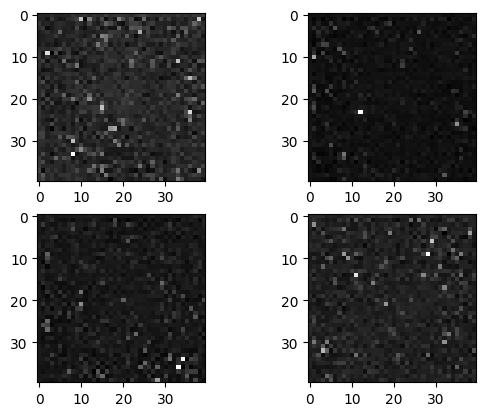

saved on epoch 1450
saved on epoch 1450
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - d_loss: -0.2114 - g_loss: 6.6291
Epoch 1452/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8642973303794861 std 0.0595291405916214
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.97535616]
 [0.99320716]
 [0.995568  ]
 [0.9999615 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2991 - g_loss: 6.6993
Epoch 1453/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8632983565330505 std 0.06855061650276184
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
prediction [[6.8056178e-01]
 [3.2271602e-04]
 [9.9995422e-01]
 [9.9999511e-01]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.1170 - g_loss: 7.1076
Epoch 1454/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8671056628227234 std 0.050039708614349365
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
prediction [[0.9967175]
 [0.9997768]
 [0.9998634]
 [0.9999056]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.1400 - g_loss: 7.0988
Epoch 1455/2000
1/1 ━━━━━

prediction [[0.9995865]
 [0.9997187]
 [0.9999416]
 [0.9999306]]
saved on epoch 1455
saved on epoch 1455
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - d_loss: -0.0919 - g_loss: 7.3663
Epoch 1457/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
mean -0.8672851324081421 std 0.055732619017362595
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
prediction [[0.9995185 ]
 [0.9996885 ]
 [0.99923384]
 [0.9999901 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - d_loss: -0.1475 - g_loss: 7.5142
Epoch 1458/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8660687208175659 std 0.056183960288763046
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
prediction [[0.96623594]
 [0.99473554]
 [0.99941635]
 [0.9997923 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.2776 - g_loss: 7.3585
Epoch 1459/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8673065304756165 std 0.050932031124830246
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
prediction [[0.99964035]
 [0.91136855]
 [0.9918    ]
 [0.9930108 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step -

prediction [[0.9998653 ]
 [0.9920827 ]
 [0.99995947]
 [0.9999535 ]]
saved on epoch 1460


saved on epoch 1460
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.2309 - g_loss: 7.2573
Epoch 1462/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
mean -0.8647453188896179 std 0.05427421256899834
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
prediction [[0.99765414]
 [0.9846577 ]
 [0.9984281 ]
 [0.99973196]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.1892 - g_loss: 7.6268
Epoch 1463/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8666551113128662 std 0.05228588357567787
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
prediction [[0.99978286]
 [0.9996896 ]
 [0.9943327 ]
 [0.9992268 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.1423 - g_loss: 7.4708
Epoch 1464/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
mean -0.8657556772232056 std 0.05784858390688896
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
prediction [[0.9933651 ]
 [0.34980652]
 [0.99942976]
 [0.9997619 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.0829 - g_loss: 7.5261
Epoch 1465/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step

prediction [[0.9998282 ]
 [0.99917525]
 [0.99912137]
 [0.9989962 ]]
saved on epoch 1465
saved on epoch 1465
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - d_loss: -0.0891 - g_loss: 7.5167
Epoch 1467/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
mean -0.8677912950515747 std 0.048952244222164154
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
prediction [[0.99789786]
 [0.99998224]
 [0.999884  ]
 [0.99983895]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.2399 - g_loss: 7.7783
Epoch 1468/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
mean -0.8625625371932983 std 0.0658840537071228
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
prediction [[9.9542975e-01]
 [1.7508425e-04]
 [9.6494126e-01]
 [9.9946254e-01]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.2388 - g_loss: 7.6176
Epoch 1469/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.866198718547821 std 0.050584495067596436
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
prediction [[0.9987436 ]
 [0.88431054]
 [0.9998054 ]
 [0.99994934]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1

...

saved on epoch 1480
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - d_loss: -0.2039 - g_loss: 9.0083
Epoch 1482/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
mean -0.8655722141265869 std 0.051648691296577454
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
prediction [[0.9941309 ]
 [0.9901614 ]
 [0.99992645]
 [0.95703983]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - d_loss: -0.3861 - g_loss: 9.1811
Epoch 1483/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8649272322654724 std 0.05010728910565376
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.19291516]
 [0.99427867]
 [0.9996754 ]
 [0.9427883 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.1245 - g_loss: 9.3099
Epoch 1484/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
mean -0.8671143054962158 std 0.04861695319414139
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
prediction [[0.9991906 ]
 [0.9695453 ]
 [0.9991185 ]
 [0.99973553]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.0797 - g_loss: 9.1491
Epoch 1485/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/ste

prediction [[0.94843364]
 [0.99967945]
 [0.9999373 ]
 [0.9970381 ]]
saved on epoch 1485
saved on epoch 1485
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - d_loss: -0.1828 - g_loss: 9.1398
Epoch 1487/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
mean -0.867867648601532 std 0.04530344158411026
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
prediction [[0.99957246]
 [0.9936759 ]
 [0.999783  ]
 [0.99957365]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - d_loss: -0.2691 - g_loss: 9.3568
Epoch 1488/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
mean -0.8648823499679565 std 0.05770222470164299
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
prediction [[0.9239074 ]
 [0.15823285]
 [0.9998723 ]
 [0.99964356]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - d_loss: -0.0964 - g_loss: 9.2920
Epoch 1489/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
mean -0.8670084476470947 std 0.04950454831123352
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.99316335]
 [0.9898694 ]
 [0.9999435 ]
 [0.99978596]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step -

prediction [[0.9911829 ]
 [0.99223846]
 [0.99956244]
 [0.999845  ]]
saved on epoch 1490


saved on epoch 1490
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - d_loss: -0.2381 - g_loss: 8.8903
Epoch 1492/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8682340979576111 std 0.05326224863529205
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
prediction [[0.99986696]
 [0.9973901 ]
 [0.9999219 ]
 [0.99969494]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.2505 - g_loss: 9.1220
Epoch 1493/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8645089864730835 std 0.061160892248153687
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.99792385]
 [0.97244126]
 [0.99854326]
 [0.98041016]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.4047 - g_loss: 9.5510
Epoch 1494/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8659562468528748 std 0.05285570025444031
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.99630016]
 [0.9978738 ]
 [0.9997178 ]
 [0.9999368 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2732 - g_loss: 9.6575
Epoch 1495/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/ste

prediction [[0.99874854]
 [0.00123805]
 [0.999928  ]
 [0.99994135]]
saved on epoch 1495
saved on epoch 1495
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - d_loss: -0.3727 - g_loss: 10.3274
Epoch 1497/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
mean -0.8678392767906189 std 0.048674777150154114
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
prediction [[0.9987507 ]
 [0.9983535 ]
 [0.99992204]
 [0.99944896]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - d_loss: -0.2013 - g_loss: 10.2554
Epoch 1498/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
mean -0.8692276477813721 std 0.047727081924676895
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
prediction [[0.99592054]
 [0.98106956]
 [0.99940777]
 [0.998958  ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - d_loss: -0.3624 - g_loss: 10.2524
Epoch 1499/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8666866421699524 std 0.048085931688547134
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
prediction [[0.99945027]
 [0.99979454]
 [0.99990046]
 [0.99985945]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms

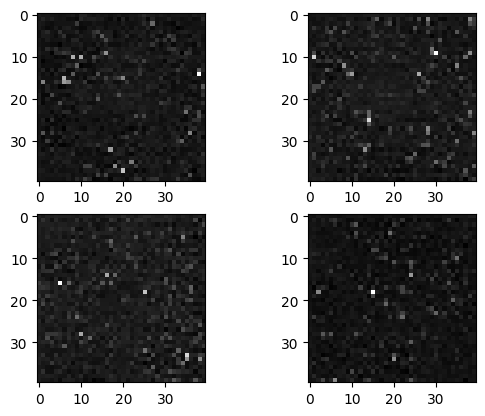

saved on epoch 1500
saved on epoch 1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - d_loss: -0.1976 - g_loss: 9.4052
Epoch 1502/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
mean -0.8658747673034668 std 0.05198485776782036
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
prediction [[0.99973756]
 [0.9967278 ]
 [0.999951  ]
 [0.9963425 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.1606 - g_loss: 9.2829
Epoch 1503/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
mean -0.8661019206047058 std 0.053037844598293304
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
prediction [[0.07270622]
 [0.9992455 ]
 [0.9999567 ]
 [0.9998018 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.0165 - g_loss: 9.1948
Epoch 1504/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
mean -0.8670770525932312 std 0.05330286920070648
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
prediction [[0.99992  ]
 [0.9939877]
 [0.9999262]
 [0.999645 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.1025 - g_loss: 9.5207
Epoch 1505/2000
1/1 ━━━━━━━━━━━━━━━━

prediction [[0.9967525 ]
 [0.99908996]
 [0.9999596 ]
 [0.99661726]]
saved on epoch 1505


saved on epoch 1505
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - d_loss: -0.1683 - g_loss: 8.7787
Epoch 1507/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
mean -0.8661874532699585 std 0.052451279014348984
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
prediction [[0.9965031 ]
 [0.6976697 ]
 [0.9991248 ]
 [0.99982685]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.1494 - g_loss: 8.5294
Epoch 1508/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
mean -0.8655272126197815 std 0.06463500112295151
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
prediction [[0.9985757 ]
 [0.9989519 ]
 [0.99980026]
 [0.9984717 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.1607 - g_loss: 8.2392
Epoch 1509/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
mean -0.8678401708602905 std 0.04414450749754906
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
prediction [[0.99833626]
 [0.996813  ]
 [0.99993515]
 [0.99956125]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - d_loss: -0.1953 - g_loss: 7.8550
Epoch 1510/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/ste

prediction [[0.06380355]
 [0.99996054]
 [0.9998596 ]
 [0.9999018 ]]
saved on epoch 1510


saved on epoch 1510
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - d_loss: -0.2539 - g_loss: 8.8091
Epoch 1512/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
mean -0.8652409315109253 std 0.05562170222401619
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
prediction [[0.99203295]
 [0.9992482 ]
 [0.99953806]
 [0.99990094]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - d_loss: -0.3686 - g_loss: 8.9253
Epoch 1513/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
mean -0.8631818890571594 std 0.056996364146471024
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
prediction [[0.99620086]
 [0.9941393 ]
 [0.99947923]
 [0.43378398]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.0348 - g_loss: 9.2160
Epoch 1514/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
mean -0.8665261268615723 std 0.049263834953308105
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
prediction [[0.99794906]
 [0.9995701 ]
 [0.9996269 ]
 [0.99997973]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.3079 - g_loss: 9.1152
Epoch 1515/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/st

...

saved on epoch 1535
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - d_loss: -0.0315 - g_loss: 9.2184
Epoch 1537/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
mean -0.8683421611785889 std 0.0463334321975708
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
prediction [[0.99728894]
 [0.9995121 ]
 [0.9996259 ]
 [0.9984641 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - d_loss: -0.3195 - g_loss: 9.4328
Epoch 1538/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
mean -0.8636053204536438 std 0.057635750621557236
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
prediction [[0.99907327]
 [0.9951232 ]
 [0.99994075]
 [0.9998821 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - d_loss: -0.2318 - g_loss: 9.6276
Epoch 1539/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
mean -0.866504967212677 std 0.051759686321020126
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
prediction [[0.998292  ]
 [0.99943966]
 [0.9999207 ]
 [0.9993395 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.0228 - g_loss: 9.5927
Epoch 1540/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

prediction [[0.9076972 ]
 [0.9614131 ]
 [0.999982  ]
 [0.99986446]]
saved on epoch 1540


saved on epoch 1540
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.5392 - g_loss: 9.0882
Epoch 1542/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
mean -0.8640415668487549 std 0.05241772159934044
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
prediction [[0.9733434 ]
 [0.9993475 ]
 [0.99950266]
 [0.9810503 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.0887 - g_loss: 9.5208
Epoch 1543/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.867451012134552 std 0.04696270823478699
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
prediction [[0.8238702 ]
 [0.47058   ]
 [0.9997956 ]
 [0.99990606]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.1757 - g_loss: 9.5297
Epoch 1544/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
mean -0.8663994073867798 std 0.057403188198804855
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
prediction [[0.44703472]
 [0.82927996]
 [0.99955934]
 [0.9995982 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.0336 - g_loss: 9.3641
Epoch 1545/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step

prediction [[0.9967235]
 [0.264615 ]
 [0.9917635]
 [0.9999207]]
saved on epoch 1545


saved on epoch 1545
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - d_loss: -0.3125 - g_loss: 8.3438
Epoch 1547/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
mean -0.8669586181640625 std 0.050370726734399796
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
prediction [[0.68554   ]
 [0.99689746]
 [0.9993223 ]
 [0.99977547]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - d_loss: -0.2485 - g_loss: 8.3928
Epoch 1548/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
mean -0.8627679347991943 std 0.05670758709311485
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
prediction [[0.9985545 ]
 [0.98882186]
 [0.9998565 ]
 [0.9986671 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.1240 - g_loss: 8.2461
Epoch 1549/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
mean -0.866513192653656 std 0.054673269391059875
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
prediction [[0.9975293 ]
 [0.99819   ]
 [0.99850404]
 [0.9999647 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.2227 - g_loss: 8.4186
Epoch 1550/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/ste

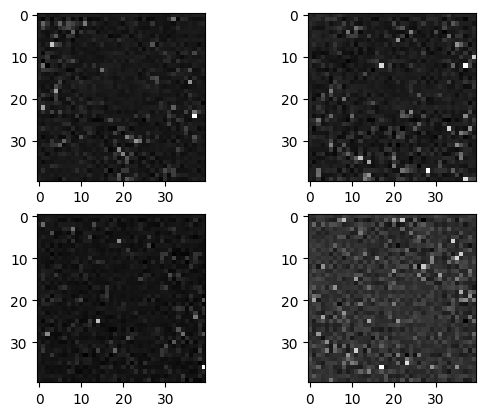

saved on epoch 1550
saved on epoch 1550
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - d_loss: -0.1525 - g_loss: 8.3956
Epoch 1552/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
mean -0.8646883368492126 std 0.058032337576150894
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
prediction [[0.03662331]
 [0.02015892]
 [0.99941385]
 [0.9999366 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.0873 - g_loss: 8.7939
Epoch 1553/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
mean -0.8688348531723022 std 0.051049210131168365
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
prediction [[0.99734455]
 [0.99973387]
 [0.9998703 ]
 [0.9915986 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.2259 - g_loss: 8.6861
Epoch 1554/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
mean -0.8666682243347168 std 0.05351444333791733
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
prediction [[0.99638677]
 [0.99988925]
 [0.9997968 ]
 [0.9982122 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: 0.0293 - g_loss: 8.6824 
Epoch 1555/2000
1/1 ━━━━━━━━━━━

prediction [[0.9996056 ]
 [0.9994985 ]
 [0.9998709 ]
 [0.99917233]]
saved on epoch 1555
saved on epoch 1555
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - d_loss: -0.3470 - g_loss: 7.7310
Epoch 1557/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
mean -0.8663743734359741 std 0.05096385255455971
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
prediction [[0.9686149 ]
 [0.9957516 ]
 [0.9998628 ]
 [0.99991024]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - d_loss: -0.0714 - g_loss: 8.0743
Epoch 1558/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
mean -0.8648862242698669 std 0.049175187945365906
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
prediction [[0.9899302 ]
 [0.9987457 ]
 [0.99994457]
 [0.99764794]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.1571 - g_loss: 7.7287
Epoch 1559/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.867056131362915 std 0.05281901732087135
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
prediction [[0.9993518 ]
 [0.84798425]
 [0.99865353]
 [0.9994318 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step 

prediction [[0.9991829 ]
 [0.88772804]
 [0.9994412 ]
 [0.96086156]]
saved on epoch 1560


saved on epoch 1560
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - d_loss: -0.2524 - g_loss: 8.5736
Epoch 1562/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
mean -0.8658401370048523 std 0.051880959421396255
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
prediction [[0.86956614]
 [0.9983438 ]
 [0.99917126]
 [0.99961025]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - d_loss: -0.0856 - g_loss: 8.4789
Epoch 1563/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
mean -0.8661938309669495 std 0.05378061905503273
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
prediction [[0.6611215 ]
 [0.11655737]
 [0.999926  ]
 [0.99957424]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - d_loss: -0.1899 - g_loss: 8.5706
Epoch 1564/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
mean -0.867354154586792 std 0.04727497696876526
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
prediction [[0.9973193]
 [0.999273 ]
 [0.9991258]
 [0.9993692]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - d_loss: -0.3149 - g_loss: 9.0900
Epoch 1565/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
mea

prediction [[0.33576894]
 [0.9994605 ]
 [0.9997296 ]
 [0.9982608 ]]
saved on epoch 1565


...

prediction [[0.90382403]
 [0.99384683]
 [0.99949694]
 [0.99364257]]
saved on epoch 1585


saved on epoch 1585
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - d_loss: -0.1735 - g_loss: 9.7141
Epoch 1587/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
mean -0.8688766956329346 std 0.04527982696890831
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
prediction [[0.9984237]
 [0.9994555]
 [0.9991491]
 [0.9998896]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - d_loss: -0.2310 - g_loss: 9.3859
Epoch 1588/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
mean -0.8687411546707153 std 0.047863978892564774
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
prediction [[0.76137125]
 [0.9994216 ]
 [0.99992406]
 [0.9996228 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.2224 - g_loss: 9.2728
Epoch 1589/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
mean -0.864942193031311 std 0.05828305706381798
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
prediction [[0.01232048]
 [0.99975854]
 [0.99961746]
 [0.99926347]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - d_loss: -0.3327 - g_loss: 9.7909
Epoch 1590/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
mea

prediction [[0.8092639 ]
 [0.9996043 ]
 [0.99982685]
 [0.9999405 ]]
saved on epoch 1590
saved on epoch 1590
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - d_loss: -0.1380 - g_loss: 9.4644
Epoch 1592/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
mean -0.8650712370872498 std 0.05177118629217148
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
prediction [[0.5336264 ]
 [0.8018588 ]
 [0.99996066]
 [0.9997831 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - d_loss: -0.1432 - g_loss: 9.7648
Epoch 1593/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
mean -0.8637810349464417 std 0.0519678108394146
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
prediction [[0.9893143 ]
 [0.91979253]
 [0.9997967 ]
 [0.99922574]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - d_loss: -0.3699 - g_loss: 9.6454
Epoch 1594/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.8662594556808472 std 0.05442836508154869
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
prediction [[0.9561709]
 [0.9809106]
 [0.9943989]
 [0.9989507]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - d_l

prediction [[0.9900491]
 [0.8286543]
 [0.996718 ]
 [0.9998969]]
saved on epoch 1595


saved on epoch 1595
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: 0.0234 - g_loss: 9.2043 
Epoch 1597/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
mean -0.8669828772544861 std 0.05658460780978203
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
prediction [[0.05638884]
 [0.99987733]
 [0.9996697 ]
 [0.9999323 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.1999 - g_loss: 9.3225
Epoch 1598/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.8666780591011047 std 0.05653093755245209
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
prediction [[0.8644721 ]
 [0.01352855]
 [0.9997521 ]
 [0.9996463 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.3224 - g_loss: 9.1178
Epoch 1599/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
mean -0.8663151264190674 std 0.05256930738687515
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
prediction [[0.98616415]
 [0.9645729 ]
 [0.999696  ]
 [0.9922524 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.1659 - g_loss: 9.0326
Epoch 1600/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

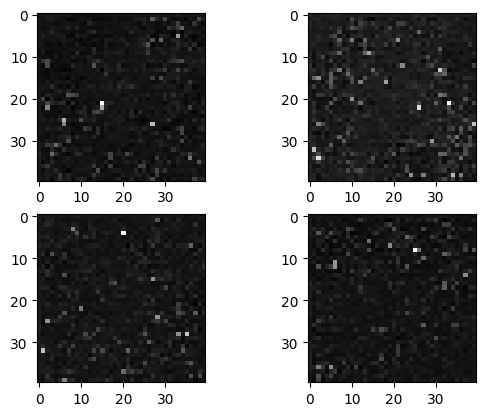

saved on epoch 1600
saved on epoch 1600
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - d_loss: -0.1514 - g_loss: 8.4269
Epoch 1602/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
mean -0.864875316619873 std 0.05391700938344002
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
prediction [[0.07082018]
 [0.9973013 ]
 [0.9999862 ]
 [0.99973875]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - d_loss: -0.1753 - g_loss: 8.0987
Epoch 1603/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
mean -0.8697787523269653 std 0.04665946587920189
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
prediction [[0.9997613 ]
 [0.9988305 ]
 [0.9995407 ]
 [0.99993455]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - d_loss: -0.1900 - g_loss: 7.6945
Epoch 1604/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.8685566782951355 std 0.051809825003147125
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
prediction [[0.99873227]
 [0.99977845]
 [0.99894875]
 [0.9775122 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - d_loss: -0.2623 - g_loss: 7.3134
Epoch 1605/2000
1/1 ━━━━━━━━━━━━━

prediction [[0.9940176]
 [0.9584106]
 [0.9998437]
 [0.9997389]]
saved on epoch 1605


saved on epoch 1605
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - d_loss: -0.2803 - g_loss: 7.9411
Epoch 1607/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
mean -0.8651266694068909 std 0.05684620887041092
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
prediction [[0.03358572]
 [0.7403556 ]
 [0.99867755]
 [0.9998753 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.1116 - g_loss: 8.5031
Epoch 1608/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.8667299151420593 std 0.05113644897937775
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
prediction [[0.9971    ]
 [0.06184243]
 [0.999995  ]
 [0.9993741 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.3907 - g_loss: 8.4822
Epoch 1609/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.862409234046936 std 0.06066922843456268
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
prediction [[0.1573362 ]
 [0.9927005 ]
 [0.99312603]
 [0.99986386]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.1417 - g_loss: 8.4853
Epoch 1610/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


prediction [[0.9862185 ]
 [0.12240656]
 [0.99988735]
 [0.99990237]]
saved on epoch 1610
saved on epoch 1610
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - d_loss: -0.0454 - g_loss: 7.8859
Epoch 1612/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
mean -0.8669206500053406 std 0.05077299103140831
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
prediction [[0.9980338 ]
 [0.9954    ]
 [0.9999304 ]
 [0.99928147]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - d_loss: -0.2847 - g_loss: 8.1855
Epoch 1613/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
mean -0.8669626116752625 std 0.05412374064326286
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
prediction [[0.9790278]
 [0.7964229]
 [0.9998485]
 [0.9993554]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - d_loss: -0.3043 - g_loss: 8.1728
Epoch 1614/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
mean -0.866960346698761 std 0.04487816244363785
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
prediction [[0.99981135]
 [0.9936488 ]
 [0.99914014]
 [0.99938667]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_l

prediction [[0.85917586]
 [0.9996269 ]
 [0.9998305 ]
 [0.999401  ]]
saved on epoch 1615
saved on epoch 1615
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - d_loss: -0.1871 - g_loss: 8.2542
Epoch 1617/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.865540623664856 std 0.057336654514074326
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
prediction [[0.35122055]
 [0.9909704 ]
 [0.96347094]
 [0.9999038 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - d_loss: -0.2596 - g_loss: 8.2531
Epoch 1618/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
mean -0.8656879663467407 std 0.057380106300115585
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
prediction [[0.9680944]
 [0.9959292]
 [0.999491 ]
 [0.9990607]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.0253 - g_loss: 9.0556
Epoch 1619/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.8665342926979065 std 0.054658062756061554
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
prediction [[0.29363254]
 [0.9990798 ]
 [0.9999695 ]
 [0.9997099 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - 

...

prediction [[0.99622333]
 [0.11470184]
 [0.9985629 ]
 [0.999613  ]]
saved on epoch 1635


saved on epoch 1635
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - d_loss: -0.2398 - g_loss: 8.3534
Epoch 1637/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.8660240173339844 std 0.050297483801841736
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
prediction [[0.78843176]
 [0.99736327]
 [0.9999809 ]
 [0.99993753]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.2041 - g_loss: 8.0933
Epoch 1638/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.8684869408607483 std 0.04967839643359184
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
prediction [[0.9794718 ]
 [0.99972886]
 [0.9994898 ]
 [0.9999049 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.3163 - g_loss: 8.3128
Epoch 1639/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.8652657866477966 std 0.05604550987482071
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
prediction [[0.06544683]
 [0.6695127 ]
 [0.999858  ]
 [0.9996481 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.2136 - g_loss: 8.7381
Epoch 1640/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/ste

prediction [[0.9994752 ]
 [0.9692011 ]
 [0.99979645]
 [0.9996896 ]]
saved on epoch 1640
saved on epoch 1640
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - d_loss: -0.2302 - g_loss: 9.1289
Epoch 1642/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
mean -0.8636330962181091 std 0.05320776626467705
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
prediction [[0.07201254]
 [0.9595388 ]
 [0.9858608 ]
 [0.9994342 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.1071 - g_loss: 8.9549
Epoch 1643/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
mean -0.8653430342674255 std 0.057102661579847336
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
prediction [[0.9906076]
 [0.0417699]
 [0.9995677]
 [0.9950216]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - d_loss: -0.2202 - g_loss: 8.8737
Epoch 1644/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
mean -0.8672712445259094 std 0.04920797795057297
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
prediction [[0.9903626]
 [0.996938 ]
 [0.9998559]
 [0.999723 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - d_los

prediction [[0.00211295]
 [0.99635506]
 [0.9999738 ]
 [0.9999385 ]]
saved on epoch 1645


saved on epoch 1645
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - d_loss: -0.0887 - g_loss: 8.6659
Epoch 1647/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8651831746101379 std 0.05714285001158714
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
prediction [[0.9991736]
 [0.9984646]
 [0.9997185]
 [0.9998921]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.0740 - g_loss: 9.1279
Epoch 1648/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.8675393462181091 std 0.052125778049230576
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.99855524]
 [0.97999334]
 [0.99986315]
 [0.9997023 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.2156 - g_loss: 9.1305
Epoch 1649/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
mean -0.8649283647537231 std 0.059813935309648514
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
prediction [[0.99875116]
 [0.75144786]
 [0.9999764 ]
 [0.99957484]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.3218 - g_loss: 9.3999
Epoch 1650/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
m

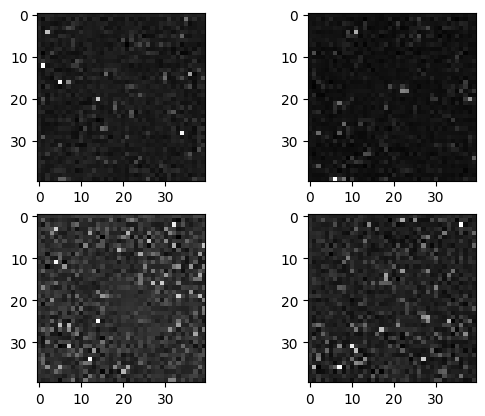

saved on epoch 1650
saved on epoch 1650
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - d_loss: -0.1304 - g_loss: 9.0627
Epoch 1652/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
mean -0.8645415306091309 std 0.052318599075078964
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
prediction [[0.74463946]
 [0.9941373 ]
 [0.6858065 ]
 [0.9989385 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - d_loss: -0.2754 - g_loss: 8.9819
Epoch 1653/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
mean -0.8631598949432373 std 0.05456915497779846
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
prediction [[0.9656465 ]
 [0.57102793]
 [0.99987435]
 [0.99457055]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.2421 - g_loss: 9.4306
Epoch 1654/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
mean -0.8664774298667908 std 0.05003545805811882
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
prediction [[0.9995542 ]
 [0.99557185]
 [0.9995933 ]
 [0.99996185]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - d_loss: -0.2595 - g_loss: 9.1607
Epoch 1655/2000
1/1 ━━━━━━━━━━━━

prediction [[0.00410139]
 [0.20371826]
 [0.99967444]
 [0.9995882 ]]
saved on epoch 1655


saved on epoch 1655
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.2053 - g_loss: 9.6552
Epoch 1657/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.8683908581733704 std 0.04509887099266052
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
prediction [[0.9995658 ]
 [0.99787223]
 [0.99965966]
 [0.9995384 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.2542 - g_loss: 10.5074
Epoch 1658/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.866982102394104 std 0.05651810020208359
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
prediction [[0.2973554 ]
 [0.9981622 ]
 [0.99993503]
 [0.99969876]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.1292 - g_loss: 10.2024
Epoch 1659/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
mean -0.8672733902931213 std 0.05278090387582779
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
prediction [[0.99878997]
 [0.0282997 ]
 [0.9998739 ]
 [0.9989191 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.3339 - g_loss: 10.4184
Epoch 1660/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/st

prediction [[0.9406628 ]
 [0.95167804]
 [0.99989974]
 [0.999049  ]]
saved on epoch 1660


saved on epoch 1660
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - d_loss: -0.1926 - g_loss: 10.4725
Epoch 1662/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
mean -0.8669313192367554 std 0.04916679859161377
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
prediction [[0.9970433 ]
 [0.99871457]
 [0.9999616 ]
 [0.9994042 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - d_loss: -0.0916 - g_loss: 10.2923
Epoch 1663/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
mean -0.8674315810203552 std 0.04484035074710846
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.7953155 ]
 [0.99767834]
 [0.99974364]
 [0.9997688 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.0529 - g_loss: 10.4990
Epoch 1664/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
mean -0.8666965961456299 std 0.053044579923152924
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
prediction [[0.9994735 ]
 [0.9995567 ]
 [0.99998844]
 [0.9999013 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.2167 - g_loss: 10.4298
Epoch 1665/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms

...

saved on epoch 1680
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - d_loss: -0.2188 - g_loss: 9.5262
Epoch 1682/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
mean -0.8665617108345032 std 0.05735219269990921
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
prediction [[0.97943234]
 [0.35841504]
 [0.99992275]
 [0.9997919 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - d_loss: -0.1875 - g_loss: 9.0876
Epoch 1683/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
mean -0.8657485842704773 std 0.06010514125227928
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
prediction [[0.06534177]
 [0.98061335]
 [0.99489164]
 [0.9961861 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.2300 - g_loss: 9.0925
Epoch 1684/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
mean -0.8680287003517151 std 0.047049038112163544
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
prediction [[0.96353334]
 [0.829784  ]
 [0.9997999 ]
 [0.9980813 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.1885 - g_loss: 9.1820
Epoch 1685/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/ste

prediction [[0.9999436 ]
 [0.02198475]
 [0.99879277]
 [0.9998739 ]]
saved on epoch 1685
saved on epoch 1685
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - d_loss: -0.1864 - g_loss: 9.1158
Epoch 1687/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
mean -0.8669926524162292 std 0.054536085575819016
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
prediction [[0.99980944]
 [0.3434645 ]
 [0.9998516 ]
 [0.9992848 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.2531 - g_loss: 9.5790
Epoch 1688/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
mean -0.8681496977806091 std 0.04833656921982765
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
prediction [[0.9886883 ]
 [0.99897015]
 [0.9997627 ]
 [0.9996735 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.1504 - g_loss: 9.2966
Epoch 1689/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.8655033707618713 std 0.05192995071411133
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
prediction [[0.07699523]
 [0.9975044 ]
 [0.9992786 ]
 [0.9998895 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step

prediction [[0.9966877 ]
 [0.99950254]
 [0.99984777]
 [0.99984145]]
saved on epoch 1690


saved on epoch 1690
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.1334 - g_loss: 9.6002
Epoch 1692/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8669334650039673 std 0.059213340282440186
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
prediction [[0.85235494]
 [0.63493097]
 [0.99979264]
 [0.983979  ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - d_loss: -0.1746 - g_loss: 9.7929
Epoch 1693/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
mean -0.8638368248939514 std 0.05752018094062805
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
prediction [[0.23014584]
 [0.81421256]
 [0.9999627 ]
 [0.99925214]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - d_loss: -0.3906 - g_loss: 9.8121
Epoch 1694/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
mean -0.8665079474449158 std 0.053978580981492996
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
prediction [[0.9849187 ]
 [0.9799452 ]
 [0.99991643]
 [0.99995136]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - d_loss: -0.2288 - g_loss: 9.5855
Epoch 1695/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/st

prediction [[0.04641087]
 [0.9993119 ]
 [0.99962366]
 [0.9999348 ]]
saved on epoch 1695
saved on epoch 1695
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - d_loss: -0.0822 - g_loss: 9.8342
Epoch 1697/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8660550117492676 std 0.05076088011264801
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.99518126]
 [0.0079993 ]
 [0.9976799 ]
 [0.9887394 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.1136 - g_loss: 9.7935
Epoch 1698/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
mean -0.8669520616531372 std 0.06364011764526367
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.9237973 ]
 [0.58152246]
 [0.9997652 ]
 [0.99996126]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2684 - g_loss: 10.0606
Epoch 1699/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8652606010437012 std 0.05055529996752739
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
prediction [[0.00721789]
 [0.33761787]
 [0.99988997]
 [0.99970514]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step

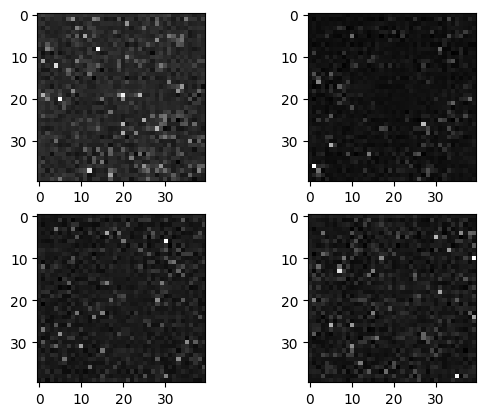

saved on epoch 1700
saved on epoch 1700
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - d_loss: -0.1063 - g_loss: 9.6128
Epoch 1702/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
mean -0.8651064038276672 std 0.055690016597509384
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
prediction [[0.96777076]
 [0.9183907 ]
 [0.99972445]
 [0.9998196 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.2820 - g_loss: 9.5566
Epoch 1703/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
mean -0.8657211065292358 std 0.05408584699034691
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
prediction [[0.3158815 ]
 [0.10460791]
 [0.99982953]
 [0.9999186 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - d_loss: -0.1932 - g_loss: 9.9095
Epoch 1704/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
mean -0.8683300614356995 std 0.04913417622447014
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
prediction [[0.9974369 ]
 [0.24710158]
 [0.99935335]
 [0.99997294]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.0499 - g_loss: 9.6846
Epoch 1705/2000
1/1 ━━━━━━━━━━━━

prediction [[0.84502894]
 [0.9998017 ]
 [0.9997389 ]
 [0.99957734]]
saved on epoch 1705


saved on epoch 1705
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - d_loss: -0.2076 - g_loss: 10.0748
Epoch 1707/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
mean -0.8663368821144104 std 0.052583325654268265
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.8195861 ]
 [0.7145658 ]
 [0.99017453]
 [0.99029046]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.1931 - g_loss: 10.1795
Epoch 1708/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8663087487220764 std 0.049340203404426575
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.99702436]
 [0.9970005 ]
 [0.9997453 ]
 [0.999887  ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.2848 - g_loss: 10.1524
Epoch 1709/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
mean -0.8682565093040466 std 0.04856426641345024
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
prediction [[0.99953055]
 [0.8598763 ]
 [0.9992568 ]
 [0.99981207]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.4024 - g_loss: 10.0997
Epoch 1710/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19m

prediction [[0.01502513]
 [0.00426749]
 [0.9998392 ]
 [0.9998797 ]]
saved on epoch 1710


saved on epoch 1710
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.0399 - g_loss: 9.7519
Epoch 1712/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8647782206535339 std 0.058555833995342255
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
prediction [[0.07427359]
 [0.01380553]
 [0.985824  ]
 [0.9996724 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.1962 - g_loss: 9.7852
Epoch 1713/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
mean -0.8653834462165833 std 0.05878444015979767
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
prediction [[0.9950622 ]
 [0.4634464 ]
 [0.99263096]
 [0.9969977 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - d_loss: -0.2542 - g_loss: 9.5761
Epoch 1714/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
mean -0.866935670375824 std 0.05104054510593414
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
prediction [[0.0440465 ]
 [0.99967754]
 [0.9996909 ]
 [0.99980885]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - d_loss: -0.1842 - g_loss: 9.9407
Epoch 1715/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step

...

saved on epoch 1735
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - d_loss: -0.1724 - g_loss: 9.3652
Epoch 1737/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8694924712181091 std 0.04779033362865448
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
prediction [[0.9900377 ]
 [0.9721629 ]
 [0.99977094]
 [0.99977916]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - d_loss: -0.2838 - g_loss: 9.6811
Epoch 1738/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8668714761734009 std 0.046497903764247894
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
prediction [[0.6981139 ]
 [0.96163166]
 [0.9998292 ]
 [0.9996012 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2775 - g_loss: 9.5248
Epoch 1739/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8690701127052307 std 0.047229256480932236
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
prediction [[0.4947001 ]
 [0.9962529 ]
 [0.9995511 ]
 [0.99939907]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.1603 - g_loss: 9.2911
Epoch 1740/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/st

prediction [[0.9420309]
 [0.9676747]
 [0.9986185]
 [0.9997017]]
saved on epoch 1740


saved on epoch 1740
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - d_loss: -0.2705 - g_loss: 9.2283
Epoch 1742/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
mean -0.8654024004936218 std 0.06250585615634918
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
prediction [[0.13186817]
 [0.7010997 ]
 [0.9999093 ]
 [0.988929  ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - d_loss: -0.0701 - g_loss: 9.4878
Epoch 1743/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
mean -0.866199254989624 std 0.05534498021006584
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
prediction [[0.67254   ]
 [0.38364318]
 [0.9998696 ]
 [0.9999199 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - d_loss: -0.1522 - g_loss: 9.7123
Epoch 1744/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
mean -0.867255687713623 std 0.054002951830625534
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
prediction [[0.70198894]
 [0.99685526]
 [0.99989927]
 [0.9996537 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.3506 - g_loss: 9.9189
Epoch 1745/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


prediction [[0.99917406]
 [0.9729528 ]
 [0.99355716]
 [0.9964695 ]]
saved on epoch 1745


saved on epoch 1745
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - d_loss: -0.1779 - g_loss: 9.4381
Epoch 1747/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8664553761482239 std 0.05485934764146805
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
prediction [[0.9986292 ]
 [0.07895318]
 [0.999816  ]
 [0.99655724]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - d_loss: -0.1589 - g_loss: 9.5572
Epoch 1748/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
mean -0.8696550726890564 std 0.04516524448990822
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
prediction [[0.9895308]
 [0.9991308]
 [0.9998319]
 [0.99936  ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - d_loss: -0.2583 - g_loss: 9.4516
Epoch 1749/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
mean -0.8661102056503296 std 0.0525822676718235
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
prediction [[0.83596534]
 [0.27876022]
 [0.85932916]
 [0.99798894]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - d_loss: -0.1037 - g_loss: 9.6642
Epoch 1750/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
mean

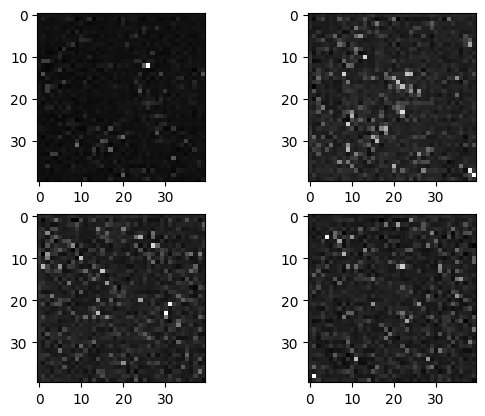

saved on epoch 1750
saved on epoch 1750
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - d_loss: -0.2090 - g_loss: 9.6110
Epoch 1752/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
mean -0.8644238114356995 std 0.049682315438985825
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
prediction [[0.38388187]
 [0.9182032 ]
 [0.9989317 ]
 [0.99084735]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - d_loss: -0.1281 - g_loss: 9.6534
Epoch 1753/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
mean -0.8672938346862793 std 0.04830530285835266
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
prediction [[0.9958425 ]
 [0.99967206]
 [0.99965787]
 [0.9940544 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.2825 - g_loss: 10.2833
Epoch 1754/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.86598801612854 std 0.05550435557961464
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
prediction [[0.9974254]
 [0.9698901]
 [0.9999294]
 [0.9987519]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.1376 - g_loss: 10.3873
Epoch 1755/2000
1/1 ━━━━━━━━━━━━━━━━

prediction [[0.8753945 ]
 [0.8849089 ]
 [0.99987817]
 [0.99986017]]
saved on epoch 1755


saved on epoch 1755
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.2985 - g_loss: 10.1976
Epoch 1757/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8663766384124756 std 0.04700114578008652
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
prediction [[0.40294686]
 [0.9934378 ]
 [0.9982387 ]
 [0.99118376]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.2843 - g_loss: 9.9474
Epoch 1758/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8699918985366821 std 0.04637489095330238
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.9983866 ]
 [0.39136288]
 [0.9993973 ]
 [0.9999845 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.1170 - g_loss: 9.9448 
Epoch 1759/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
mean -0.8678744435310364 std 0.05215064436197281
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
prediction [[0.34156182]
 [0.2984245 ]
 [0.9996573 ]
 [0.99987733]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.0894 - g_loss: 9.5680
Epoch 1760/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/st

prediction [[0.9998099 ]
 [0.9930642 ]
 [0.99977845]
 [0.99992216]]
saved on epoch 1760


saved on epoch 1760
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - d_loss: -0.1772 - g_loss: 9.6144
Epoch 1762/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8668104410171509 std 0.05364320054650307
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
prediction [[0.9902208 ]
 [0.8038698 ]
 [0.9988268 ]
 [0.99968684]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.1632 - g_loss: 9.5200
Epoch 1763/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8685623407363892 std 0.05196603387594223
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.7281693 ]
 [0.99785453]
 [0.9997576 ]
 [0.99952114]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.4476 - g_loss: 9.9051
Epoch 1764/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8670187592506409 std 0.04583447799086571
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
prediction [[0.2336203 ]
 [0.0769188 ]
 [0.99925786]
 [0.9990765 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_loss: -0.2206 - g_loss: 10.3895
Epoch 1765/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/ste

...

saved on epoch 1785
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - d_loss: -0.1999 - g_loss: 9.9389
Epoch 1787/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8672491312026978 std 0.04876469820737839
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
prediction [[0.9960167 ]
 [0.426752  ]
 [0.99541736]
 [0.999887  ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.3932 - g_loss: 9.6717
Epoch 1788/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
mean -0.8665457367897034 std 0.052999258041381836
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
prediction [[0.59885794]
 [0.92144483]
 [0.98815084]
 [0.99898213]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - d_loss: -0.1854 - g_loss: 9.3355
Epoch 1789/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
mean -0.8673637509346008 std 0.04842720553278923
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
prediction [[0.9966589 ]
 [0.99940455]
 [0.9975297 ]
 [0.9991749 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - d_loss: -0.1323 - g_loss: 9.4826
Epoch 1790/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/ste

prediction [[0.13430762]
 [0.99763775]
 [0.999089  ]
 [0.99717206]]
saved on epoch 1790


saved on epoch 1790
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - d_loss: -0.1355 - g_loss: 9.7475
Epoch 1792/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8663994669914246 std 0.055665455758571625
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
prediction [[0.24695987]
 [0.9525085 ]
 [0.9998698 ]
 [0.9994236 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - d_loss: -0.1863 - g_loss: 9.8506
Epoch 1793/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
mean -0.8675166368484497 std 0.054944414645433426
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
prediction [[0.35473233]
 [0.9988606 ]
 [0.99982506]
 [0.9992611 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.0703 - g_loss: 9.7260
Epoch 1794/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
mean -0.8689237236976624 std 0.049110282212495804
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.9979327 ]
 [0.99636924]
 [0.9997309 ]
 [0.98443305]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.1735 - g_loss: 9.3588
Epoch 1795/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/s

prediction [[0.9910584 ]
 [0.60386384]
 [0.9996271 ]
 [0.9961952 ]]
saved on epoch 1795


saved on epoch 1795
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - d_loss: -0.1616 - g_loss: 9.2932
Epoch 1797/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
mean -0.8675049543380737 std 0.05254542827606201
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
prediction [[0.02351772]
 [0.9986615 ]
 [0.9943104 ]
 [0.9852675 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - d_loss: -0.1957 - g_loss: 9.4901
Epoch 1798/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
mean -0.867659330368042 std 0.05424913763999939
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
prediction [[0.55305004]
 [0.08941738]
 [0.9994326 ]
 [0.9981294 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - d_loss: -0.1221 - g_loss: 9.4716
Epoch 1799/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
mean -0.8662583231925964 std 0.05582907795906067
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
prediction [[0.9809925 ]
 [0.9948318 ]
 [0.9993874 ]
 [0.99982774]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - d_loss: -0.0307 - g_loss: 9.6027
Epoch 1800/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


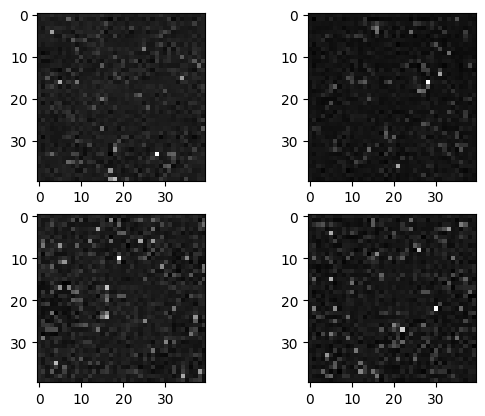

saved on epoch 1800
saved on epoch 1800
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - d_loss: -0.1418 - g_loss: 9.5297
Epoch 1802/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.865976095199585 std 0.061612263321876526
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
prediction [[0.99905115]
 [0.00887076]
 [0.9996264 ]
 [0.99988246]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - d_loss: -0.1813 - g_loss: 9.0509
Epoch 1803/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8658972978591919 std 0.05732179433107376
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
prediction [[0.508256  ]
 [0.72629875]
 [0.99960476]
 [0.9990344 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.1639 - g_loss: 8.8460
Epoch 1804/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.8656684756278992 std 0.0576479509472847
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
prediction [[0.00232851]
 [0.02307874]
 [0.98667705]
 [0.9984603 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.2816 - g_loss: 8.9516
Epoch 1805/2000
1/1 ━━━━━━━━━━━━━━

prediction [[0.98504573]
 [0.997865  ]
 [0.999933  ]
 [0.99984765]]
saved on epoch 1805


saved on epoch 1805
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - d_loss: -0.2199 - g_loss: 8.5233
Epoch 1807/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
mean -0.8684934973716736 std 0.05146606266498566
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
prediction [[0.992342 ]
 [0.9988055]
 [0.9999676]
 [0.9985127]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - d_loss: -0.1633 - g_loss: 9.0068
Epoch 1808/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8659335374832153 std 0.05664612352848053
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.98992294]
 [0.9984956 ]
 [0.98806584]
 [0.9997937 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - d_loss: -0.1919 - g_loss: 8.4918
Epoch 1809/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8664024472236633 std 0.053491901606321335
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.86467063]
 [0.71237946]
 [0.9994837 ]
 [0.9985669 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.1432 - g_loss: 8.5996
Epoch 1810/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
me

prediction [[0.0741187 ]
 [0.26237074]
 [0.9955433 ]
 [0.99972504]]
saved on epoch 1810
saved on epoch 1810
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - d_loss: -0.2027 - g_loss: 8.3824
Epoch 1812/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8660728335380554 std 0.05551914870738983
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
prediction [[0.9833565 ]
 [0.04523182]
 [0.97279686]
 [0.99959964]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - d_loss: -0.1804 - g_loss: 8.5056
Epoch 1813/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.866320788860321 std 0.05116795003414154
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
prediction [[0.98352355]
 [0.51124674]
 [0.9999118 ]
 [0.9996476 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.1997 - g_loss: 8.4352
Epoch 1814/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
mean -0.8660852313041687 std 0.05749417096376419
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
prediction [[0.3263557 ]
 [0.95319295]
 [0.99968696]
 [0.9952787 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step -

prediction [[0.01498023]
 [0.63836014]
 [0.98807037]
 [0.9999398 ]]
saved on epoch 1815
saved on epoch 1815
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - d_loss: -0.1636 - g_loss: 8.0686
Epoch 1817/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.8675963878631592 std 0.050618767738342285
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
prediction [[0.35017553]
 [0.98337793]
 [0.9998431 ]
 [0.99843603]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - d_loss: -0.2482 - g_loss: 8.3683
Epoch 1818/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
mean -0.8659288287162781 std 0.05496077612042427
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
prediction [[9.9681516e-04]
 [9.8651719e-01]
 [9.9975854e-01]
 [9.9995637e-01]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.2978 - g_loss: 8.2628
Epoch 1819/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
mean -0.8687187433242798 std 0.052973177284002304
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
prediction [[0.61173266]
 [0.99952435]
 [0.99790037]
 [0.99754673]]
38/38 ━━━━━━━━━━━━━━━━━━━━

...

saved on epoch 1835
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - d_loss: -0.3375 - g_loss: 8.0175
Epoch 1837/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
mean -0.8643110394477844 std 0.04956137016415596
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
prediction [[0.7836355 ]
 [0.00818056]
 [0.9958192 ]
 [0.9983974 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - d_loss: -0.1182 - g_loss: 8.1115
Epoch 1838/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mean -0.8653062582015991 std 0.051367100328207016
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
prediction [[0.12850803]
 [0.1656537 ]
 [0.99915755]
 [0.9995055 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.2889 - g_loss: 7.9639
Epoch 1839/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
mean -0.8653764128684998 std 0.05231533944606781
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
prediction [[0.09841874]
 [0.78500694]
 [0.07023472]
 [0.9985285 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: 0.0409 - g_loss: 8.0166 
Epoch 1840/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/ste

prediction [[0.0371664 ]
 [0.97624207]
 [0.9997764 ]
 [0.9973556 ]]
saved on epoch 1840


saved on epoch 1840
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - d_loss: -0.2556 - g_loss: 7.6908
Epoch 1842/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
mean -0.8657158017158508 std 0.055875103920698166
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
prediction [[0.9980842 ]
 [0.97780675]
 [0.9751101 ]
 [0.9997241 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - d_loss: -0.3224 - g_loss: 7.7556
Epoch 1843/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
mean -0.8663679361343384 std 0.05505138263106346
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
prediction [[0.9754479 ]
 [0.9571487 ]
 [0.9753593 ]
 [0.99965394]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - d_loss: -0.4445 - g_loss: 8.1775
Epoch 1844/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
mean -0.8620637655258179 std 0.06226973608136177
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
prediction [[0.00944188]
 [0.89367205]
 [0.9995795 ]
 [0.99994993]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - d_loss: -0.0246 - g_loss: 8.4629
Epoch 1845/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/ste

prediction [[0.7463939 ]
 [0.5499401 ]
 [0.9996811 ]
 [0.99989235]]
saved on epoch 1845


saved on epoch 1845
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - d_loss: -0.1567 - g_loss: 7.6675
Epoch 1847/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
mean -0.8684664964675903 std 0.04791407659649849
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
prediction [[0.99842536]
 [0.50935704]
 [0.9999615 ]
 [0.99924564]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.2117 - g_loss: 7.6916
Epoch 1848/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
mean -0.8658319711685181 std 0.05167007073760033
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
prediction [[0.9018067]
 [0.9655213]
 [0.998809 ]
 [0.9874396]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.1265 - g_loss: 7.5160
Epoch 1849/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
mean -0.866274893283844 std 0.052944619208574295
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.9985903 ]
 [0.8061233 ]
 [0.51161987]
 [0.99946743]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.2922 - g_loss: 7.2607
Epoch 1850/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
mea

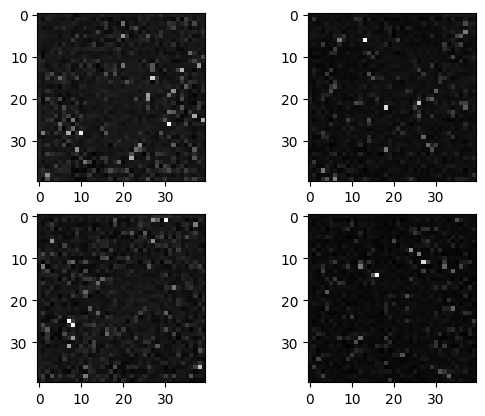

saved on epoch 1850
saved on epoch 1850
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - d_loss: -0.0733 - g_loss: 7.5812
Epoch 1852/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
mean -0.8673449158668518 std 0.05574800819158554
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
prediction [[0.3271111 ]
 [0.86351377]
 [0.99999034]
 [0.9992113 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.0855 - g_loss: 7.2362
Epoch 1853/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
mean -0.8677709102630615 std 0.05554609000682831
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[1.5770641e-04]
 [1.8788589e-02]
 [9.9981242e-01]
 [9.9961686e-01]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.3965 - g_loss: 7.1060
Epoch 1854/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
mean -0.8663915991783142 std 0.05221400782465935
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
prediction [[0.24849999]
 [0.64717144]
 [0.9996668 ]
 [0.99934274]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - d_loss: -0.1734 - g_loss: 7.6718
Epoch 1855/2000
1/1 ━

prediction [[0.9743798 ]
 [0.59343386]
 [0.9997261 ]
 [0.99958295]]
saved on epoch 1855


saved on epoch 1855
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - d_loss: -0.1344 - g_loss: 8.0991
Epoch 1857/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
mean -0.8655152916908264 std 0.05515408515930176
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.8508471 ]
 [0.9753039 ]
 [0.9996917 ]
 [0.99858665]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.1425 - g_loss: 7.7507
Epoch 1858/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
mean -0.8659994602203369 std 0.06275114417076111
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
prediction [[0.02280319]
 [0.3790046 ]
 [0.9996031 ]
 [0.99221367]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.2339 - g_loss: 7.8063
Epoch 1859/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
mean -0.8646181225776672 std 0.06496328860521317
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.9766465 ]
 [0.00169344]
 [0.9995784 ]
 [0.98090494]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.2649 - g_loss: 8.4524
Epoch 1860/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step

prediction [[0.92437685]
 [0.9769389 ]
 [0.9802343 ]
 [0.99867404]]
saved on epoch 1860


saved on epoch 1860
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - d_loss: -0.2222 - g_loss: 8.0328
Epoch 1862/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
mean -0.8661008477210999 std 0.05337253212928772
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
prediction [[0.17929925]
 [0.89784884]
 [0.9748326 ]
 [0.99969065]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.1000 - g_loss: 8.1278
Epoch 1863/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
mean -0.8674127459526062 std 0.05287456884980202
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
prediction [[0.9988279 ]
 [0.1448522 ]
 [0.999974  ]
 [0.99987733]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - d_loss: -0.3837 - g_loss: 8.0509
Epoch 1864/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
mean -0.8683522939682007 std 0.0469779446721077
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
prediction [[0.7259799 ]
 [0.963729  ]
 [0.9992292 ]
 [0.99967086]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.0715 - g_loss: 7.7567
Epoch 1865/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


...

prediction [[0.9875442]
 [0.6962744]
 [0.9985562]
 [0.9997682]]
saved on epoch 1885
saved on epoch 1885
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - d_loss: -0.1909 - g_loss: 8.2713
Epoch 1887/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
mean -0.866783082485199 std 0.054790474474430084
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
prediction [[0.8856109 ]
 [0.91809475]
 [0.99944144]
 [0.35933673]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.3357 - g_loss: 8.4327
Epoch 1888/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
mean -0.8678336143493652 std 0.05029413849115372
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.00930088]
 [0.9954964 ]
 [0.9995478 ]
 [0.9992544 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.3342 - g_loss: 8.4720
Epoch 1889/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
mean -0.862751305103302 std 0.061448100954294205
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
prediction [[0.8621122 ]
 [0.99100715]
 [0.9975485 ]
 [0.9997478 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - d_

prediction [[0.02460703]
 [0.99588686]
 [0.9986513 ]
 [0.9992945 ]]
saved on epoch 1890


saved on epoch 1890
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - d_loss: -0.2340 - g_loss: 8.3211
Epoch 1892/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
mean -0.866474986076355 std 0.05535981431603432
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
prediction [[0.12988365]
 [0.5652643 ]
 [0.99970466]
 [0.9998914 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - d_loss: -0.1896 - g_loss: 8.2023
Epoch 1893/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
mean -0.8681633472442627 std 0.046470239758491516
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
prediction [[0.88040674]
 [0.997866  ]
 [0.9952258 ]
 [0.9999068 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - d_loss: -0.2805 - g_loss: 7.6388
Epoch 1894/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
mean -0.8637048602104187 std 0.05214441567659378
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
prediction [[0.860763  ]
 [0.00244428]
 [0.9954464 ]
 [0.9888058 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.1017 - g_loss: 7.7237
Epoch 1895/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

prediction [[0.04458002]
 [0.9915821 ]
 [0.99357116]
 [0.9997975 ]]
saved on epoch 1895


saved on epoch 1895
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - d_loss: -0.1289 - g_loss: 7.4418
Epoch 1897/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
mean -0.8655540943145752 std 0.056963495910167694
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[1.03995626e-04]
 [9.87002254e-01]
 [9.68104720e-01]
 [9.77172434e-01]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.3899 - g_loss: 7.5831
Epoch 1898/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
mean -0.8682140111923218 std 0.04901909455657005
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
prediction [[0.4757611 ]
 [0.21171589]
 [0.99991393]
 [0.9996295 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.1721 - g_loss: 7.7240
Epoch 1899/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
mean -0.8675040602684021 std 0.04927998408675194
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
prediction [[0.9769548 ]
 [0.50061893]
 [0.9993352 ]
 [0.99989915]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.2289 - g_loss: 7.9278
Epoch 1900/2000
1/1 ━━━━━━━━━━━━━━━━

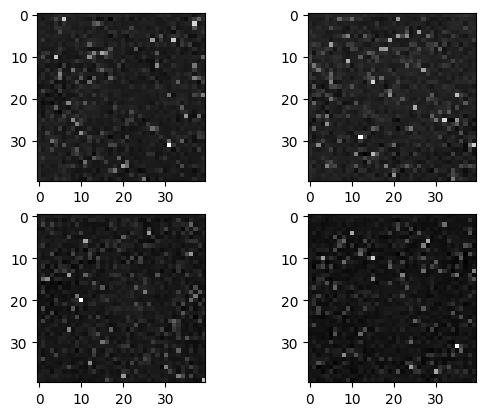

saved on epoch 1900
saved on epoch 1900
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - d_loss: -0.2684 - g_loss: 8.4766
Epoch 1902/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
mean -0.8683611154556274 std 0.051231879740953445
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
prediction [[0.9909368]
 [0.1542012]
 [0.9942035]
 [0.999411 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - d_loss: -0.2706 - g_loss: 8.2760
Epoch 1903/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
mean -0.868338406085968 std 0.052699245512485504
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
prediction [[0.8262118 ]
 [0.99594504]
 [0.9997774 ]
 [0.9989372 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - d_loss: -0.1936 - g_loss: 8.8809
Epoch 1904/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
mean -0.8655284643173218 std 0.054557882249355316
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
prediction [[0.01666638]
 [0.3382478 ]
 [0.9911238 ]
 [0.99987614]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - d_loss: -0.3880 - g_loss: 8.8161
Epoch 1905/2000
1/1 ━━━━━━━━━━━━━━━

prediction [[0.9953556 ]
 [0.05425494]
 [0.9990484 ]
 [0.996271  ]]
saved on epoch 1905


saved on epoch 1905
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - d_loss: 0.0164 - g_loss: 9.0244 
Epoch 1907/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
mean -0.8659787774085999 std 0.054113056510686874
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
prediction [[0.15837078]
 [0.04312413]
 [0.9860319 ]
 [0.9997825 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.0998 - g_loss: 9.0887
Epoch 1908/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
mean -0.8671910166740417 std 0.055681806057691574
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
prediction [[0.88658494]
 [0.99421895]
 [0.9998385 ]
 [0.9998399 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.0707 - g_loss: 9.0581
Epoch 1909/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
mean -0.8652155995368958 std 0.05557931959629059
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
prediction [[0.7580553 ]
 [0.01049867]
 [0.99826545]
 [0.99986637]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.2087 - g_loss: 8.9156
Epoch 1910/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/st

prediction [[0.14281611]
 [0.9734909 ]
 [0.9972402 ]
 [0.99996793]]
saved on epoch 1910


saved on epoch 1910
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - d_loss: -0.2998 - g_loss: 9.0054
Epoch 1912/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
mean -0.8659986853599548 std 0.052927542477846146
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
prediction [[0.92274547]
 [0.0017549 ]
 [0.02928083]
 [0.999041  ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.1793 - g_loss: 8.6923
Epoch 1913/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
mean -0.8650357127189636 std 0.05708533152937889
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
prediction [[0.0077122 ]
 [0.14653213]
 [0.9995858 ]
 [0.9998963 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - d_loss: -0.1008 - g_loss: 8.5045
Epoch 1914/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
mean -0.864432692527771 std 0.059292979538440704
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
prediction [[0.7269045 ]
 [0.23747972]
 [0.13811333]
 [0.986558  ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - d_loss: -0.1439 - g_loss: 8.4775
Epoch 1915/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/ste

...

prediction [[0.00159208]
 [0.858792  ]
 [0.9997874 ]
 [0.9898615 ]]
saved on epoch 1930
saved on epoch 1930
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - d_loss: -0.1855 - g_loss: 9.5938
Epoch 1932/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
mean -0.868519127368927 std 0.05365058407187462
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
prediction [[0.9980464 ]
 [0.9936063 ]
 [0.9992944 ]
 [0.99740714]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - d_loss: 0.0161 - g_loss: 9.3956 
Epoch 1933/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
mean -0.8673626780509949 std 0.05614509806036949
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
prediction [[0.00190508]
 [0.00126017]
 [0.9992126 ]
 [0.99945575]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - d_loss: -0.2093 - g_loss: 9.2731
Epoch 1934/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
mean -0.8664972186088562 std 0.06515392661094666
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
prediction [[0.3202369 ]
 [0.9929558 ]
 [0.99987996]
 [0.97849655]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step -

prediction [[0.4722491 ]
 [0.99584323]
 [0.9968579 ]
 [0.99953854]]
saved on epoch 1935
saved on epoch 1935
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - d_loss: -0.2201 - g_loss: 9.1606
Epoch 1937/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
mean -0.8638482093811035 std 0.05981283634901047
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
prediction [[0.49544352]
 [0.00610933]
 [0.9967019 ]
 [0.99870384]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - d_loss: -0.0239 - g_loss: 9.0961
Epoch 1938/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
mean -0.8684008717536926 std 0.04509830102324486
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
prediction [[0.50598145]
 [0.01509819]
 [0.99546033]
 [0.9995579 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: -0.1151 - g_loss: 8.7075
Epoch 1939/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
mean -0.8669313192367554 std 0.05359634757041931
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
prediction [[0.08580721]
 [0.88349134]
 [0.9989561 ]
 [0.9620687 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step 

prediction [[0.6870272 ]
 [0.06988245]
 [0.9687535 ]
 [0.99993825]]
saved on epoch 1940
saved on epoch 1940
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - d_loss: -0.1267 - g_loss: 8.8141
Epoch 1942/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
mean -0.8674243092536926 std 0.05013202130794525
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
prediction [[0.02290624]
 [0.98303384]
 [0.99672514]
 [0.9999758 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - d_loss: -0.0379 - g_loss: 8.6890
Epoch 1943/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
mean -0.8636295795440674 std 0.05519093573093414
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
prediction [[0.00472618]
 [0.0235636 ]
 [0.9996724 ]
 [0.88636816]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.1151 - g_loss: 8.3973
Epoch 1944/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
mean -0.8656312823295593 std 0.05585252866148949
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
prediction [[0.02325432]
 [0.17921688]
 [0.9998505 ]
 [0.998705  ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step 

prediction [[0.27996066]
 [0.83011883]
 [0.9970861 ]
 [0.99992454]]
saved on epoch 1945


saved on epoch 1945
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - d_loss: -0.1153 - g_loss: 7.6905
Epoch 1947/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
mean -0.866078794002533 std 0.05517713725566864
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
prediction [[0.01416306]
 [0.45871302]
 [0.95784223]
 [0.9996259 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - d_loss: -0.2063 - g_loss: 7.8917
Epoch 1948/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
mean -0.8660615682601929 std 0.057112377136945724
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
prediction [[7.3935377e-04]
 [3.7227142e-01]
 [9.9946874e-01]
 [9.9964118e-01]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: 0.0626 - g_loss: 8.6220 
Epoch 1949/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
mean -0.8650805950164795 std 0.060436464846134186
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
prediction [[0.02632513]
 [0.0117073 ]
 [0.8917444 ]
 [0.97290844]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - d_loss: -0.2152 - g_loss: 8.9766
Epoch 1950/2000
1/1 ━━━━━━━━━━━━━━━━━━━━

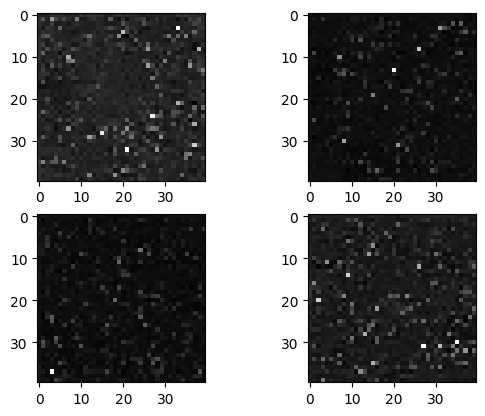

saved on epoch 1950
saved on epoch 1950
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - d_loss: -0.1065 - g_loss: 8.1053
Epoch 1952/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
mean -0.865804135799408 std 0.05479501187801361
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
prediction [[0.05161813]
 [0.98346394]
 [0.99968004]
 [0.99980694]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - d_loss: -0.1307 - g_loss: 8.3270
Epoch 1953/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
mean -0.8662886023521423 std 0.05251900851726532
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
prediction [[0.26622048]
 [0.988736  ]
 [0.96848327]
 [0.98479295]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.1715 - g_loss: 8.3500
Epoch 1954/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
mean -0.8674092292785645 std 0.05330473929643631
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
prediction [[0.02179912]
 [0.00426002]
 [0.9998816 ]
 [0.9998679 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - d_loss: -0.2139 - g_loss: 8.2517
Epoch 1955/2000
1/1 ━━━━━━━━━━━━━━

prediction [[0.00100869]
 [0.33531705]
 [0.8235971 ]
 [0.99989724]]
saved on epoch 1955
saved on epoch 1955
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - d_loss: -0.3480 - g_loss: 8.5812
Epoch 1957/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
mean -0.8678504824638367 std 0.053353291004896164
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
prediction [[0.00198483]
 [0.36253884]
 [0.9994998 ]
 [0.989431  ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - d_loss: -0.3550 - g_loss: 8.7570
Epoch 1958/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
mean -0.8663788437843323 std 0.05286513641476631
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
prediction [[0.9538108 ]
 [0.95754224]
 [0.9999548 ]
 [0.9999665 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - d_loss: -0.0192 - g_loss: 8.5069
Epoch 1959/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
mean -0.8655746579170227 std 0.060633521527051926
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
prediction [[0.00583477]
 [0.976404  ]
 [0.9999739 ]
 [0.8844935 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/ste

prediction [[0.9475166 ]
 [0.02463896]
 [0.9969482 ]
 [0.99691224]]
saved on epoch 1960


saved on epoch 1960
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - d_loss: -0.1786 - g_loss: 8.9156
Epoch 1962/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
mean -0.868661105632782 std 0.05177437141537666
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
prediction [[0.16269656]
 [0.97425973]
 [0.9994469 ]
 [0.99983907]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.0578 - g_loss: 9.1847
Epoch 1963/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
mean -0.8656740784645081 std 0.0627104789018631
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
prediction [[4.2031836e-03]
 [6.9443056e-05]
 [9.9784374e-01]
 [9.9900335e-01]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.0042 - g_loss: 8.8938
Epoch 1964/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
mean -0.8651769757270813 std 0.049830690026283264
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
prediction [[0.9873167 ]
 [0.10149994]
 [0.9899714 ]
 [0.99975187]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - d_loss: -0.2847 - g_loss: 8.9695
Epoch 1965/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0

prediction [[0.02008913]
 [0.8329229 ]
 [0.99424756]
 [0.9998258 ]]
saved on epoch 1965
saved on epoch 1965
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - d_loss: -0.3397 - g_loss: 9.0327
Epoch 1967/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
mean -0.8696626424789429 std 0.04934871941804886
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
prediction [[0.9905157 ]
 [0.9471088 ]
 [0.99989235]
 [0.99990785]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - d_loss: -0.0770 - g_loss: 8.5209
Epoch 1968/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
mean -0.8654717803001404 std 0.05221923813223839
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
prediction [[0.98571986]
 [0.0988004 ]
 [0.9997718 ]
 [0.9997067 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - d_loss: -0.1778 - g_loss: 7.9769
Epoch 1969/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
mean -0.8684382438659668 std 0.05481031909584999
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
prediction [[0.41070354]
 [0.7707898 ]
 [0.99995387]
 [0.9921928 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step 

...

saved on epoch 1985
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - d_loss: -0.1936 - g_loss: 8.4725
Epoch 1987/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
mean -0.8652948141098022 std 0.05246264860033989
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
prediction [[0.42509884]
 [0.1956302 ]
 [0.9738598 ]
 [0.99923396]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - d_loss: -0.2704 - g_loss: 8.3705
Epoch 1988/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
mean -0.8688506484031677 std 0.04983840137720108
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
prediction [[0.96330804]
 [0.05673354]
 [0.98780847]
 [0.99913126]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - d_loss: -0.3620 - g_loss: 8.3322
Epoch 1989/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
mean -0.8675523400306702 std 0.052223578095436096
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
prediction [[0.13532868]
 [0.99584854]
 [0.999629  ]
 [0.9967043 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: 0.0424 - g_loss: 8.5796 
Epoch 1990/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/ste

prediction [[0.00510647]
 [0.02436749]
 [0.9989993 ]
 [0.9996798 ]]
saved on epoch 1990


saved on epoch 1990
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - d_loss: -0.4045 - g_loss: 8.5130
Epoch 1992/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
mean -0.8651878833770752 std 0.05708756670355797
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
prediction [[0.00396881]
 [0.08487204]
 [0.99921227]
 [0.9991209 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.2546 - g_loss: 8.3204
Epoch 1993/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
mean -0.8681089878082275 std 0.05013567954301834
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
prediction [[0.73385733]
 [0.24249074]
 [0.67900753]
 [0.9914187 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.3185 - g_loss: 7.9603
Epoch 1994/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
mean -0.8651363253593445 std 0.05125259980559349
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
prediction [[0.01685551]
 [0.7967822 ]
 [0.98206437]
 [0.99988794]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - d_loss: -0.1291 - g_loss: 8.3446
Epoch 1995/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

prediction [[0.03467274]
 [0.0033176 ]
 [0.99980885]
 [0.85057706]]
saved on epoch 1995


saved on epoch 1995
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - d_loss: -0.0957 - g_loss: 7.9494
Epoch 1997/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
mean -0.8681523203849792 std 0.04899059608578682
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
prediction [[0.11207929]
 [0.94399863]
 [0.9957217 ]
 [0.9998673 ]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - d_loss: -0.5079 - g_loss: 7.7020
Epoch 1998/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
mean -0.8658164143562317 std 0.05260295793414116
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
prediction [[0.62130046]
 [0.01646359]
 [0.91314584]
 [0.99966633]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - d_loss: 0.0083 - g_loss: 7.8269 
Epoch 1999/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
mean -0.8642482161521912 std 0.06071879342198372
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
prediction [[7.0343629e-02]
 [8.8138564e-04]
 [9.9937987e-01]
 [9.9748945e-01]]
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - d_loss: -0.1097 - g_loss: 7.7519
Epoch 2000/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
cond_gan = ConditionalGAN(
    discriminator=get_discriminator(),
    generator=get_geneator(),
    latent_dim=latent_dim ,
    batch_size=batch_size
)
cond_gan.compile(
    d_optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5, beta_1=0.5, beta_2=0.9),
    g_optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5, beta_1=0.5, beta_2=0.9),
    g_loss_fn=generator_loss,
    d_loss_fn=discriminator_loss,
)

hist=cond_gan.fit(dataset, epochs=2000 ,callbacks=[callback])

Training from where we stopped

Loading models from epoch 0


Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
mean -0.006863095331937075 std 0.010661272332072258
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
prediction [[0.89394873]
 [0.8943579 ]
 [0.8914422 ]
 [0.89835167]]


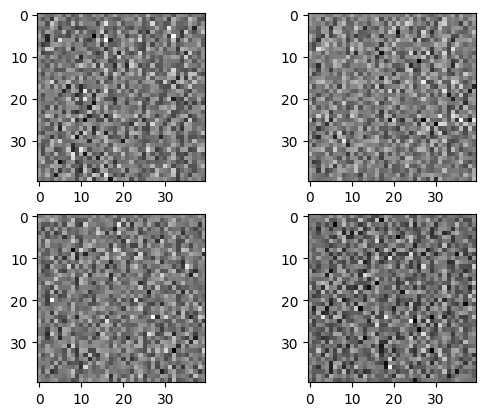

saved on epoch 0
saved on epoch 0
45/45 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - d_loss: 4.1658 - g_loss: 0.4648
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
mean -0.012542043812572956 std 0.011289775371551514
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
prediction [[0.8914923 ]
 [0.88899344]
 [0.8927913 ]
 [0.8918607 ]]
45/45 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - d_loss: 0.8475 - g_loss: 1.1527
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
mean -0.019074128940701485 std 0.013108020648360252
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
prediction [[0.88931847]
 [0.8869772 ]
 [0.8917377 ]
 [0.8892639 ]]
45/45 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - d_loss: -3.1815 - g_loss: 2.7513
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
mean -0.026039279997348785 std 0.014708086848258972
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
prediction [[0.88936895]
 [0.8863572 ]
 [0.8859214 ]
 [0.88670665]]
45/45 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - d_loss: -6.7601 - g_loss: 4.8262
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/ste

prediction [[0.8775651]
 [0.8755952]
 [0.8819174]
 [0.87728  ]]
saved on epoch 5


saved on epoch 5
45/45 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - d_loss: -10.6104 - g_loss: 4.7734
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
mean -0.052770089358091354 std 0.020521244034171104
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.869335  ]
 [0.87389886]
 [0.87094736]
 [0.8722148 ]]
45/45 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - d_loss: -11.1947 - g_loss: 3.2193
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
mean -0.06371157616376877 std 0.0225429218262434
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
prediction [[0.8640977 ]
 [0.86148727]
 [0.86548775]
 [0.8676572 ]]
45/45 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - d_loss: -11.3588 - g_loss: 1.7067
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
mean -0.07818109542131424 std 0.025896843522787094
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
prediction [[0.85347396]
 [0.85323393]
 [0.85807   ]
 [0.85581106]]
45/45 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - d_loss: -10.8458 - g_loss: 0.6577
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
mean -0.0952

prediction [[0.8278692 ]
 [0.8302259 ]
 [0.8290427 ]
 [0.82756776]]
saved on epoch 10
saved on epoch 10
45/45 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - d_loss: -9.6570 - g_loss: -1.1946
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
mean -0.13057000935077667 std 0.03617630898952484
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.80887216]
 [0.8114604 ]
 [0.8137605 ]
 [0.81207305]]
45/45 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - d_loss: -8.6745 - g_loss: -2.2701
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
mean -0.15641145408153534 std 0.04256124421954155
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
prediction [[0.79427844]
 [0.7942725 ]
 [0.7934715 ]
 [0.78989804]]
45/45 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - d_loss: -7.3962 - g_loss: -3.3772
Epoch 14/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
mean -0.18174037337303162 std 0.04875486344099045
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
prediction [[0.76229584]
 [0.7877551 ]
 [0.76712054]
 [0.7809577 ]]
45/45 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - d_loss: -

KeyboardInterrupt: 

In [ ]:
import glob
import re

def load_latest_model():
    # Use the path to your Google Drive folder
    generator_files = glob.glob("/content/drive/MyDrive/Ahsan/8. 2025 cGAN Hamid with Dr. Darren Dataset/Generator Model/generator_Epoch-*.h5")
    discriminator_files = glob.glob("/content/drive/MyDrive/Ahsan/8. 2025 cGAN Hamid with Dr. Darren Dataset/Discriminator Model/discriminator_Epoch-*.h5")

    if not generator_files or not discriminator_files:
        print("No files here ")
        return None, None

    # searches files to get epoch numbers
    epochs = [int(re.search(r"Epoch-(\d+)", f).group(1)) for f in generator_files]
    # this return largest epoch
    latest_epoch = max(epochs)

    # loading that generator and dsicriminator file with
    generator_filename = f'/content/drive/MyDrive/Ahsan/8. 2025 cGAN Hamid with Dr. Darren Dataset/Generator Model/generator_Epoch-{latest_epoch}.h5'
    discriminator_filename = f'/content/drive/MyDrive/Ahsan/8. 2025 cGAN Hamid with Dr. Darren Dataset/Discriminator Model/discriminator_Epoch-{latest_epoch}.h5'

    print(f"Loading models from epoch {latest_epoch}")
    generator = tf.keras.models.load_model(generator_filename)
    discriminator = tf.keras.models.load_model(discriminator_filename)
    return generator, discriminator, latest_epoch

generator, discriminator, latest_epoch= load_latest_model()


cond_gan = ConditionalGAN(
    discriminator=discriminator,
    generator=generator,
    latent_dim=latent_dim,
    batch_size=batch_size
)

# Compile the ConditionalGAN with the same loss and optimizer functions
cond_gan.compile(
    d_optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5, beta_1=0.5, beta_2=0.9),
    g_optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5, beta_1=0.5, beta_2=0.9),
    g_loss_fn=generator_loss,
    d_loss_fn=discriminator_loss,
)

# Continue training for an additional epochs
hist = cond_gan.fit(dataset, initial_epoch=latest_epoch, epochs=100, callbacks=[callback])

In [ ]:
cond_gan.generator.save('/content/drive/MyDrive/Ahsan/8. 2025 cGAN Hamid with Dr. Darren Dataset/generator.h5')

In [ ]:
# Plot the losses
cond_gan.plot_losses()

NameError: name 'cond_gan' is not defined